In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud spacy scikit-learn langdetect fasttext-wheel nltk pyspellchecker

In [2]:
!pip install shap

In [3]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.1 MB/s eta 0:00:00m eta 0:00:010:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
import os
import shap
import torch
import json

from wordcloud import WordCloud, STOPWORDS
from langdetect import detect, LangDetectException

from spellchecker import SpellChecker
from collections import Counter
import openai
from openai import OpenAI
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments,AutoModelForCausalLM, AutoTokenizer, set_seed


%load_ext autoreload
%autoreload 2
# Load Spacy English model for Lemmatization
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

from IPython.display import display, HTML
# Set the display width to control the output width
pd.set_option('display.width', 100)
# Read the dataset and read the Laptop Dataset
df = pd.read_csv('Dataset-SA.csv')
df

2026-03-06 23:07:18.999460: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
...,...,...,...,...,...,...
205047,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,must buy!,good product,positive
205048,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,super!,nice,positive
205049,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,3,nice,very nice and fast delivery,positive
205050,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,just wow!,awesome product,positive


In [5]:
df.iloc[117075]

product_name     Noise ColorFit Icon 2 1.8 Display, Bluetooth C...
product_price                                                 2199
Rate                                                             3
Review                                                        good
Summary          some update required is not work properly for ...
Sentiment                                                  neutral
Name: 117075, dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [7]:
df.describe()

,product_name,product_price,Rate,Review,Summary,Sentiment
count,205052,205052,205052,180388,205041,205052
unique,958,525,8,1324,92923,3
top,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,wonderful,good,positive
freq,6005,9150,118765,9016,17430,166581


In [8]:
df['Sentiment'].value_counts()

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

In [9]:
# Data Cleaning
#Handling invalid values - Rate
df['Rate'].unique()

array(['5', '3', '1', '4', '2',
       'Pigeon Favourite Electric Kettle??????(1.5 L, Silver, Black)',
       'Bajaj DX 2 L/W Dry Iron',
       'Nova Plus Amaze NI 10 1100 W Dry Iron?Ã\x83Â¿?Ã\x83Â¿(Grey & Turquoise)'],
      dtype=object)

In [10]:
# ==========================================
# Data Type Inspection & Cleaning for 'Rate'
# ==========================================
print("--- Inspecting 'Rate' Column ---")

# Check unique values to see what the strings look like
print("Unique values in 'Rate' before cleaning:")
print(df['Rate'].unique())

# Convert to Numeric
# 'errors='coerce'' turns any value that isn't a number (like "Five" or "bad") into NaN (Null)
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

# Check for Nulls created by the conversion
invalid_rates = df['Rate'].isnull().sum()
print(f"\nFound {invalid_rates} invalid (non-numeric) entries in 'Rate'.")
# Remove rows with invalid Rates 
# If the Rate is invalid, I can't use it for the Consistency Analysis boxplot.
if invalid_rates > 0:
    df.dropna(subset=['Rate'], inplace=True)
    print(f"Dropped {invalid_rates} rows with invalid ratings.")

# Ensure it is an Integer (1-5)
df['Rate'] = df['Rate'].astype(int)

print("\nUnique values in 'Rate' after cleaning:")
print(df['Rate'].unique())
print("Data type of 'Rate':", df['Rate'].dtype)

--- Inspecting 'Rate' Column ---
Unique values in 'Rate' before cleaning:
['5' '3' '1' '4' '2'
 'Pigeon Favourite Electric Kettle??????(1.5 L, Silver, Black)'
 'Bajaj DX 2 L/W Dry Iron'
 'Nova Plus Amaze NI 10 1100 W Dry Iron?Ã\x83Â¿?Ã\x83Â¿(Grey & Turquoise)']

Found 3 invalid (non-numeric) entries in 'Rate'.
Dropped 3 rows with invalid ratings.

Unique values in 'Rate' after cleaning:
[5 3 1 4 2]
Data type of 'Rate': int64


In [11]:
# ==========================================
# 7.1.2. Data Cleaning
# ==========================================
# Calculating the missing values in the dataset
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

In [12]:
df[df['Review']=='not specified'].value_counts

<bound method DataFrame.value_counts of                                              product_name product_price  Rate         Review  \
139863   Baby Girls PartyFestive Dress SlingbagMulticolor           269     5  not specified   
139864   Baby Girls PartyFestive Dress SlingbagMulticolor           269     5  not specified   
139865   Baby Girls PartyFestive Dress SlingbagMulticolor           269     4  not specified   
139866   Baby Girls PartyFestive Dress SlingbagMulticolor           269     5  not specified   
139867   Baby Girls PartyFestive Dress SlingbagMulticolor           269     5  not specified   
...                                                   ...           ...   ...            ...   
192238  LS2734 Wolf Gents Exclusive Mesh Strap Analog ...           209     5  not specified   
192239  LS2734 Wolf Gents Exclusive Mesh Strap Analog ...           209     1  not specified   
192240  LS2734 Wolf Gents Exclusive Mesh Strap Analog ...           209     1  not specified   


In [13]:

# Calculating the missing values in the dataset
df['Review']=df['Review'].replace('not specified',np.nan)
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           33015
Summary             11
Sentiment            0
dtype: int64

In [14]:
# ==========================================
# 7.1.2. Data Cleaning
# ==========================================
print("--- Starting Section 7.1.2: Data Cleaning ---")

# 1. Handle Null Values
# Deleting rows where 'Review' or 'Summary' is null
initial_shape = df.shape
df.dropna(subset=['Review', 'Summary'], inplace=True)
print(f"Dropped {initial_shape[0] - df.shape[0]} rows containing null values.")

--- Starting Section 7.1.2: Data Cleaning ---
Dropped 33024 rows containing null values.


In [15]:
df.shape[0]

172025

/tmp/ipykernel_340733/1669735223.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Rate', data=df, palette='coolwarm', order=['positive', 'neutral', 'negative'])


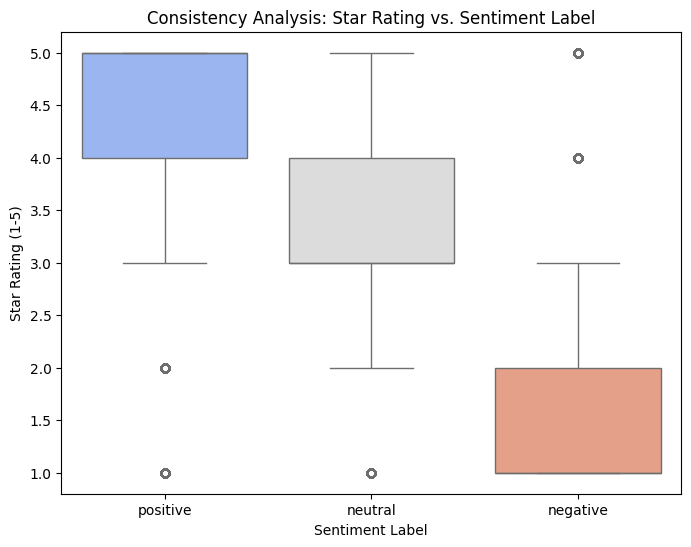

In [16]:
# ==========================================
#  EDA: Rate & Sentiment Analysis 
# ==========================================

# 2. Consistency Analysis (Rate vs Sentiment)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sentiment', y='Rate', data=df, palette='coolwarm', order=['positive', 'neutral', 'negative'])
plt.title('Consistency Analysis: Star Rating vs. Sentiment Label')
plt.xlabel('Sentiment Label')
plt.ylabel('Star Rating (1-5)')
plt.show()
# Note: At this stage, you would manually inspect discrepancies (e.g., Sentiment='Negative' but Rate=5)

In [17]:
# ==========================================
#  EDA: Consistency Check 
# ==========================================

# Define the condition
positive_inconsistent_mask = (df['Rate'] <= 3) & (df['Sentiment'] == 'positive')
negative_inconsistent_mask = (df['Rate'] >= 3) & (df['Sentiment'] == 'negative')
neutral_inconsistent_mask = ((df['Rate'] < 2) | (df['Rate'] > 4)) & (df['Sentiment'] == 'neutral')
inconsistent_mask = (positive_inconsistent_mask | negative_inconsistent_mask | neutral_inconsistent_mask)
#print(negative_inconsistent_mask)
# Create a subset dataframe for these cases
inconsistent_cases = df[inconsistent_mask]

# Print the number of such cases
print(f"Found {len(inconsistent_cases)} records with rating-sentiment inconsistency.")

# Display the cases to inspect the text
# I show Rate, Sentiment, and the Review text to understand the context
if not inconsistent_cases.empty:
    print("\n--- Sample Inconsistent Records ---")
    pd.set_option('display.max_colwidth', 150) # Expand column width to read the review
    print(inconsistent_cases[['Rate', 'Sentiment', 'Review','Summary']].head(10))

else:
    print("No inconsistent cases found.")

Found 16416 records with rating-sentiment inconsistency.

--- Sample Inconsistent Records ---
    Rate Sentiment                     Review  \
2      3  positive                       fair   
7      3  positive                       nice   
43     3  positive             decent product   
45     3  positive          very satisfactory   
53     3  negative                       nice   
59     1  positive                  worthless   
64     3  positive             decent product   
73     1  positive            useless product   
86     2  positive  expected a better product   
88     3  positive                       nice   

                                                                                                                                                  Summary  
2                                                                                                      the quality is good but the power of air is decent  
7                                                     

In [18]:
#Delete inconsistency rows
df.drop(df[inconsistent_mask].index, inplace=True)
df.reset_index(drop=True, inplace=True)

# Replace inconsistency 
#df.drop(index=df[inconsistent_mask].index, inplace=True)
df.loc[df['Rate'] == 3, 'Sentiment'] = 'neutral'
df.loc[df['Rate'] >= 4, 'Sentiment'] = 'positive'
df.loc[df['Rate'] <= 2, 'Sentiment'] = 'negative'

df[(df['Rate']>=3)& (df['Sentiment'] == 'negative')]


--- Starting Section 7.1.3: EDA ---


/tmp/ipykernel_340733/750065809.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentiment', data=df, palette='viridis', order=['positive', 'neutral', 'negative'])


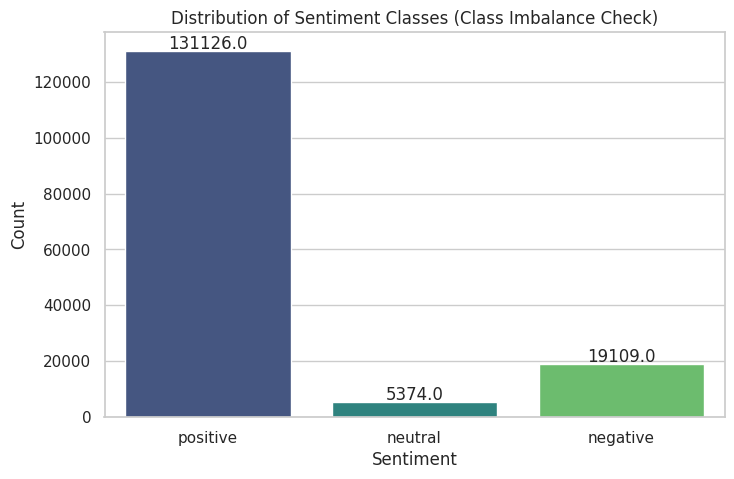

In [19]:
# ==========================================
# EDA : Count Sentiment
# ==========================================
print("\n--- Starting Section 7.1.3: EDA ---")

# Set visual style
sns.set(style="whitegrid")

# Analysis of Class Imbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Sentiment', data=df, palette='viridis', order=['positive', 'neutral', 'negative'])
plt.title('Distribution of Sentiment Classes (Class Imbalance Check)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
# Add counts on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

/tmp/ipykernel_340733/2825444407.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Rate', data=df, palette='coolwarm', order=['positive', 'neutral', 'negative'])


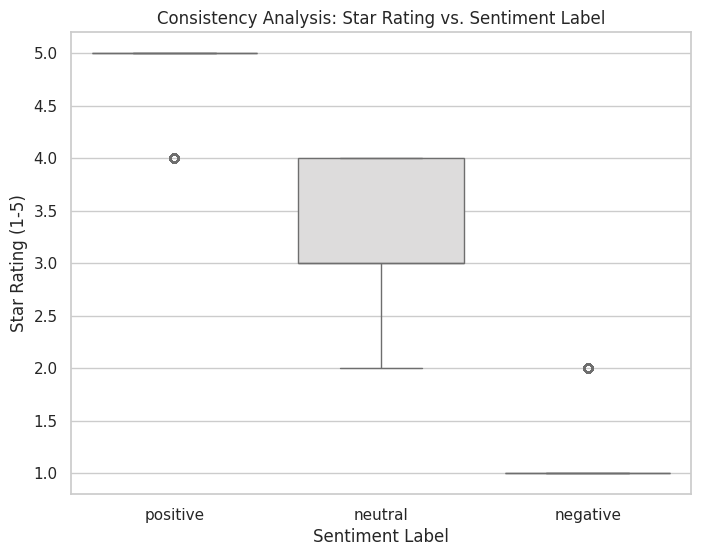

In [20]:
# Re-plot Sentiment - Rate
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sentiment', y='Rate', data=df, palette='coolwarm', order=['positive', 'neutral', 'negative'])
plt.title('Consistency Analysis: Star Rating vs. Sentiment Label')
plt.xlabel('Sentiment Label')
plt.ylabel('Star Rating (1-5)')
plt.show()
# Note: At this stage, you would manually inspect discrepancies (e.g., Sentiment='Negative' but Rate=5)

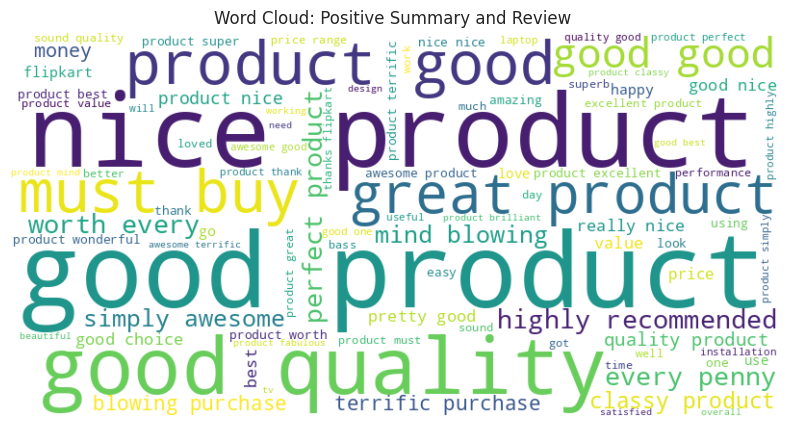

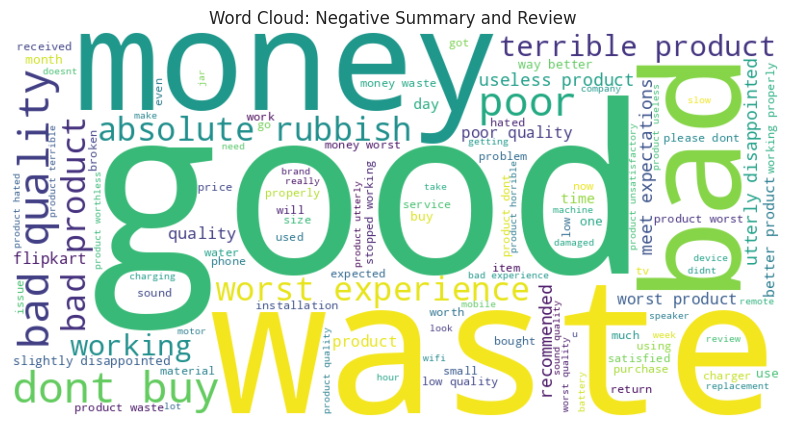

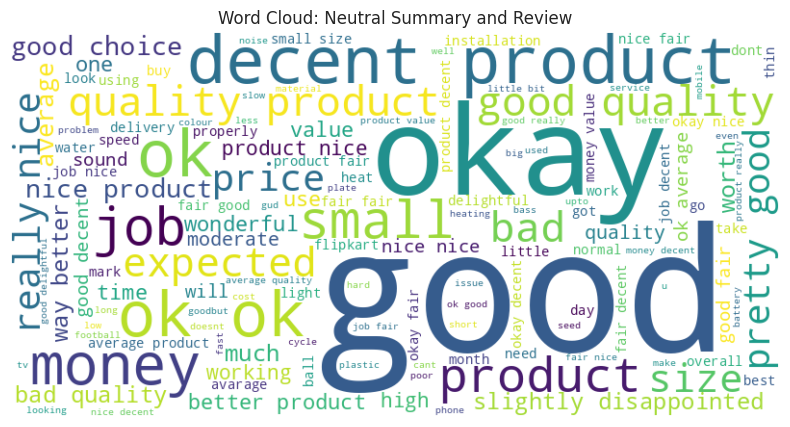

,count
count,41660.000000
mean,37.760802
std,786.076837
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,78532.000000


In [21]:
# 3. Word Cloud Analysis
def plot_wordcloud(text_data, title):
    wordcloud = WordCloud(width=800, height=400, background_color ='white', min_font_size=10).generate(text_data)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Combine text for visualization
positive_text1 = " ".join(review for review in df[df['Sentiment'] == 'positive']['Review'].astype(str))
negative_text1 = " ".join(review for review in df[df['Sentiment'] == 'negative']['Review'].astype(str))
neutral_text1 = " ".join(review for review in df[df['Sentiment'] == 'neutral']['Review'].astype(str))

#plot_wordcloud(positive_text, "Word Cloud: Positive Reviews")
#plot_wordcloud(negative_text, "Word Cloud: Negative Reviews")

# Combine text for visualization
positive_text2 = " ".join(summary for summary in df[df['Sentiment'] == 'positive']['Summary'].astype(str))
negative_text2 = " ".join(summary for summary in df[df['Sentiment'] == 'negative']['Summary'].astype(str))
neutral_text2 = " ".join(summary for summary in df[df['Sentiment'] == 'neutral']['Summary'].astype(str))
#positive_text2 = " "
#neutral_text2 = " "
#neutral_text2 = " "
positive_text = positive_text1 + positive_text2
negative_text = negative_text1 + negative_text2
neutral_text = neutral_text1 + neutral_text2

plot_wordcloud(positive_text, "Word Cloud: Positive Summary and Review ")
plot_wordcloud(negative_text, "Word Cloud: Negative Summary and Review ")
plot_wordcloud(neutral_text, "Word Cloud: Neutral Summary and Review")

negative_textx = negative_text.split()
positive_textx = positive_text.split()
neutral_textx = neutral_text.split()

all_text_count = Counter(negative_textx + positive_textx + neutral_textx)


unknown_pos_df= pd.DataFrame(all_text_count.items(), columns=['word', 'count'])
unknown_pos_df.describe()

In [22]:
df[df['Sentiment'] == 'negative'].head(20)

,product_name,product_price,Rate,Review,Summary,Sentiment
2,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,1,useless product,very bad product its a only a fan,negative
6,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,1,unsatisfactory,very bad cooler,negative
30,"Candes 60 L Room/Personal Air Cooler??????(White, Black, CRETA)",8999,2,expected a better product,bad quality,negative
44,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,1,waste of money!,small wire and moter capacity is very low fan speed was not good out flow vent hole is above the lower part of cooler its very difficult to change...,negative
60,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,1,worst experience ever!,cooler not provide cool air because 1year experience,negative
67,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,1,"like an assembled, one can get for 4.5k cheap quality",no quality product1 the wood wool has started falling out from the next day2 out of two led indicator has found not working on arrival3 the air sw...,negative
72,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,2,not good,poar quality plastic material is not good,negative
76,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,2,slightly disappointed,dont buy just by seing the comments dont know how people review and rate the product cooling is ok but when it comes to fill the water you would n...,negative
78,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,1,horrible,cooling fan problem,negative
89,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,1,very poor,dont buy this product within 15 year wind blade was broken and noise issue wind blow very low its better to go other brand,negative


In [23]:
df[df['Review'].isnull() | df['Summary'].isnull()]

,product_name,product_price,Rate,Review,Summary,Sentiment


In [24]:
df=df.dropna()

In [25]:
df[df['Review'].isnull() | df['Summary'].isnull()]

,product_name,product_price,Rate,Review,Summary,Sentiment


In [26]:
# Calculating the missing values in the dataset
df.isnull().sum()

product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64

In [27]:
print(df['Sentiment'].value_counts().sort_values().iloc[0])

5374


In [28]:
# ==========================================
# Data Preprocessing
# ==========================================

print("\n--- Starting Section Data Preprocessing ---")

# 1. Feature Creation: Concatenation
# As per prompt: "Review" as headline (start) and "Summary" as full text (end)
#df['Feedback_For_LLM'] = df['Review'].astype(str) + ". " + df['Summary'].astype(str)
df['Feedback_Original'] = df['Review'].astype(str) + " " + df['Summary'].astype(str)

# Normalization Function
# Dictionary mapping for colloquialisms (Hinglish/Slang examples)
# You should expand this dictionary based on your specific dataset's EDA

def normalize_text(text):
    # a. Lowercase
    text = text.lower()
    
    # b. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # c. Remove Hashtags
    text = re.sub(r'#\w+', '', text)
    
    # d. Remove Non-ASCII characters (Handling Hinglish/Special chars)
    text = re.sub(r'[^\x00-\x7f]', r'', text)
    
    # e. Dictionary Mapping (Colloquialisms)
   # words = text.split()

   #words = [generated_map.get(word, word) for word in words]
   #text = " ".join(words)
    
    # f. Remove special characters/punctuation but keep spaces
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

print("Applying Normalization to Feedback_Text...")
#unknown_wordlist=extract_unknown_words_robust(df['Feedback_For_ML_TF'])

df['Feedback_Clean'] = df['Feedback_Original'].apply(normalize_text)

# Lemmatization
# Reduces words to base form (beauty -> beautiful) using Spacy
# Note: I do NOT remove stopwords here as per Section 7.1.4 guidance regarding negations.
def lemmatize_text(text):
    doc = nlp(text)
    # Extract lemma
    return " ".join([token.lemma_ for token in doc])

print("Applying Lemmatization to Feedback_Text...")
df['Feedback_Clean'] = df['Feedback_Clean'].apply(lemmatize_text)

# Encode Target Variable
encoder = LabelEncoder()
df['Encoded_Sentiment'] = encoder.fit_transform(df['Sentiment'])

print("\n--- Preprocessing Complete ---")
print("Mapping of Encoded Sentiment:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("\nFinal Feature check:")
df[['Feedback_Original', 'Feedback_Clean','Encoded_Sentiment']].head(10)


--- Starting Section Data Preprocessing ---
Applying Normalization to Feedback_Text...
Applying Lemmatization to Feedback_Text...

--- Preprocessing Complete ---
Mapping of Encoded Sentiment: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Final Feature check:


,Feedback_Original,Feedback_Clean,Encoded_Sentiment
0,super! great cooler excellent air flow and for this price its so amazing and unbelievablejust love it,super great cool excellent air flow and for this price its so amazing and unbelievablejust love it,2
1,awesome best budget 2 fit cooler nice cooling,awesome good budget 2 fit cool nice cooling,2
2,useless product very bad product its a only a fan,useless product very bad product its a only a fan,0
3,fair ok ok product,fair ok ok product,1
4,awesome the cooler is really fantastic and provides good air flow highly recommended,awesome the cooler be really fantastic and provide good air flow highly recommend,2
5,highly recommended very good product,highly recommend very good product,2
6,unsatisfactory very bad cooler,unsatisfactory very bad cool,0
7,worth the money very good,worth the money very good,2
8,great product beautiful product good material and perfectly working,great product beautiful product good material and perfectly work,2
9,mind-blowing purchase awesome,mindblowing purchase awesome,2


In [29]:
df[['Feedback_Original', 'Feedback_Clean','Encoded_Sentiment']].head(50)

,Feedback_Original,Feedback_Clean,Encoded_Sentiment
0,super! great cooler excellent air flow and for this price its so amazing and unbelievablejust love it,super great cool excellent air flow and for this price its so amazing and unbelievablejust love it,2
1,awesome best budget 2 fit cooler nice cooling,awesome good budget 2 fit cool nice cooling,2
2,useless product very bad product its a only a fan,useless product very bad product its a only a fan,0
3,fair ok ok product,fair ok ok product,1
4,awesome the cooler is really fantastic and provides good air flow highly recommended,awesome the cooler be really fantastic and provide good air flow highly recommend,2
5,highly recommended very good product,highly recommend very good product,2
6,unsatisfactory very bad cooler,unsatisfactory very bad cool,0
7,worth the money very good,worth the money very good,2
8,great product beautiful product good material and perfectly working,great product beautiful product good material and perfectly work,2
9,mind-blowing purchase awesome,mindblowing purchase awesome,2


In [30]:
df[['Feedback_Clean', 'Encoded_Sentiment']].head(10)

,Feedback_Clean,Encoded_Sentiment
0,super great cool excellent air flow and for this price its so amazing and unbelievablejust love it,2
1,awesome good budget 2 fit cool nice cooling,2
2,useless product very bad product its a only a fan,0
3,fair ok ok product,1
4,awesome the cooler be really fantastic and provide good air flow highly recommend,2
5,highly recommend very good product,2
6,unsatisfactory very bad cool,0
7,worth the money very good,2
8,great product beautiful product good material and perfectly work,2
9,mindblowing purchase awesome,2


In [31]:
target_n = df['Encoded_Sentiment'].value_counts().sort_values().iloc[0]

df_balanced = (
    df.groupby('Encoded_Sentiment', group_keys=False)
      .apply(lambda x: x.sample(n=target_n, random_state=42))
      .reset_index(drop=True)
)

/tmp/ipykernel_340733/790498230.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=target_n, random_state=42))


In [32]:
df_balanced['Sentiment'].value_counts()

Sentiment
negative    5374
neutral     5374
positive    5374
Name: count, dtype: int64

In [33]:
# Change df to Balanced data
df=df_balanced.copy()

In [34]:
# Create a folder for your checkpoints to keep things organized
import os
import joblib
import pandas as pd
checkpoint_dir = 'Checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

print(f"Checkpoints will be saved to: {checkpoint_dir}")

# Define the file path
data_file_path = os.path.join(checkpoint_dir, 'processed_data120126.pkl')


Checkpoints will be saved to: Checkpoints


In [35]:
X = df['Feedback_Clean']
y = df['Encoded_Sentiment']
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y,  test_size=0.20,  random_state=42, stratify=y) 
print(f"Train set shape: {X_train_text.shape}")
print(f"Test set shape: {X_test_text.shape}")

Train set shape: (12897,)
Test set shape: (3225,)


In [6]:
# Check balance after split
print(f"Train set sentiment count: {y_train.value_counts()}")
print(f"Test set sentiment count: {y_test.value_counts()}")

Train set sentiment count: Encoded_Sentiment
1    4299
2    4299
0    4299
Name: count, dtype: int64
Test set sentiment count: Encoded_Sentiment
2    1075
1    1075
0    1075
Name: count, dtype: int64


In [36]:
# 
# Feature Engineering: TF-IDF
# 
# Note: I fit the vectorizer ONLY on the train set to prevent data leakage
tfidf_vectorizer = TfidfVectorizer(
   # max_features=5000, # Adjustable based on vocabulary size
    ngram_range=(1, 2) # Capture Unigrams and Bigrams
)
#X_trainML_text = X_train_text['Feedback_Clean']
#X_testML_text = X_test_text['Feedback_Clean']
#y_trainML = y_train['Encoded_Sentiment']
#y_testML = y_test['Encoded_Sentiment']
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

In [37]:
print(X_train_tfidf.shape, X_test_tfidf.shape)

(12897, 55250) (3225, 55250)


In [38]:
# --- SAVE ---

joblib.dump(df_balanced, data_file_path)
print("Data saved!")

Data saved!


In [39]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_sessionBalancedData190126.db'))

In [21]:
#
# SVM Model Development
#
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the base model
basesvm_model = LinearSVC(class_weight='balanced', random_state=42, dual=False)

# Wrap it to allow probability estimation (crucial for XAI)
#calibrated_svc = CalibratedClassifierCV(base_model)

# Define a real grid search
param_grid = {
    'C': [0.1, 1, 10,100], # Note the 'estimator__' prefix for calibrated models
    }

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=basesvm_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1
)
print("Starting Grid Search Optimization...")
grid_search.fit(X_train_tfidf, y_train)
best_model_svm = grid_search.best_estimator_
print(f"Best Model: {best_model_svm}")
print(f"Best Parameters: {grid_search.best_params_}")

print(f"Best Score: {grid_search.best_score_}")


Starting Grid Search Optimization...
Best Model: LinearSVC(C=1, class_weight='balanced', dual=False, random_state=42)
Best Parameters: {'C': 1}
Best Score: 0.9349340440261893


Generating Learning Curve Score for the Best Model...
[learning_curve] Training set sizes: [ 1031  3353  5674  7995 10317]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  13 out of  25 | elapsed:    1.0s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    1.6s finished


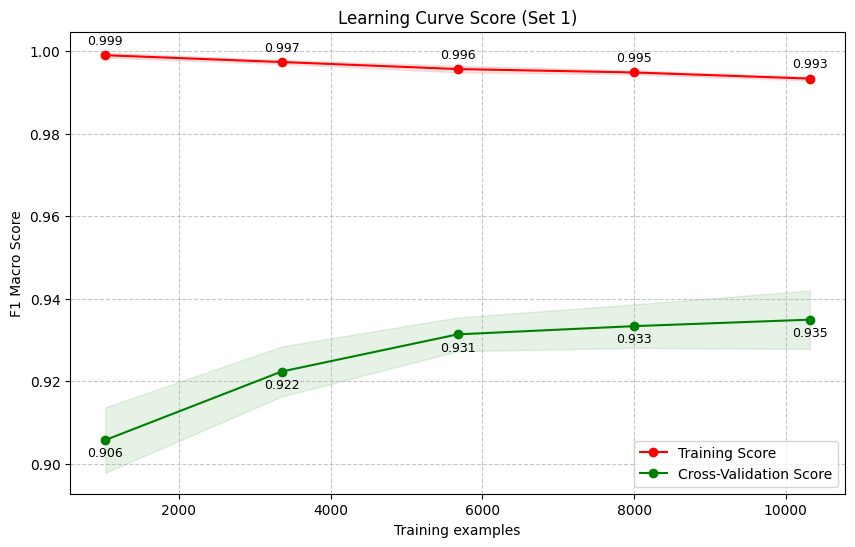

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def plot_learning_curve(estimator, title, X, y, cv, n_jobs=-1):
    """
    Plots the learning curve (Training vs Validation Score) for the given model.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 Macro Score")

    # 1. Compute the learning curve
    # We use 'f1_weighted' because that was the metric in your original image
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, 
        X, 
        y, 
        cv=cv, 
        n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), # 5 points from 10% to 100% data
        scoring='f1_macro',
        verbose=2
    )

    # 2. Calculate means and standard deviations (for the shaded area)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # 3. Plot the grid and the shaded standard deviation
    plt.grid(True, linestyle='--', alpha=0.7) # Dashed lines, slightly transparent
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")

    # 4. Plot the actual lines
    # Inside any plotting function:
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-Validation Score")
    
    # 🔢 Show values on each marker
    for x, y in zip(train_sizes, train_scores_mean):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, 8),
                     ha='center',
                     fontsize=9)
    
    for x, y in zip(train_sizes, test_scores_mean):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, -12),
                     ha='center',
                     fontsize=9)
    plt.legend(loc="best")
    plt.show()

# --- EXECUTION ---
# Assuming 'X_train' and 'y_train' are your variables
# 'best_svm_model' is the model you found from the previous step

print("Generating Learning Curve Score for the Best Model...")
plot_learning_curve(best_model_svm, "Learning Curve Score (Set 1)", X_train_tfidf, y_train, cv=cv_strategy)

Generating Learning Curve for the Best Model...


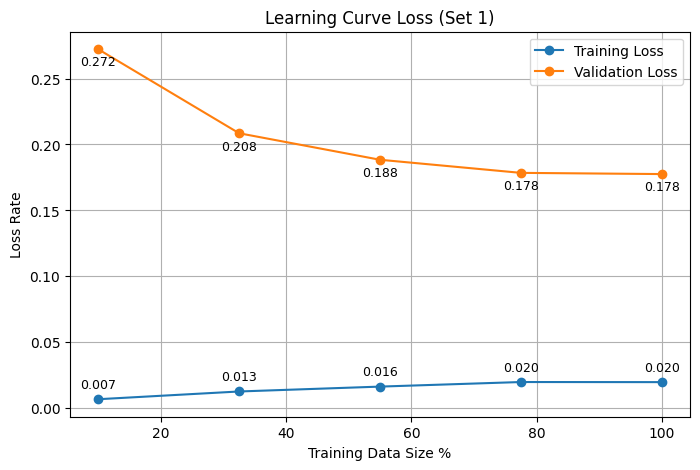

[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.3s
[CV] END ...................

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.base import clone
from sklearn.metrics import hinge_loss

def plot_svm_loss_curve(estimator, title, X, y, cv):

    # 🔑 ABSOLUTE FIX
    y = np.asarray(y)              # converts Series → ndarray
    n_samples = X.shape[0]         # works for sparse matrices

    train_sizes = np.linspace(0.1, 1.0, 5)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    train_losses = []
    val_losses = []
    train_error = []
    val_error = []
    for frac in train_sizes:
        fold_train_losses = []
        fold_val_losses = []
        fold_train_error = []
        fold_val_error = []
        n_train = int(n_samples * frac)

        for train_idx, val_idx in skf.split(X, y):

            train_idx_small = train_idx[:n_train]

            X_train_fold = X[train_idx_small]
            y_train_fold = y[train_idx_small]

            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]

            model = clone(estimator)
            model.fit(X_train_fold, y_train_fold)

            y_train_pred = model.predict(X_train_fold)
            y_val_pred = model.predict(X_val_fold)

            train_acc = accuracy_score(y_train_fold, y_train_pred)
            val_acc = accuracy_score(y_val_fold, y_val_pred)

            fold_train_error.append(1 - train_acc)
            fold_val_error.append(1 - val_acc)
            
        # Get raw distance scores instead of labels
            y_train_decision = model.decision_function(X_train_fold)
            y_val_decision = model.decision_function(X_val_fold)
        
        # Calculate true Hinge Loss
            train_hinge = hinge_loss(y_train_fold, y_train_decision)
            val_hinge = hinge_loss(y_val_fold, y_val_decision)
        
            fold_train_losses.append(train_hinge)
            fold_val_losses.append(val_hinge)
        
        train_losses.append(np.mean(fold_train_losses))
        val_losses.append(np.mean(fold_val_losses))
        train_error.append(np.mean(fold_train_error))
        val_error.append(np.mean(fold_val_error))    
    # 📊 Plot
    plt.figure(figsize=(8, 5))
    train_var = train_sizes*100
    plt.plot(train_var, train_losses, marker='o', label="Training Loss")
    plt.plot(train_var, val_losses, marker='o', label="Validation Loss")
    #plt.plot(train_var, train_error, marker='o', label="Training Error")
    #plt.plot(train_var, val_error, marker='o', label="Validation Error")
    # 🔢 Show values on each marker
    for x, y in zip(train_var, train_losses):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, 8),
                     ha='center',
                     fontsize=9)
    
    for x, y in zip(train_var, val_losses):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, -12),
                     ha='center',
                     fontsize=9)
        
  #  for x, y in zip(train_var, train_error):
  #      plt.annotate(f"{y:.3f}", (x, y),
  #                   textcoords="offset points",
  #                   xytext=(0, 8),
  #                   ha='center',
  #                   fontsize=9)
    
  #  for x, y in zip(train_var, val_error):
  #      plt.annotate(f"{y:.3f}", (x, y),
  #                   textcoords="offset points",
  #                   xytext=(0, -12),
  #                   ha='center',
  #                   fontsize=9)
    plt.xlabel("Training Data Size %")
    plt.ylabel("Loss Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


print("Generating Learning Curve for the Best Model...")
plot_svm_loss_curve(best_model_svm, "Learning Curve Loss (Set 1)", X_train_tfidf, y_train, cv=5)

In [43]:
# SET 2

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the model
svm = SVC(class_weight='balanced', random_state=42,probability=True)


# Define the grid. 
# Note: We are testing smaller C values (0.1, 1) to increase regularization.
# We are testing smaller gamma values (0.01, 0.001) to smooth the boundary.
param_grid = { 
    'C': [0.1, 1, 10, 100],            # Lower C = More Regularization
    'kernel': ['rbf', 'poly']   # 
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up the Grid Search with Cross Validation (e.g., 5-fold)
grid = GridSearchCV(estimator=svm, param_grid=param_grid, cv=cv_strategy, verbose=2, scoring='f1_macro', n_jobs=-1)

# Fit to your training data
grid.fit(X_train_tfidf, y_train)

# View the best parameters
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")
best_svm2 = grid.best_estimator_
print(best_svm2)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 100, 'kernel': 'rbf'}
Best Score: 0.9363006517774843
SVC(C=100, class_weight='balanced', probability=True, random_state=42)


Generating Learning Curve Score for the Best Model...
[learning_curve] Training set sizes: [ 1031  3353  5674  7995 10317]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:  2.2min finished


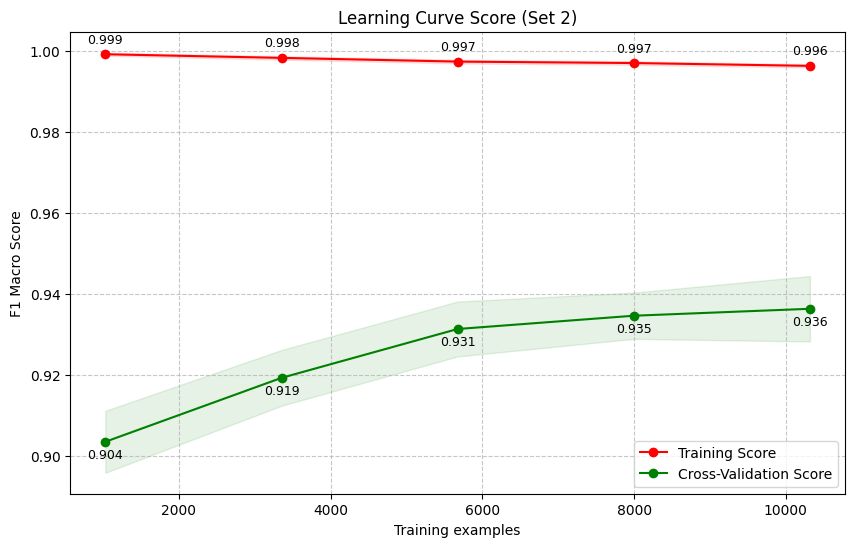

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def plot_learning_curve(estimator, title, X, y, cv, n_jobs=-1):
    """
    Plots the learning curve (Training vs Validation Score) for the given model.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 Macro Score")

    # 1. Compute the learning curve
    # We use 'f1_weighted' because that was the metric in your original image
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, 
        X, 
        y, 
        cv=cv, 
        n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), # 5 points from 10% to 100% data
        scoring='f1_macro',
        verbose=1
    )

    # 2. Calculate means and standard deviations (for the shaded area)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # 3. Plot the grid and the shaded standard deviation
    plt.grid(True, linestyle='--', alpha=0.7) # Dashed lines, slightly transparent
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")

    # 4. Plot the actual lines
    # Inside any plotting function:
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-Validation Score")
     # 🔢 Show values on each marker
    for x, y in zip(train_sizes, train_scores_mean):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, 8),
                     ha='center',
                     fontsize=9)
    
    for x, y in zip(train_sizes, test_scores_mean):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, -12),
                     ha='center',
                     fontsize=9)
    plt.legend(loc="best")
    plt.show()



print("Generating Learning Curve Score for the Best Model...")
plot_learning_curve(best_svm2, "Learning Curve Score (Set 2)", X_train_tfidf, y_train, cv=cv_strategy)

Generating Learning Curve Loss for the Best Model...
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.3s
[CV] END ..................................C=0.1, kernel=rbf; total time= 1.8min
[CV] END ....................................C=1, kernel=rbf; total time= 1.2min
[CV] END ...................................C=1, kernel=poly; total time= 1.9min
[CV] END ..................................C=10, kernel=poly; total time= 1.9min
[CV] END .................................C=100, kernel=poly; total time= 1.6min
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END ..................................C=0.1, kernel

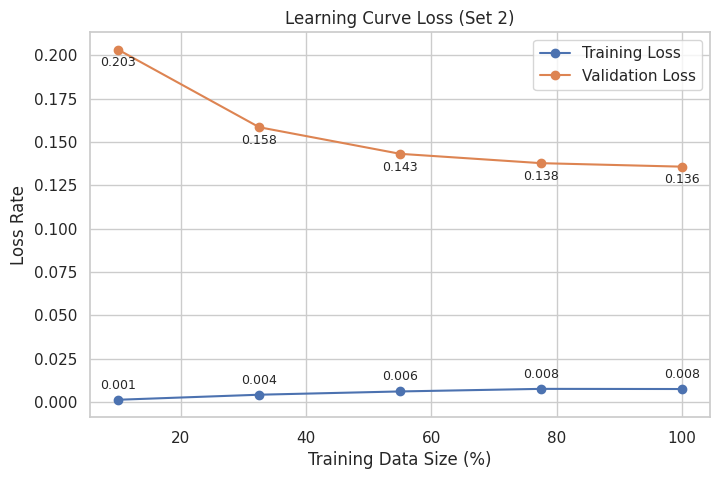

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.base import clone

def plot_svm_loss_curve(estimator, title, X, y, cv=5):

    y = np.asarray(y)              # converts Series → ndarray
    n_samples = X.shape[0]         # works for sparse matrices

    train_sizes = np.linspace(0.1, 1.0, 5)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    train_losses = []
    val_losses = []
    train_error = []
    val_error =[]

    for frac in train_sizes:
        fold_train_losses = []
        fold_val_losses = []
        fold_train_error = []
        fold_val_error = []
        n_train = int(n_samples * frac)

        for train_idx, val_idx in skf.split(X, y):

            train_idx_small = train_idx[:n_train]
            
            X_train_fold = X[train_idx_small]
            y_train_fold = y[train_idx_small]

            X_val_fold = X[val_idx]
            y_val_fold = y[val_idx]

            model = clone(estimator)
            model.fit(X_train_fold, y_train_fold)

            y_train_pred = model.predict(X_train_fold)
            y_val_pred = model.predict(X_val_fold)

            train_acc = accuracy_score(y_train_fold, y_train_pred)
            val_acc = accuracy_score(y_val_fold, y_val_pred)
            
            fold_train_error.append(1 - train_acc)
            fold_val_error.append(1 - val_acc)
            
        # Get raw distance scores instead of labels
            y_train_decision = model.decision_function(X_train_fold)
            y_val_decision = model.decision_function(X_val_fold)
        
        # Calculate true Hinge Loss
            train_hinge = hinge_loss(y_train_fold, y_train_decision)
            val_hinge = hinge_loss(y_val_fold, y_val_decision)
        
            fold_train_losses.append(train_hinge)
            fold_val_losses.append(val_hinge)
        
        train_losses.append(np.mean(fold_train_losses))
        val_losses.append(np.mean(fold_val_losses))
        #train_error.append(np.mean(fold_train_error))
        #val_error.append(np.mean(fold_val_error))   
        
  # 📊 Plot
    plt.figure(figsize=(8, 5))
    train_var = train_sizes*100
    plt.plot(train_var, train_losses, marker='o', label="Training Loss")
    plt.plot(train_var, val_losses, marker='o', label="Validation Loss")
   # plt.plot(train_var, train_error, marker='o', label="Training Error")
   # plt.plot(train_var, val_error, marker='o', label="Validation Error")
    # 🔢 Show values on each marker
    for x, y in zip(train_var, train_losses):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, 8),
                     ha='center',
                     fontsize=9)
    
    for x, y in zip(train_var, val_losses):
        plt.annotate(f"{y:.3f}", (x, y),
                     textcoords="offset points",
                     xytext=(0, -12),
                     ha='center',
                     fontsize=9)
        
    #for x, y in zip(train_var, train_error):
    #    plt.annotate(f"{y:.3f}", (x, y),
    #                 textcoords="offset points",
    #                 xytext=(0, 8),
    #                 ha='center',
    #                 fontsize=9)
    
    #for x, y in zip(train_var, val_error):
    #    plt.annotate(f"{y:.3f}", (x, y),
    #                 textcoords="offset points",
    #                 xytext=(0, -12),
    #                 ha='center',
    #                 fontsize=9)
        
    plt.xlabel("Training Data Size (%)")
    plt.ylabel("Loss Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

print("Generating Learning Curve Loss for the Best Model...")
plot_svm_loss_curve(best_svm2, "Learning Curve Loss (Set 2)", X_train_tfidf, y_train, cv=5)

In [8]:
# ==========================================
# 5. Evaluation linear
# ==========================================
y_pred2 = best_model_svm.predict(X_train_tfidf)

print("\n--- SVM Set 1 Evaluation on Train Set ---")
print(classification_report(y_train, y_pred2,digits=4))


y_pred3 = best_model_svm.predict(X_test_tfidf)

print("\n--- SVM Set 1 Evaluation on Full Test Set ---")
print(classification_report(y_test, y_pred3,digits=4))

# ==========================================
# 5. Evaluation svc
# ==========================================
y_pred4 = best_svm2.predict(X_train_tfidf)

print("\n--- SVM Set 2 Evaluation on Train Set ---")
print(classification_report(y_train, y_pred4,digits=4))

y_pred5 = best_svm2.predict(X_test_tfidf)

print("\n--- SVM Set 2 Evaluation on Full Test Set ---")
print(classification_report(y_test, y_pred5,digits=4))


--- SVM Set 1 Evaluation on Train Set ---
              precision    recall  f1-score   support

           0     0.9960    0.9958    0.9959      4299
           1     0.9927    0.9863    0.9895      4299
           2     0.9901    0.9967    0.9934      4299

    accuracy                         0.9929     12897
   macro avg     0.9930    0.9929    0.9929     12897
weighted avg     0.9930    0.9929    0.9929     12897


--- SVM Set 1 Evaluation on Full Test Set ---
              precision    recall  f1-score   support

           0     0.9428    0.9665    0.9545      1075
           1     0.9243    0.8865    0.9050      1075
           2     0.9405    0.9553    0.9479      1075

    accuracy                         0.9361      3225
   macro avg     0.9359    0.9361    0.9358      3225
weighted avg     0.9359    0.9361    0.9358      3225


--- SVM Set 2 Evaluation on Train Set ---
              precision    recall  f1-score   support

           0     0.9988    0.9984    0.9986      4

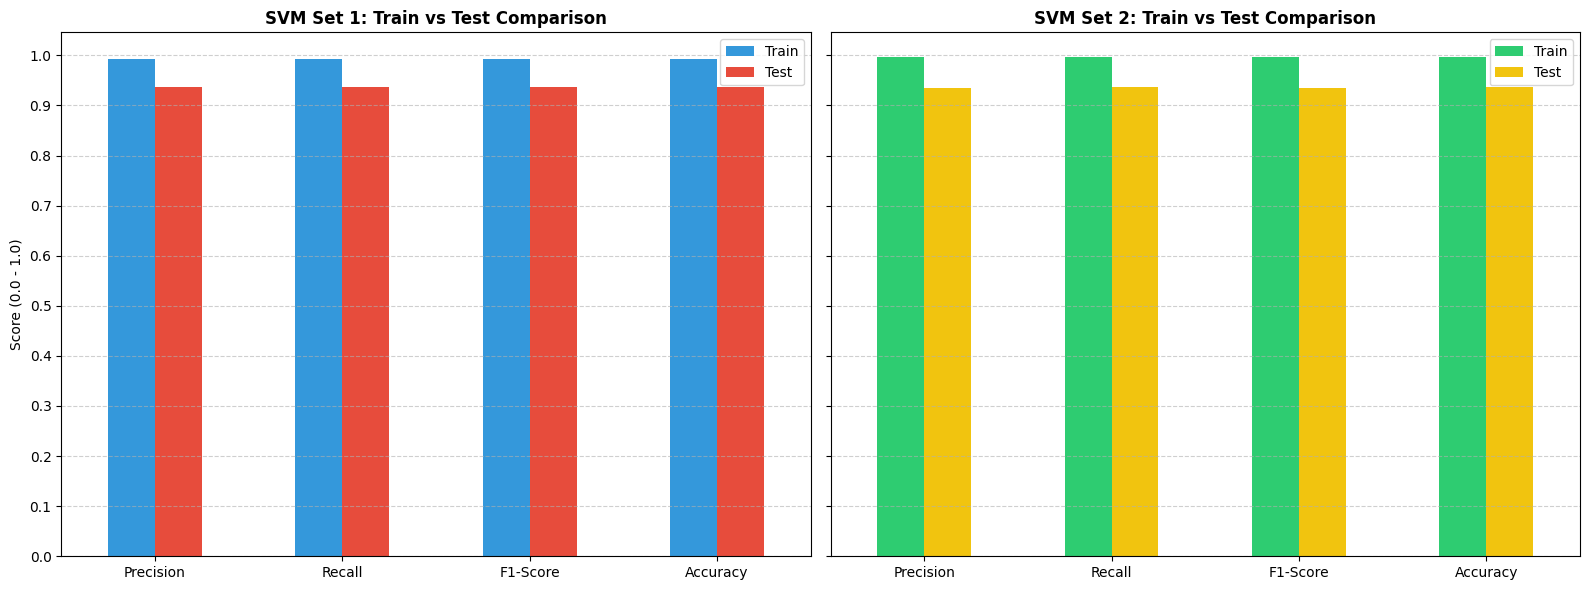

In [14]:
# Plot classification report

def get_metrics_comparison(y_true, y_pred, name):
    report = classification_report(y_true, y_pred, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    
    # Extract Macro Averages for a balanced comparison
    metrics = {
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-Score': report['macro avg']['f1-score'],
        'Accuracy': acc
    }
    return pd.Series(metrics, name=name)

# --- Prepare Data for Set 1 ---
s1_train = get_metrics_comparison(y_train, y_pred2, 'Train')
s1_test = get_metrics_comparison(y_test, y_pred3, 'Test')
df_set1 = pd.concat([s1_train, s1_test], axis=1)

# --- Prepare Data for Set 2 ---
s2_train = get_metrics_comparison(y_train, y_pred4, 'Train')
s2_test = get_metrics_comparison(y_test, y_pred5, 'Test')
df_set2 = pd.concat([s2_train, s2_test], axis=1)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot Set 1
df_set1.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'], rot=0)
ax1.set_title('SVM Set 1: Train vs Test Comparison', fontweight='bold')
ax1.set_ylabel('Score (0.0 - 1.0)')
ax1.set_yticks(np.arange(0,1.1,0.1))
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Plot Set 2
df_set2.plot(kind='bar', ax=ax2, color=['#2ecc71', '#f1c40f'], rot=0)
ax2.set_title('SVM Set 2: Train vs Test Comparison', fontweight='bold')
ax2.set_yticks(np.arange(0,1.1,0.1))
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

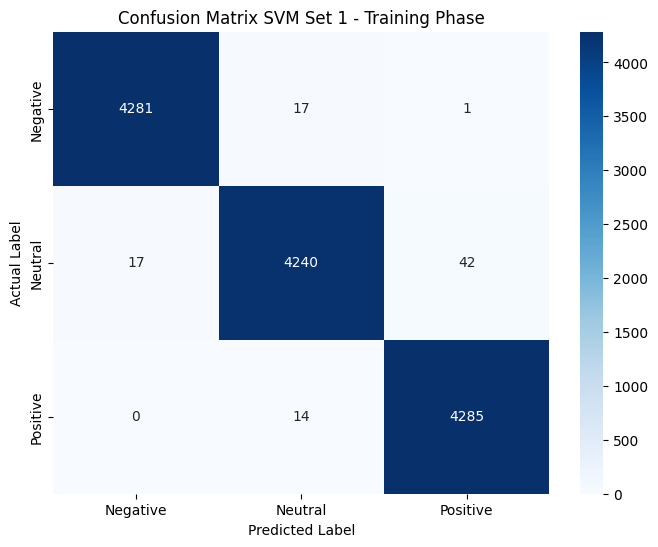

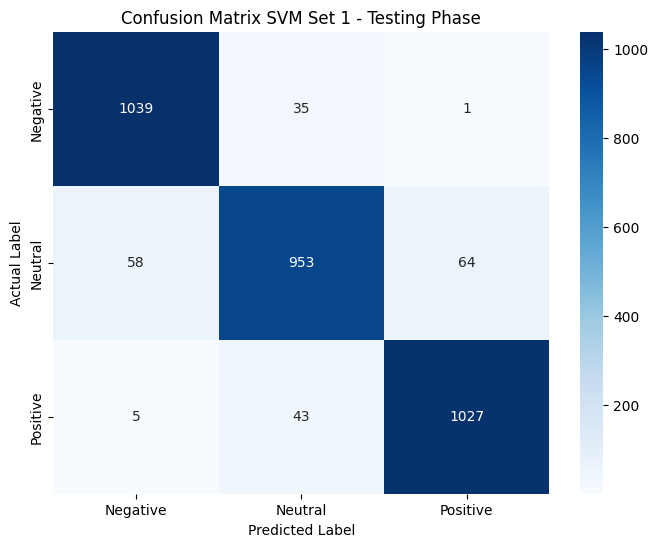

In [16]:
# Confusion Matrix Plot

labels = ['Negative', 'Neutral', 'Positive']
# Confusion matrix
cm = confusion_matrix(y_train, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.title('Confusion Matrix SVM Set 1 - Training Phase')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred3)

plt.figure(figsize=(8, 6))
sns.heatmap(cm2, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.title('Confusion Matrix SVM Set 1 - Testing Phase')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


### Note:
SVM Linear (LinearSVC(C=1, class_weight='balanced', dual=False, random_state=42)) has better performance than 2nd model SVC(C=100, kernel='rbf', class_weight='balanced', random_state=42 )


In [47]:
def prepare_evaluation_sample(df_test, n):
    # Stratified sample to ensure equal representation of classes
    cols = df_test.columns
    return df_test.groupby('Encoded_Sentiment', group_keys=False)[cols].apply(lambda x: x.sample(n=min(len(x), n//3), random_state=42))
df_test = pd.concat([X_test_text,y_test], axis=1)

for i in [600,1200, 2100, 3000]:
    eval_df = prepare_evaluation_sample(df_test,i)
    X_test_balanced = eval_df['Feedback_Clean']
    y_test_balanced = eval_df['Encoded_Sentiment']
# ==========================================
# 5. Evaluation
# ==========================================
#X_train_tfidf2 = tfidf_vectorizer.fit_transform(X_trainML_text)
    X_test_tfidf_balanced = tfidf_vectorizer.transform(X_test_balanced)

    y_pred2 = best_model_svm.predict(X_test_tfidf_balanced)

    print("\n--- Model Evaluation on ", i ," equally Test Set ---")
    print(classification_report(y_test_balanced, y_pred2,digits=4))




--- Model Evaluation on  600  equally Test Set ---
              precision    recall  f1-score   support

           0     0.9381    0.9850    0.9610       200
           1     0.9309    0.8750    0.9021       200
           2     0.9356    0.9450    0.9403       200

    accuracy                         0.9350       600
   macro avg     0.9349    0.9350    0.9344       600
weighted avg     0.9349    0.9350    0.9344       600


--- Model Evaluation on  1200  equally Test Set ---
              precision    recall  f1-score   support

           0     0.9336    0.9850    0.9586       400
           1     0.9412    0.8800    0.9096       400
           2     0.9431    0.9525    0.9478       400

    accuracy                         0.9392      1200
   macro avg     0.9393    0.9392    0.9387      1200
weighted avg     0.9393    0.9392    0.9387      1200


--- Model Evaluation on  2100  equally Test Set ---
              precision    recall  f1-score   support

           0     0.9415  

/tmp/ipykernel_946489/364780813.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


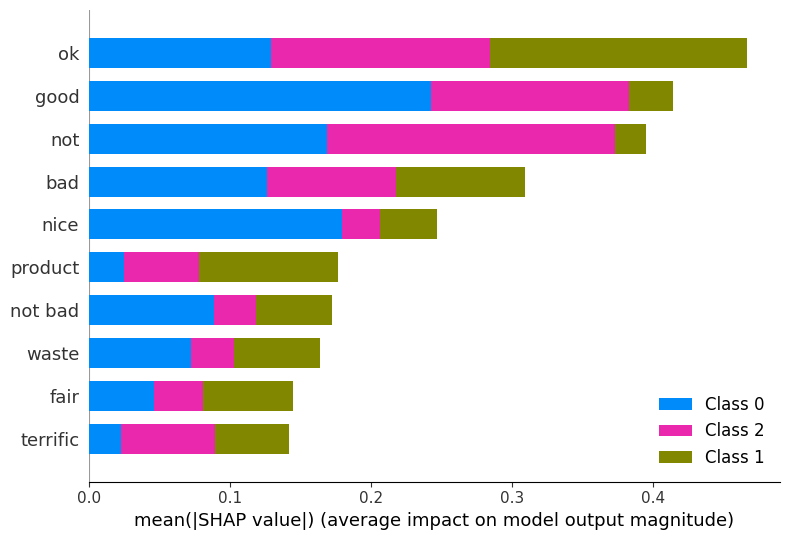

In [28]:
#
# Apply SHAP for SVM Development
#
# ------------------------------------------------
# Use balanced trainset as background
# ------------------------------------------------

# ------------------------------------------------
# Linear SHAP on decision_function (NOT proba)
# ------------------------------------------------
svm_explainer = shap.LinearExplainer(
    best_model_svm,
    X_train_tfidf #all train
)

# ------------------------------------------------
# 3. Explain ONLY small test subset
# ------------------------------------------------

#print("Generating SHAP Explanations for SubSet 600...")
#eval_df = prepare_evaluation_sample(df_test,600)
#X_smalltest_balanced = eval_df['Feedback_Clean']
#y_smalltest_balanced = eval_df['Encoded_Sentiment']
#X_smalltest_tfidf_balanced = tfidf_vectorizer.transform(X_smalltest_balanced)
#y_pred_smalltest = best_model_svm.predict(X_smalltest_tfidf_balanced)

# ------------------------------------------------
# 3. Explain full balanced test subset
# ------------------------------------------------
#svm_shap_values = svm_explainer.shap_values(X_smalltest_tfidf_balanced)
svm_shap_values = svm_explainer.shap_values(X_test_tfidf)

# ------------------------------------------------
# 4. Feature reduction BEFORE plotting
# ------------------------------------------------
svm_mean_abs_shap = np.abs(svm_shap_values).mean(axis=(0, 2))

# Sort indices (IMPORTANT)

top_idx = np.argsort(svm_mean_abs_shap)[-10:]
svm_shap_values_top = svm_shap_values[:, top_idx, :]

#X_test_top = X_smalltest_tfidf_balanced[:, top_idx]
X_test_top = X_test_tfidf[:, top_idx]
svm_feature_names_top = tfidf_vectorizer.get_feature_names_out()[top_idx]

# ------------------------------------------------
# 5. SAFE bar plot (global explanation)
# ------------------------------------------------
plt.figure()
shap.summary_plot(
    svm_shap_values_top,
    X_test_top,
    feature_names=svm_feature_names_top,
    plot_type="bar",
    max_display=10,
    show=True
)

In [29]:
X_test_tfidf.shape[0]

3225

Generating SHAP Explanations for Full Test Set
(3225, 55250, 3)


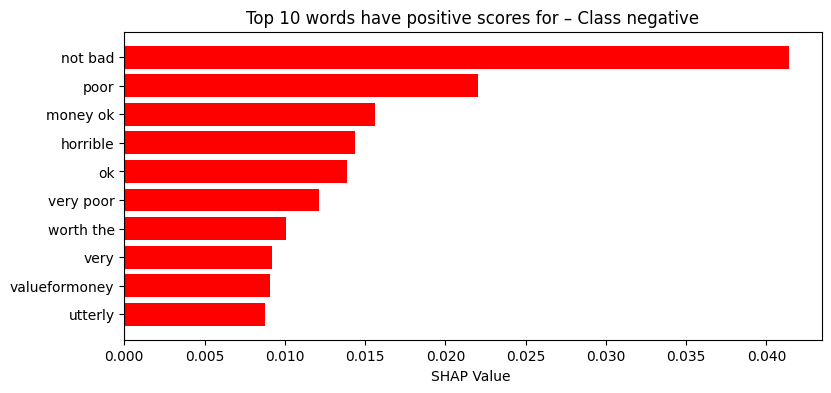

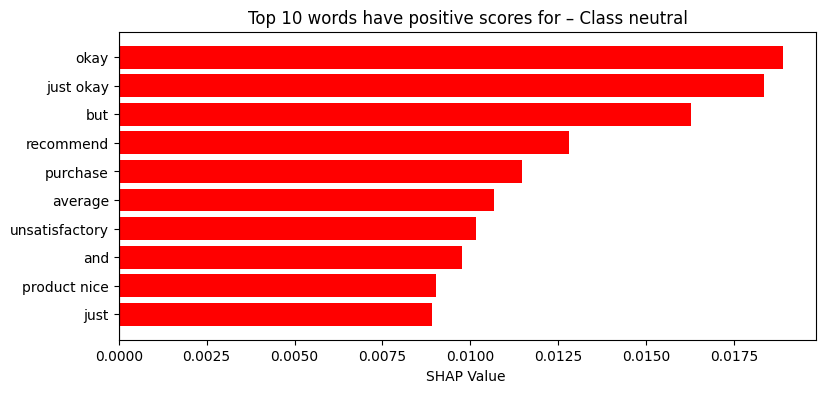

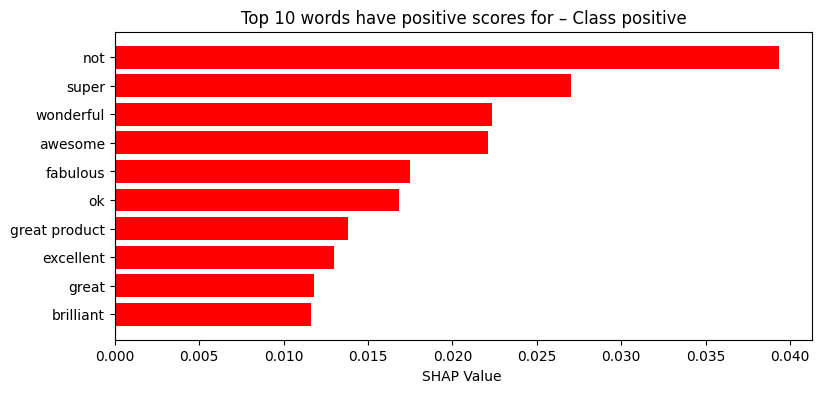

In [30]:
#
# Apply SHAP for SVM Development
# 
id2label={0: "negative", 1: "neutral", 2: "positive"}

# ------------------------------------------------

svm_explainer = shap.LinearExplainer(
    best_model_svm,
    X_train_tfidf #all train
)
# ------------------------------------------------
# 3. Explain ONLY small test subset
# ------------------------------------------------

#print("Generating SHAP Explanations for Subset 600...")
#eval_df = prepare_evaluation_sample(df_test,600)
#X_smalltest_balanced = eval_df['Feedback_Clean']
#y_smalltest_balanced = eval_df['Encoded_Sentiment']
#X_smalltest_tfidf_balanced = tfidf_vectorizer.transform(X_smalltest_balanced)
#y_pred_smalltest = best_model_svm.predict(X_smalltest_tfidf_balanced)

print("Generating SHAP Explanations for Full Test Set")
y_pred = best_model_svm.predict(X_test_tfidf)
svm_shap_values_small = svm_explainer.shap_values(X_test_tfidf)
svm_feature_names_small = tfidf_vectorizer.get_feature_names_out()
n_classes = svm_shap_values_small.shape[2]
print(svm_shap_values_small.shape)
for class_id in range(n_classes):
   
    class_label = id2label[class_id]

    svm_feature_names_top_small = ""
    # --- Mean absolute SHAP for THIS class ---
    svm_mean_signed_shap_class_small = svm_shap_values_small[:, :, class_id].mean(axis=0)
    svm_mean_abs_shap_class_small =np.abs(svm_mean_signed_shap_class_small)
    # --- Top 10 features - Get positive only---
    pos_idx = np.where(svm_mean_signed_shap_class_small > 0)[0]
    pos_idx_sorted = pos_idx[np.argsort(svm_mean_signed_shap_class_small[pos_idx])[::-1]]

    #top_idx_small = np.argsort(svm_mean_abs_shap_class_small)[-10:]
    top_idx_small = pos_idx_sorted[:10]
    svm_shap_values_top_small = svm_mean_signed_shap_class_small[top_idx_small]
    svm_feature_names_top_small = svm_feature_names_small[top_idx_small]
    
    plt.figure(figsize=(9, 4))
    colors = ["red" if v > 0 else "blue" for v in svm_shap_values_top_small]

    plt.barh(svm_feature_names_top_small, svm_shap_values_top_small, color=colors)
    plt.axvline(0, color="black")  # zero line = direction change
    plt.xlabel("SHAP Value ")
    plt.title(f"Top 10 words have positive scores for – Class {class_label}")
    plt.gca().invert_yaxis()
    plt.show()
    


(3225, 55250, 3)


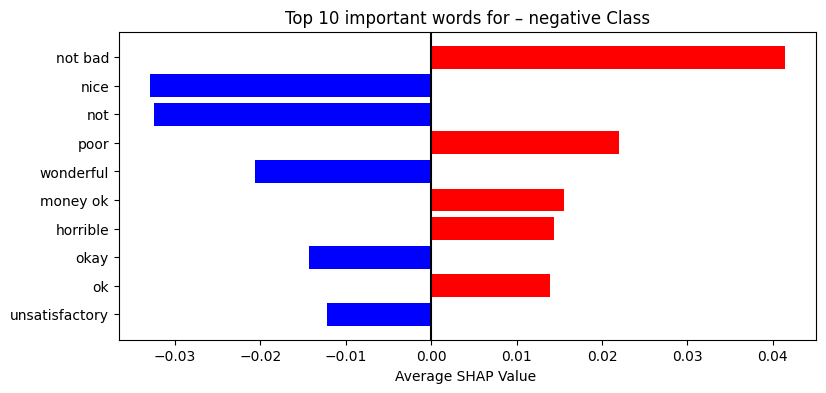

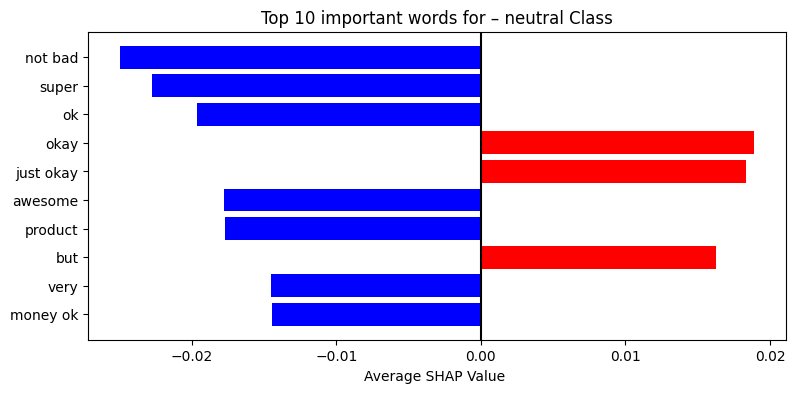

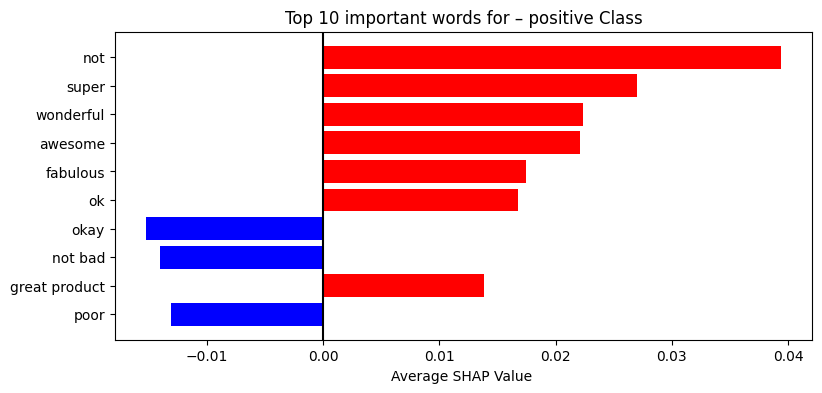

In [31]:
id2label={0: "negative", 1: "neutral", 2: "positive"}
#svm_shap_values_small = svm_explainer.shap_values(X_smalltest_tfidf_balanced)
svm_shap_values_small = svm_explainer.shap_values(X_test_tfidf)

svm_feature_names_small = tfidf_vectorizer.get_feature_names_out()
n_classes = svm_shap_values_small.shape[2]
print(svm_shap_values_small.shape)
for class_id in range(n_classes):
    class_label = id2label[class_id]
    svm_feature_names_top_small = ""
    # --- Mean absolute SHAP for THIS class ---
    svm_mean_signed_shap_class_small = svm_shap_values_small[:, :, class_id].mean(axis=0)
    svm_mean_abs_shap_class_small =np.abs(svm_mean_signed_shap_class_small)
    # --- Top 10 features - Get all score---

    top_idx_small = np.argsort(svm_mean_abs_shap_class_small)[-10:]
    top_idx_small = top_idx_small[np.argsort(svm_mean_abs_shap_class_small[top_idx_small])[::-1]]
    svm_shap_values_top_small = svm_mean_signed_shap_class_small[top_idx_small]
    svm_feature_names_top_small = svm_feature_names_small[top_idx_small]
    
    plt.figure(figsize=(9, 4))
    colors = ["red" if v > 0 else "blue" for v in svm_shap_values_top_small]

    plt.barh(svm_feature_names_top_small, svm_shap_values_top_small, color=colors)
    plt.axvline(0, color="black")  # zero line = direction change
    plt.xlabel("Average SHAP Value ")
    plt.title(f"Top 10 important words for – {class_label} Class" )
    plt.gca().invert_yaxis()
    plt.show()
    

In [65]:
# Check some words . Confirm it is actually in the vectorizer's memory
print("Is 'not' in the vocabulary?:", "not" in tfidf_vectorizer.vocabulary_)



# Search for the exact phrase ignoring case
contains_phrase = X_train_text.str.lower().str.contains("not", na=False)

# Search for the words separated by punctuation or stopwords (using a regex)
# This looks for "money" followed by 1-3 words/punctuation, then "ok"
contains_separated = X_train_text.str.lower().str.contains(r"money\W+(?:\w+\W+){0,2}ok\b", regex=True, na=False)

print(f"\nExact matches found: {contains_phrase.sum()}")
print(f"Separated matches found: {contains_separated.sum()}")
print(n_classes)
for i in range(len(contains_phrase)):
    if (contains_phrase.iloc[i] == True and y_train.iloc[i]==2):
        print("\nHere are the exact match reviews:")
        print(X_train_text.iloc[i])
    
if contains_separated.sum() > 0:
    print("\nHere are the separated match reviews (stopwords/punctuation removed):")
    print(X_train_text[contains_separated].head(10))

Is 'not' in the vocabulary?: True

Exact matches found: 3810
Separated matches found: 78
3

Here are the exact match reviews:
mindblowing purchase great product this come with very nice packing by seller not a single crack or scratch in it also its brand new mfg and truly original generally people avoid this type of stuff online but I try also have return policy for any damage so I order it and within 3 day they deliver this amazing room cooler now come in price range its little costly but crompton do not compromise quality major feature already you can see in description other than this fan be little noisy and its wit

Here are the exact match reviews:
worth the money have not use it yet but look average bat and kit good for price

Here are the exact match reviews:
brilliant this be an awesome product from boat and with the offer price its a real steal a bit dissapointed with the charge cable quality but any common microusb charge cable will work fine with it good battery life and fas

In [63]:
 svm_shap_values_small[:, :, class_id].mean(axis=0)

array([0., 0., 0., ..., 0., 0., 0.], shape=(55250,))

Raw review:
really nice very nice product fast speed slim product run smoothly thank flipkart for within 24 hrs delivery

Predicted class: 2

Actual class: 2
              word     tfidf  shap_value  abs_shap
21           thank  0.143844    0.255800  0.255800
24       very nice  0.142767    0.182616  0.182616
14          really  0.127333    0.103807  0.103807
2         delivery  0.147894    0.100249  0.100249
3             fast  0.157265    0.096450  0.096450
7              for  0.094305    0.082520  0.082520
9             nice  0.170302    0.081690  0.081690
16             run  0.187909    0.077144  0.077144
12         product  0.114568    0.069196  0.069196
22  thank flipkart  0.190877    0.066199  0.066199


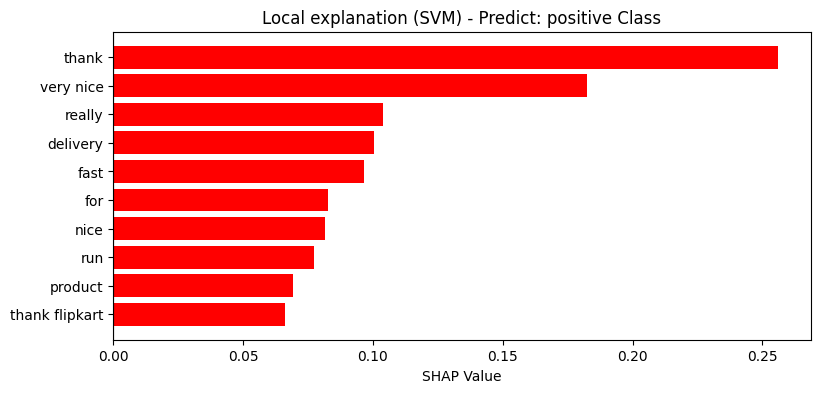

In [34]:
# Check some senc
id2label={0: "negative", 1: "neutral", 2: "positive"}

# Instance to explain 170, 197, 219
i = 219
class_id = y_pred[i]
class_label = id2label[class_id]

print("Raw review:")
print(X_test_text.iloc[i])

print("\nPredicted class:", y_pred[i])
print("\nActual class:", y_test.iloc[i])
# SHAP values for instance & class
svm_shap_values_instance = svm_shap_values_small[i][:, class_id]
x_instance = X_test_tfidf[i].toarray()[0]

# Keep only words present in the review
nonzero_idx = x_instance.nonzero()[0]

df_local = pd.DataFrame({
    "word": tfidf_vectorizer.get_feature_names_out()[nonzero_idx],
    "tfidf": x_instance[nonzero_idx],
    "shap_value": svm_shap_values_instance[nonzero_idx],
    "abs_shap": np.abs(svm_shap_values_instance[nonzero_idx])
})

# Sort by absolute impact
df_local = df_local.sort_values("abs_shap", ascending=False)
print(df_local.head(10))
top_k = 10
df_plot = df_local.head(top_k)

plt.figure(figsize=(9, 4))
colors = ["red" if v > 0 else "blue" for v in df_plot["shap_value"]]

plt.barh(df_plot["word"], df_plot["shap_value"], color=colors)
plt.axvline(0, color="black")
plt.xlabel("SHAP Value")
plt.title(f"Local explanation (SVM) - Predict: {class_label} Class")
plt.gca().invert_yaxis()
plt.show()

### NOTE 
0: Negative
1: Neutral
2: Positive 

In [58]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_session_svm_balanceddata_fulltest_240126.db'))

In [3]:
results_all = {}
sentiment_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}
def extract_top10_shap_one_row(svm_shap_values, X_tfidf, sample_idx, class_id, svm_feature_names):
    # SHAP values for this instance & predicted class
    shap_inst = svm_shap_values[sample_idx][:, class_id]

    # TF-IDF vector
    x_inst = X_tfidf[sample_idx].toarray()[0]

    # Only words present in the review
    nonzero_idx = x_inst.nonzero()[0]

    if len(nonzero_idx) == 0:
        return []

    # Absolute SHAP for present words
    abs_shap = np.abs(shap_inst[nonzero_idx])

    # Top 10 indices (or fewer if <10 words)
    top_k = min(10, len(abs_shap))
    top_idx = np.argsort(abs_shap)[-top_k:][::-1]

    return [
        (svm_feature_names[nonzero_idx[j]], shap_inst[nonzero_idx[j]])
        for j in top_idx
    ]



X_test_balanced = X_test_text
y_test_balanced = y_test

# ----------------------------------
# TF-IDF + Prediction
# ----------------------------------
X_test_tfidf_balanced = tfidf_vectorizer.transform(X_test_balanced)
y_pred_balanced = best_model_svm.predict(X_test_tfidf_balanced)

# ----------------------------------
# SHAP values
# shape: (n_samples, n_features)
# ----------------------------------
svm_shap_values = svm_explainer.shap_values(X_test_tfidf_balanced)

# ----------------------------------
# Build result DataFrame
# ----------------------------------
svm_feature_names = tfidf_vectorizer.get_feature_names_out()

rows = []

for i in range(len(y_pred_balanced)):
       class_id = y_pred_balanced[i]

       top10 = extract_top10_shap_one_row(
          svm_shap_values,
          X_test_tfidf_balanced,
          i,
          class_id,
          svm_feature_names
       )

       row = {
          "raw_index": X_test_text.index[i],
          "true_sentiment": sentiment_map[y_test_balanced.iloc[i]],
          "encoded_sentiment": y_test_balanced.iloc[i],
          "predicted_sentiment": sentiment_map[class_id],
          "Feedback_Clean": X_test_balanced.iloc[i],
       }

    # Fill top-10 (pad if fewer than 10)
       row[f"svm_shap_top_features"] = ", ".join(word for word, _ in top10)
       #for k in range(10):
       #  if k < len(top10):
       #     row[f"svm_shap_feature_{k+1}"] = top10[k][0]
       #     row[f"svm_shap_value_{k+1}"] = top10[k][1]
       #  else:
       #     row[f"svm_shap_feature_{k+1}"] = None
       #     row[f"svm_shap_value_{k+1}"] = None

       rows.append(row)

result_df = pd.DataFrame(rows)
print(result_df.head(10))
print(result_df.shape)
# ----------------------------------
# Save
# ----------------------------------
file_name = f"Balanceddata_svm_evaluation_full_samples_2401.csv"
result_df.to_csv(file_name, index=False, encoding="utf-8-sig")

results_all[i] = result_df

print(f"Saved: {file_name}")


   raw_index true_sentiment  encoded_sentiment predicted_sentiment  \
0      11110       positive                  2            positive   
1       6752        neutral                  1            negative   
2      10378        neutral                  1             neutral   
3        525       negative                  0            negative   
4       8542        neutral                  1             neutral   
5       6285        neutral                  1             neutral   
6      10741        neutral                  1             neutral   
7      15475       positive                  2            positive   
8       9109        neutral                  1             neutral   
9       2294       negative                  0            negative   

                                      Feedback_Clean  \
0              perfect product very nice memory card   
1  good 5 star for the product delivery be on tim...   
2                           good too hot while grind   
3    

In [4]:
type(svm_shap_values), np.array(svm_shap_values).shape


(numpy.ndarray, (3225, 55250, 3))

In [5]:
print(y_train.shape ,X_train_text.shape)
print(X.shape,y.shape)
X_train_text.head()

(12897,) (12897,)
(16122,) (16122,)


10738          decent product too much noise at full speed
11085    mindblowing purchase nice and gud quality product
4310     terrible product bad product remort be not wor...
6213                          do the job not upto the mark
142                            unsatisfactory poor product
Name: Feedback_Clean, dtype: object

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
#
# BERT DEVELOPMENT - SET1
#
import pandas as pd
import numpy as np
import torch
import os 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
import shap


# Check if GPU is available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 
# Split training set to train and evaluation set
X_bert_train_text, X_bert_eval_text, y_bert_train, y_bert_eval = train_test_split(X_train_text, y_train, test_size=0.20, random_state=42, stratify=y_train) 

# Tokenization (BERT-base-cased)

bert_train_texts=X_bert_train_text.astype(str).tolist()
bert_train_labels=y_bert_train.tolist()
bert_eval_texts = X_bert_eval_text.astype(str).tolist()
bert_eval_labels = y_bert_eval.tolist()

# Bert test set is the same SVM test set
bert_test_texts=X_test_text.astype(str).tolist()
bert_test_labels=y_test.tolist()

tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

def tokenize_function(texts_list):
    return tokenizer(
        texts_list,
        padding='max_length',     # Pad to max_length
        truncation=True,          # Truncate if longer
        max_length=160,           # As specified in thesis
        return_tensors="pt"       # Return PyTorch tensors
    )

# Tokenize data
train_encodings = tokenize_function(bert_train_texts)
eval_encodings = tokenize_function(bert_eval_texts)
test_encodings = tokenize_function(bert_test_texts)

# Create a Torch Dataset Class
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, bert_train_labels)
eval_dataset = ReviewDataset(eval_encodings, bert_eval_labels)
test_dataset = ReviewDataset(test_encodings, bert_test_labels)

# Iighted Cross-Entropy Loss Setup
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(bert_train_labels),
    y=bert_train_labels
)
# Convert to Tensor and move to GPU/CPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define a Custom Trainer to inject the Iighted Loss
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define the IiNone
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Model Initialization & Training
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-cased',
    num_labels=len(np.unique(bert_train_labels))
).to(device)
bert_results = checkpoint_dir + '/bert_dataBalancedset_results'
bert_logs = checkpoint_dir + '/bert_dataBalancedset_logs'

# Define checkpoint_path
bert_checkpoint_path = os.path.join(checkpoint_dir, 'bert_dataBalancedset_results')

# Define Hyperparameters (As specified in thesis)
training_args = TrainingArguments(
    output_dir=bert_results,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay =0.01,
    logging_dir=bert_logs,
    logging_strategy="epoch",
    
    # Disable automatic eval so it doesn't conflict with our manual callback
    eval_strategy="no", 
    save_strategy="epoch",
    load_best_model_at_end=False # We will find the best model manually via Pandas
)

#Callback to calculate trainset metric
# Update Callback to Calculate BOTH Train and Eval
class TrainMetricsCallback(TrainerCallback):
    def __init__(self, trainer):
        self.trainer = trainer
    
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"\n--- Epoch {state.epoch} End ---")
        
        # Calculate & Log TRAINING Metrics
        print("1. Calculating TRAINING metrics...")
        self.trainer.evaluate(
            eval_dataset=self.trainer.train_dataset, 
            metric_key_prefix="train"
        )
        
        # Calculate & Log VALIDATION Metrics (Manually Forced)
        print("2. Calculating VALIDATION metrics...")
        self.trainer.evaluate(
            eval_dataset=self.trainer.eval_dataset, 
            metric_key_prefix="eval"
        )
        
        return control
        
        
# Initialize Metric for Evaluation
def compute_metrics(pred):
    from sklearn.metrics import accuracy_score, f1_score
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Initialize Trainer
trainer = WeightedLossTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

trainer.add_callback(TrainMetricsCallback(trainer))

last_checkpoint = None
if os.path.isdir(bert_checkpoint_path) and len(os.listdir(bert_checkpoint_path)) > 0:
    # If the folder has contents, try to find the last checkpoint
    from transformers.trainer_utils import get_last_checkpoint
    last_checkpoint = get_last_checkpoint(bert_checkpoint_path)

# START TRAINING

print(f"Starting BERT Fine-tuning... (Resuming? {last_checkpoint is not None})")

if last_checkpoint:
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    trainer.train()


Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT Fine-tuning... (Resuming? True)


Step,Training Loss


In [5]:
# 1. Get History
history = trainer.state.log_history
df_log = pd.DataFrame(history)
df_log = df_log.head(10)
# 2. Separate Train and Eval logs
df_log

,epoch,step,train_accuracy,train_f1,train_loss,train_runtime,train_samples_per_second,train_steps_per_second,eval_accuracy,eval_f1,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,total_flos
0,1.0,645,0.956092,0.956140,0.126065,101.6203,101.525,6.347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,645,NaN,NaN,NaN,NaN,NaN,NaN,0.940310,0.940518,0.175948,25.5962,100.796,6.329,NaN
2,2.0,1290,0.971503,0.971506,0.086570,103.2412,99.931,6.248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,1290,NaN,NaN,NaN,NaN,NaN,NaN,0.948450,0.948482,0.172226,25.8785,99.697,6.260,NaN
4,3.0,1935,0.990113,0.990109,0.035326,103.8577,99.338,6.210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,1935,NaN,NaN,NaN,NaN,NaN,NaN,0.946512,0.946618,0.207514,26.0242,99.138,6.225,NaN
6,4.0,2580,0.991761,0.991756,0.028251,103.5386,99.644,6.230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.0,2580,NaN,NaN,NaN,NaN,NaN,NaN,0.943411,0.943083,0.266275,25.9375,99.470,6.246,NaN
8,5.0,3225,0.994669,0.994668,0.020419,103.5335,99.649,6.230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,3225,NaN,NaN,NaN,NaN,NaN,NaN,0.948450,0.948726,0.272538,25.8131,99.949,6.276,NaN


In [6]:
# Get History
history = trainer.state.log_history
df_log = pd.DataFrame(history)
df_log = df_log.head(20)
# Separate Train and Eval logs
# Filter rows that have 'train_loss' and 'eval_loss' respectively
train_logs = df_log.dropna(subset=['train_loss']).reset_index(drop=True)
eval_logs = df_log.dropna(subset=['eval_loss']).reset_index(drop=True)

# Select only the columns we care about
train_logs = train_logs[['epoch', 'train_loss', 'train_accuracy', 'train_f1']]
eval_logs = eval_logs[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1']]

# Merge them into one final table
final_df = pd.merge(train_logs, eval_logs, on='epoch')

# Save to CSV
final_df.to_csv("bert_BalancedDataSet_training_log.csv", index=False)
final_df

,epoch,train_loss,train_accuracy,train_f1,eval_loss,eval_accuracy,eval_f1
0,1.0,0.126065,0.956092,0.956140,0.175948,0.940310,0.940518
1,2.0,0.086570,0.971503,0.971506,0.172226,0.948450,0.948482
2,3.0,0.035326,0.990113,0.990109,0.207514,0.946512,0.946618
3,4.0,0.028251,0.991761,0.991756,0.266275,0.943411,0.943083
4,5.0,0.020419,0.994669,0.994668,0.272538,0.948450,0.948726
5,6.0,0.015875,0.995541,0.995541,0.286394,0.946899,0.947011
6,7.0,0.013458,0.995638,0.995636,0.304902,0.952326,0.952277
7,8.0,0.011955,0.995929,0.995927,0.316675,0.951163,0.951173
8,9.0,0.011081,0.995929,0.995928,0.337517,0.946512,0.946560
9,10.0,0.010676,0.996026,0.996024,0.345690,0.946899,0.946923


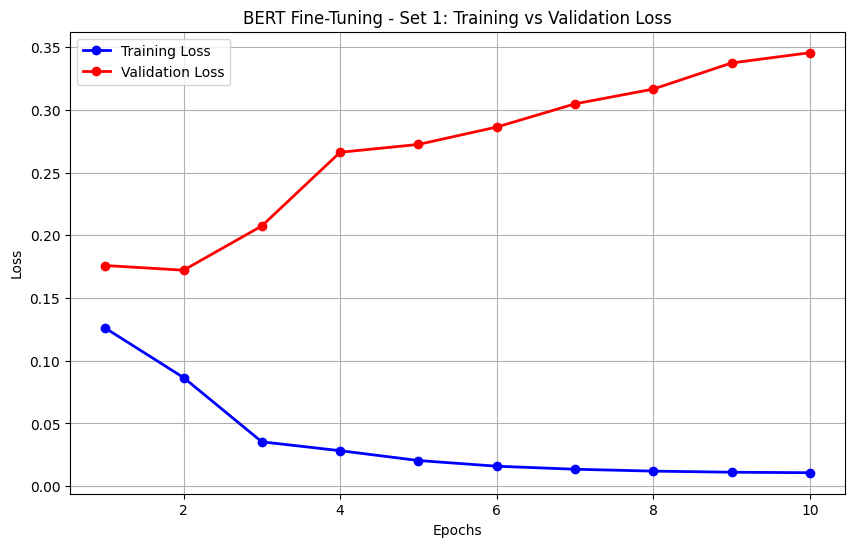

In [7]:
# Plot Training and Validation Loss

# Extract log history from the Trainer state
log_history = trainer.state.log_history

# Convert to DataFrame for easier handling
df_log = pd.DataFrame(log_history).head(20)

# Separate training and validation metrics
# Training logs contain 'loss', validation logs contain 'eval_loss'
train_log = df_log[df_log['train_loss'].notna()][['epoch', 'train_loss']]
eval_log = df_log[df_log['eval_loss'].notna()][['epoch', 'eval_loss']]

# Plotting
plt.figure(figsize=(10, 6))

# Plot Training Loss
plt.plot(train_log['epoch'], train_log['train_loss'], label='Training Loss', color='blue', marker='o', linewidth=2)

# Plot Validation Loss
plt.plot(eval_log['epoch'], eval_log['eval_loss'], label='Validation Loss', color='red', marker='o', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BERT Fine-Tuning - Set 1: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

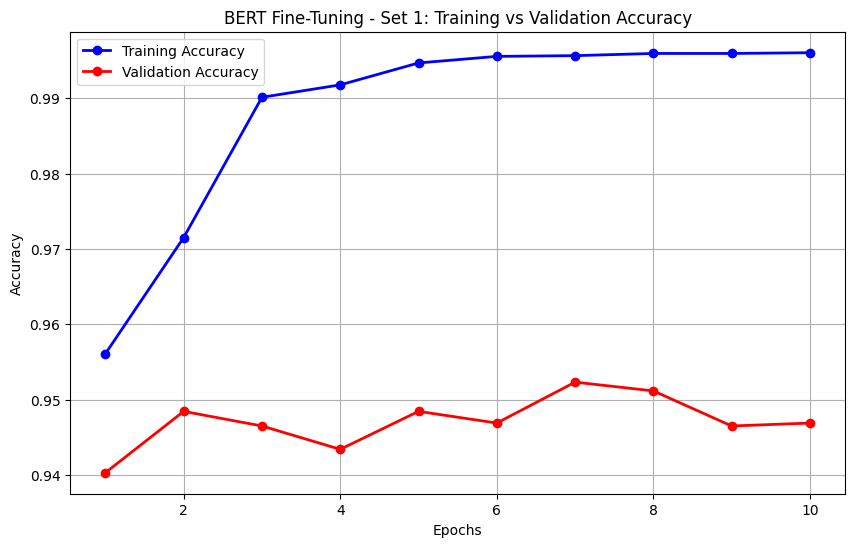

In [8]:
# Plot Training and Validation Loss

# Extract log history from the Trainer state
log_history = trainer.state.log_history

# Convert to DataFrame for easier handling
df_log = pd.DataFrame(log_history).head(20)

# Separate training and validation metrics
# Training logs contain 'loss', validation logs contain 'eval_loss'
train_acc_log = df_log[df_log['train_accuracy'].notna()][['epoch', 'train_accuracy']]
eval_acc_log = df_log[df_log['eval_accuracy'].notna()][['epoch', 'eval_accuracy']]

# Plotting
plt.figure(figsize=(10, 6))

# Plot Training Loss
plt.plot(train_acc_log['epoch'], train_acc_log['train_accuracy'], label='Training Accuracy', color='blue', marker='o', linewidth=2)

# Plot Validation Loss
plt.plot(eval_acc_log['epoch'], eval_acc_log['eval_accuracy'], label='Validation Accuracy', color='red', marker='o', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BERT Fine-Tuning - Set 1: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import shutil

# Identify the Best Checkpoint via Pandas - Lowest Validation Loss
history = trainer.state.log_history
df_log = pd.DataFrame(history)

# Filter for rows that actually have validation data
eval_log = df_log.dropna(subset=['eval_loss']).reset_index(drop=True)

# Find the row with the Lowest Validation Loss
best_row = eval_log.loc[eval_log['eval_loss'].idxmin()]
best_step = int(best_row['step'])
best_epoch = best_row['epoch']
best_loss = best_row['eval_loss']

print(f"\n Found Best Model at Epoch {best_epoch} (Step {best_step})")
print(f"   Best Eval Loss: {best_loss:.4f}")

# Construct the path to that specific checkpoint
bert_results = checkpoint_dir + '/bert_dataBalancedset_results'
bert_logs = checkpoint_dir + '/bert_dataBalancedset_logs'

best_checkpoint_path = os.path.join(bert_results, f"checkpoint-{best_step}")

print(f"   Loading model from: {best_checkpoint_path}")

# Load that Specific Model

best_model = BertForSequenceClassification.from_pretrained(best_checkpoint_path)
best_model.to(device)

# Update the Trainer to use this best model
trainer.model = best_model

# Print Key Configuration Parameters 
config = best_model.config
print("\n" + "="*40)
print(f"BEST MODEL CONFIGURATION - SET 1")
print("="*40)
print(f"• Model Type:          {config.model_type}")
print(f"• Number of Layers:    {config.num_hidden_layers}")
print(f"• Hidden Size:         {config.hidden_size}")
print(f"• Attention Heads:     {config.num_attention_heads}")
print(f"• Vocabulary Size:     {config.vocab_size}")
print(f"• Max Position Embed:  {config.max_position_embeddings}")
print(f"• Number of Labels:    {config.num_labels}")
print(f"• Hidden Dropout Prob: {config.hidden_dropout_prob}")

# Count Total & Trainable Parameters
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

print("\n" + "="*40)
print(f"PARAMETER COUNTS - SET 1")
print("="*40)
print(f"• Total Parameters:     {total_params:,}")
print(f"• Trainable Parameters: {trainable_params:,}")

# Print Full Layer Structure
print("\n" + "="*40)
print(f"MODEL ARCHITECTURE (LAYERS) - SET 1")
print("="*40)
print(best_model)


 Found Best Model at Epoch 2.0 (Step 1290)
   Best Eval Loss: 0.1722
   Loading model from: Checkpoints/bert_dataBalancedset_results/checkpoint-1290

BEST MODEL CONFIGURATION - SET 1
• Model Type:          bert
• Number of Layers:    12
• Hidden Size:         768
• Attention Heads:     12
• Vocabulary Size:     28996
• Max Position Embed:  512
• Number of Labels:    3
• Hidden Dropout Prob: 0.1

PARAMETER COUNTS - SET 1
• Total Parameters:     108,312,579
• Trainable Parameters: 108,312,579

MODEL ARCHITECTURE (LAYERS) - SET 1
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
       

In [10]:
from torchinfo import summary
import torch


# Define dummy input dimensions 
batch_size = 1
seq_len = 512
dummy_input = torch.zeros((batch_size, seq_len), dtype=torch.long)

# Generate the summary
model_stats = summary(
    best_model, 
    input_data=dummy_input,
    col_names=["num_params","output_size"],
    depth=3, 
    device="cuda"
)

print(model_stats)

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Layer (type:depth-idx)                                       Param #                   Output Shape
BertForSequenceClassification                                --                        [1, 3]
├─BertModel: 1-1                                             --                        [1, 768]
│    └─BertEmbeddings: 2-1                                   --                        [1, 512, 768]
│    │    └─Embedding: 3-1                                   22,268,928                [1, 512, 768]
│    │    └─Embedding: 3-2                                   1,536                     [1, 512, 768]
│    │    └─Embedding: 3-3                                   393,216                   [1, 512, 768]
│    │    └─LayerNorm: 3-4                                   1,536                     [1, 512, 768]
│    │    └─Dropout: 3-5                                     --                        [1, 512, 768]
│    └─BertEncoder: 2-2                                      --                        [1, 512, 768]
│  

In [11]:
# Classification Report

# BERT SET 1 - Evaluation Train Set
print("--- Bert Set 1 Evaluation on  Train Set...")
preds_train_output1 = trainer.predict(train_dataset)
y_preds1 = preds_train_output1.predictions.argmax(-1)

print(classification_report(bert_train_labels, y_preds1, digits=4))

# BERT SET 1 - Evaluation Test Set
print("--- Bert Set 1 Evaluation on Full Test Set...")
preds_output2 = trainer.predict(test_dataset)
y_preds2 = preds_output2.predictions.argmax(-1)
print(classification_report(bert_test_labels, y_preds2, digits=4))


--- Bert Set 1 Evaluation on  Train Set...


              precision    recall  f1-score   support

           0     0.9716    0.9951    0.9832      3439
           1     0.9500    0.9666    0.9582      3439
           2     0.9942    0.9529    0.9731      3439

    accuracy                         0.9715     10317
   macro avg     0.9719    0.9715    0.9715     10317
weighted avg     0.9719    0.9715    0.9715     10317

--- Bert Set 1 Evaluation on Full Test Set...


              precision    recall  f1-score   support

           0     0.9465    0.9870    0.9663      1075
           1     0.9151    0.9321    0.9235      1075
           2     0.9832    0.9228    0.9520      1075

    accuracy                         0.9473      3225
   macro avg     0.9482    0.9473    0.9473      3225
weighted avg     0.9482    0.9473    0.9473      3225



In [15]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_session_bertBalanceddata_set1_0702.db'))

In [12]:
#
# BERT DEVELOPMENT - SET 2
#
import pandas as pd
import numpy as np
import torch
import os 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
import shap


# Check if GPU is available (Crucial for BERT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# 
# Split training set to train and evaluation set
#

X_bert_train_text, X_bert_eval_text, y_bert_train, y_bert_eval = train_test_split(X_train_text, y_train, test_size=0.20, random_state=42, stratify=y_train) 


# Tokenization (BERT-base-cased)
bert_train_texts=X_bert_train_text.astype(str).tolist()
bert_train_labels=y_bert_train.tolist()
bert_eval_texts = X_bert_eval_text.astype(str).tolist()
bert_eval_labels = y_bert_eval.tolist()
# Bert test set is the same SVM test set

bert_test_texts=X_test_text.astype(str).tolist()
bert_test_labels=y_test.tolist()

tokenizer2 = BertTokenizer.from_pretrained('bert-base-cased')

def tokenize_function(texts_list):
    return tokenizer2(
        texts_list,
        padding='max_length',     # Pad to max_length
        truncation=True,          # Truncate if longer
        max_length=160,           # As specified in thesis
        return_tensors="pt"       # Return PyTorch tensors
    )

# Tokenize data
train_encodings = tokenize_function(bert_train_texts)
eval_encodings = tokenize_function(bert_eval_texts)
test_encodings = tokenize_function(bert_test_texts)

# Create a Torch Dataset Class
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = ReviewDataset(train_encodings, bert_train_labels)
eval_dataset = ReviewDataset(eval_encodings, bert_eval_labels)
test_dataset = ReviewDataset(test_encodings, bert_test_labels)

# Iighted Cross-Entropy Loss Setup
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(bert_train_labels),
    y=bert_train_labels
)
# Convert to Tensor and move to GPU/CPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define a Custom Trainer to inject the Iighted Loss
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define the IiNone
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Model Initialization & Training
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-cased',
    num_labels=len(np.unique(bert_train_labels))
).to(device)
bert_results = checkpoint_dir + '/bert_dataBalancedset2_wc_results'
bert_logs = checkpoint_dir + '/bert_dataBalancedset2_wc_logs'

# Define checkpoint_path
bert_checkpoint_path = os.path.join(checkpoint_dir, 'bert_dataBalancedset2_wc_results')

# Define Hyperparameters (As specified in thesis)
training_args2 = TrainingArguments(
    output_dir=bert_results,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-6,
    weight_decay=0.01,
    logging_dir=bert_logs,
    logging_strategy="epoch",
    
    # Disable automatic eval so it doesn't conflict with our manual callback
    eval_strategy="no", 
    save_strategy="epoch",
    load_best_model_at_end=False # We will find the best model manually via Pandas
)

# Callback to calculate trainset metric
# Update Callback to Calculate BOTH Train and Eval
class TrainMetricsCallback(TrainerCallback):
    def __init__(self, trainer):
        self.trainer = trainer
    
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"\n--- Epoch {state.epoch} End ---")
        
        # Calculate & Log TRAINING Metrics
        print("1. Calculating TRAINING metrics...")
        self.trainer.evaluate(
            eval_dataset=self.trainer.train_dataset, 
            metric_key_prefix="train"
        )
        
        # Calculate & Log VALIDATION Metrics (Manually Forced)
        print("2. Calculating VALIDATION metrics...")
        self.trainer.evaluate(
            eval_dataset=self.trainer.eval_dataset, 
            metric_key_prefix="eval"
        )
        
        return control
        
        
# Initialize Metric for Evaluation
def compute_metrics(pred):
    from sklearn.metrics import accuracy_score, f1_score
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Initialize Trainer
trainer2 = WeightedLossTrainer(
    model=bert_model,
    args=training_args2,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

trainer2.add_callback(TrainMetricsCallback(trainer2))

last_checkpoint = None
if os.path.isdir(bert_checkpoint_path) and len(os.listdir(bert_checkpoint_path)) > 0:
    # If the folder has contents, try to find the last checkpoint
    from transformers.trainer_utils import get_last_checkpoint
    last_checkpoint = get_last_checkpoint(bert_checkpoint_path)

# START TRAINING
print(f"Starting BERT Fine-tuning... (Resuming? {last_checkpoint is not None})")

if last_checkpoint:
    trainer2.train(resume_from_checkpoint=last_checkpoint)
else:
    trainer2.train()


Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT Fine-tuning... (Resuming? True)


Step,Training Loss


In [13]:
# Get History
history = trainer2.state.log_history
df_log2 = pd.DataFrame(history)
df_log2 = df_log2.head(10)
# Separate Train and Eval logs
df_log2

,epoch,step,train_accuracy,train_f1,train_loss,train_runtime,train_samples_per_second,train_steps_per_second,eval_accuracy,eval_f1,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,total_flos
0,1.0,645,0.925754,0.925232,0.229993,102.3582,100.793,6.301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,645,NaN,NaN,NaN,NaN,NaN,NaN,0.919380,0.919042,0.240247,25.6500,100.585,6.316,NaN
2,2.0,1290,0.941747,0.941407,0.162123,102.9257,100.237,6.267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,1290,NaN,NaN,NaN,NaN,NaN,NaN,0.937984,0.937593,0.175048,25.7687,100.122,6.287,NaN
4,3.0,1935,0.955801,0.955884,0.126837,103.0977,100.070,6.256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,1935,NaN,NaN,NaN,NaN,NaN,NaN,0.943798,0.943997,0.155908,25.7760,100.093,6.285,NaN
6,4.0,2580,0.961035,0.960883,0.115680,103.2108,99.960,6.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.0,2580,NaN,NaN,NaN,NaN,NaN,NaN,0.946512,0.946233,0.158015,25.8436,99.831,6.268,NaN
8,5.0,3225,0.964621,0.964703,0.111421,103.3759,99.801,6.239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,3225,NaN,NaN,NaN,NaN,NaN,NaN,0.946124,0.946384,0.165677,25.8734,99.716,6.261,NaN


In [14]:
# Get History
history2 = trainer2.state.log_history
df_log2 = pd.DataFrame(history2)
df_log2 = df_log2.head(20)
# Separate Train and Eval logs
# Filter rows that have 'train_loss' and 'eval_loss' respectively
train_logs2 = df_log2.dropna(subset=['train_loss']).reset_index(drop=True)
eval_logs2 = df_log2.dropna(subset=['eval_loss']).reset_index(drop=True)

# Select only the columns we care about
train_logs2 = train_logs2[['epoch', 'train_loss', 'train_accuracy', 'train_f1']]
eval_logs2 = eval_logs2[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1']]

# Merge them into one final table
final_df2 = pd.merge(train_logs2, eval_logs2, on='epoch')

#print(final_df)
# Save to CSV
final_df2.to_csv("bert_BalancedDataSet2_training_log.csv", index=False)
final_df2

,epoch,train_loss,train_accuracy,train_f1,eval_loss,eval_accuracy,eval_f1
0,1.0,0.229993,0.925754,0.925232,0.240247,0.919380,0.919042
1,2.0,0.162123,0.941747,0.941407,0.175048,0.937984,0.937593
2,3.0,0.126837,0.955801,0.955884,0.155908,0.943798,0.943997
3,4.0,0.115680,0.961035,0.960883,0.158015,0.946512,0.946233
4,5.0,0.111421,0.964621,0.964703,0.165677,0.946124,0.946384
5,6.0,0.096272,0.970825,0.970737,0.168369,0.948837,0.948652
6,7.0,0.092926,0.972666,0.972641,0.170731,0.948837,0.948772
7,8.0,0.087784,0.973830,0.973864,0.176582,0.948450,0.948602
8,9.0,0.085065,0.975187,0.975195,0.179485,0.948837,0.948896
9,10.0,0.082765,0.975962,0.975961,0.179354,0.950388,0.950416


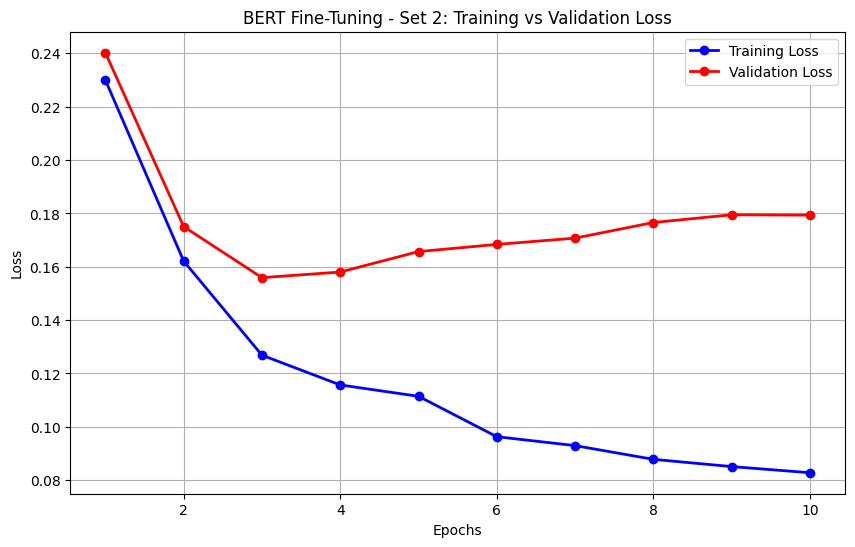

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# Plot Training and Validation Loss
# ==========================================

# Extract log history from the Trainer state
log_history2 = trainer2.state.log_history

# Convert to DataFrame for easier handling
df_log2 = pd.DataFrame(log_history2).head(20)

# Separate training and validation metrics
# Training logs contain 'loss', validation logs contain 'eval_loss'
train_log2 = df_log2[df_log2['train_loss'].notna()][['epoch', 'train_loss']]
eval_log2 = df_log2[df_log2['eval_loss'].notna()][['epoch', 'eval_loss']]

# Plotting
plt.figure(figsize=(10, 6))

# Plot Training Loss
plt.plot(train_log2['epoch'], train_log2['train_loss'], label='Training Loss', color='blue', marker='o', linewidth=2)

# Plot Validation Loss
plt.plot(eval_log2['epoch'], eval_log2['eval_loss'], label='Validation Loss', color='red', marker='o', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BERT Fine-Tuning - Set 2: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

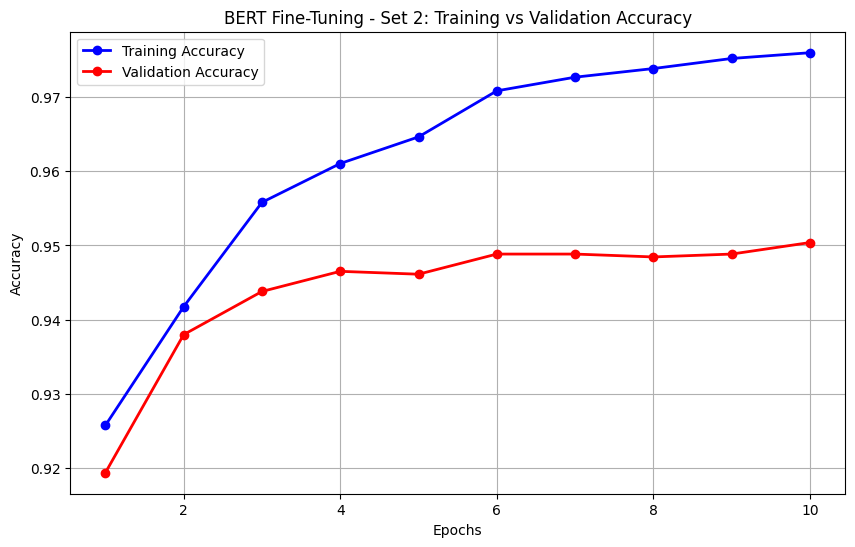

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# Plot Training and Validation Loss
# ==========================================

# Extract log history from the Trainer state
log_history2 = trainer2.state.log_history

# Convert to DataFrame for easier handling
df_log2 = pd.DataFrame(log_history2).head(20)

# Separate training and validation metrics
# Training logs contain 'loss', validation logs contain 'eval_loss'
train_acc_log2 = df_log2[df_log2['train_accuracy'].notna()][['epoch', 'train_accuracy']]
eval_acc_log2 = df_log2[df_log2['eval_accuracy'].notna()][['epoch', 'eval_accuracy']]

# Plotting
plt.figure(figsize=(10, 6))

# Plot Training Loss
plt.plot(train_acc_log2['epoch'], train_acc_log2['train_accuracy'], label='Training Accuracy', color='blue', marker='o', linewidth=2)

# Plot Validation Loss
plt.plot(eval_acc_log2['epoch'], eval_acc_log2['eval_accuracy'], label='Validation Accuracy', color='red', marker='o', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BERT Fine-Tuning - Set 2: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import pandas as pd
import shutil


#  Choose the Best Checkpoint via Pandas - Lowest eval loss
history2 = trainer2.state.log_history
df_log = pd.DataFrame(history2)

# Filter for rows that actually have validation data
eval_log = df_log.dropna(subset=['eval_loss']).reset_index(drop=True)

# Find the row with the lowest Validation Loss
best_row = eval_log.loc[eval_log['eval_loss'].idxmin()]
best_step = int(best_row['step'])
best_epoch = best_row['epoch']
best_loss = best_row['eval_loss']

print(f"\n Found Best Model at Epoch {best_epoch} (Step {best_step})")
print(f"   Best Eval Loss: {best_loss:.4f}")

# Construct the path to that specific checkpoint
ert_results = checkpoint_dir + '/bert_dataBalancedset2_wc_results'
bert_logs = checkpoint_dir + '/bert_dataBalancedset2_wc_logs'

best_checkpoint_path = os.path.join(bert_results, f"checkpoint-{best_step}")

print(f"   Loading model from: {best_checkpoint_path}")

# Load that specific model
best_model = BertForSequenceClassification.from_pretrained(best_checkpoint_path)
best_model.to(device)

# Update the Trainer to use this best model
trainer2.model = best_model

# Print Key Configuration Parameters
config = best_model.config
print("\n" + "="*40)
print(f"BEST MODEL CONFIGURATION")
print("="*40)
print(f"• Model Type:          {config.model_type}")
print(f"• Number of Layers:    {config.num_hidden_layers}")
print(f"• Hidden Size:         {config.hidden_size}")
print(f"• Attention Heads:     {config.num_attention_heads}")
print(f"• Vocabulary Size:     {config.vocab_size}")
print(f"• Max Position Embed:  {config.max_position_embeddings}")
print(f"• Number of Labels:    {config.num_labels}")
print(f"• Hidden Dropout Prob: {config.hidden_dropout_prob}")

# Count Total & Trainable Parameters
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

print("\n" + "="*40)
print(f"PARAMETER COUNTS")
print("="*40)
print(f"• Total Parameters:     {total_params:,}")
print(f"• Trainable Parameters: {trainable_params:,}")

# Print Full Layer Structure
print("\n" + "="*40)        
print(f"MODEL ARCHITECTURE (LAYERS)")
print("="*40)
print(best_model)


 Found Best Model at Epoch 3.0 (Step 1935)
   Best Eval Loss: 0.1559
   Loading model from: Checkpoints/bert_dataBalancedset2_wc_results/checkpoint-1935

BEST MODEL CONFIGURATION
• Model Type:          bert
• Number of Layers:    12
• Hidden Size:         768
• Attention Heads:     12
• Vocabulary Size:     28996
• Max Position Embed:  512
• Number of Labels:    3
• Hidden Dropout Prob: 0.1

PARAMETER COUNTS
• Total Parameters:     108,312,579
• Trainable Parameters: 108,312,579

MODEL ARCHITECTURE (LAYERS)
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): Bert

In [18]:
from torchinfo import summary
import torch

# Define dummy input dimensions 
batch_size = 1
seq_len = 512
dummy_input = torch.zeros((batch_size, seq_len), dtype=torch.long)

# Generate the summary
model_stats = summary(
    best_model, 
    input_data=dummy_input,
    col_names=["num_params","output_size"],
    depth=3,
    device="cuda"
)

print(model_stats)

Layer (type:depth-idx)                                       Param #                   Output Shape
BertForSequenceClassification                                --                        [1, 3]
├─BertModel: 1-1                                             --                        [1, 768]
│    └─BertEmbeddings: 2-1                                   --                        [1, 512, 768]
│    │    └─Embedding: 3-1                                   22,268,928                [1, 512, 768]
│    │    └─Embedding: 3-2                                   1,536                     [1, 512, 768]
│    │    └─Embedding: 3-3                                   393,216                   [1, 512, 768]
│    │    └─LayerNorm: 3-4                                   1,536                     [1, 512, 768]
│    │    └─Dropout: 3-5                                     --                        [1, 512, 768]
│    └─BertEncoder: 2-2                                      --                        [1, 512, 768]
│  

# MANUAL BEST MODEL CHOICE

# Check if GPU is available (Crucial for BERT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

bert_results = checkpoint_dir + '/bert_dataBalancedset2_wc_results'
best_bert_step = 1290
best_checkpoint_path = os.path.join(bert_results, f"checkpoint-{best_bert_step}")

print(f"   Loading model from: {best_checkpoint_path}")

# Load that specific Model
best_bert_model = BertForSequenceClassification.from_pretrained(best_checkpoint_path)
best_bert_model.to(device)

# Update the Trainer to use this best model
trainer2.model = best_bert_model

# ==========================================
# 2. Print Key Configuration Parameters
# ==========================================
config = best_bert_model.config
print("\n" + "="*40)
print(f"BEST MODEL CONFIGURATION")
print("="*40)
print(f"• Model Type:          {config.model_type}")
print(f"• Number of Layers:    {config.num_hidden_layers}")
print(f"• Hidden Size:         {config.hidden_size}")
print(f"• Attention Heads:     {config.num_attention_heads}")
print(f"• Vocabulary Size:     {config.vocab_size}")
print(f"• Max Position Embed:  {config.max_position_embeddings}")
print(f"• Number of Labels:    {config.num_labels}")
print(f"• Hidden Dropout Prob: {config.hidden_dropout_prob}")

# ==========================================
# 3. Count Total & Trainable Parameters
# ==========================================
total_params = sum(p.numel() for p in best_bert_model.parameters())
trainable_params = sum(p.numel() for p in best_bert_model.parameters() if p.requires_grad)

print("\n" + "="*40)
print(f"PARAMETER COUNTS")
print("="*40)
print(f"• Total Parameters:     {total_params:,}")
print(f"• Trainable Parameters: {trainable_params:,}")

# ==========================================
# 4. Print Full Layer Structure
# ==========================================
print("\n" + "="*40)
print(f"MODEL ARCHITECTURE (LAYERS)")
print("="*40)
print(best_bert_model)

In [19]:
# Classification Report

# BERT SET 2 - Evaluation Train Set
print("--- Bert Set 2 Evaluation on  Train Set...")
preds_train_output3 = trainer2.predict(train_dataset)
y_preds3 = preds_train_output3.predictions.argmax(-1)

print(classification_report(bert_train_labels, y_preds3, digits=4))

# BERT SET 2 - Evaluation Test Set
print("--- Bert Set 2 Evaluation on Full Test Set...")
preds_output4 = trainer2.predict(test_dataset)
y_preds4 = preds_output4.predictions.argmax(-1)
print(classification_report(bert_test_labels, y_preds4, digits=4))


--- Bert Set 2 Evaluation on  Train Set...


              precision    recall  f1-score   support

           0     0.9700    0.9677    0.9689      3439
           1     0.9270    0.9421    0.9345      3439
           2     0.9711    0.9575    0.9643      3439

    accuracy                         0.9558     10317
   macro avg     0.9560    0.9558    0.9559     10317
weighted avg     0.9560    0.9558    0.9559     10317

--- Bert Set 2 Evaluation on Full Test Set...


              precision    recall  f1-score   support

           0     0.9635    0.9572    0.9603      1075
           1     0.9054    0.9256    0.9154      1075
           2     0.9594    0.9442    0.9517      1075

    accuracy                         0.9423      3225
   macro avg     0.9427    0.9423    0.9425      3225
weighted avg     0.9427    0.9423    0.9425      3225



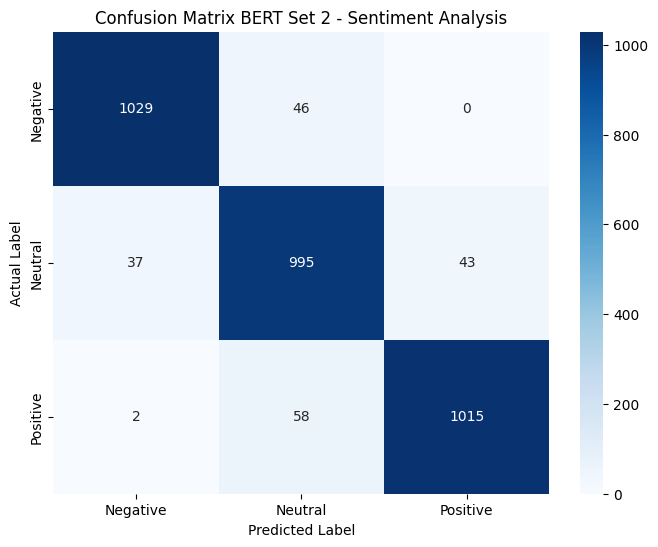

In [20]:
# Confusion Matrix Plot

labels = ['Negative', 'Neutral', 'Positive']
# Confusion matrix
cm = confusion_matrix(bert_test_labels, y_preds4)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.title('Confusion Matrix BERT Set 2 - Sentiment Analysis')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [25]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_session_bertBalanceddata_set2_0702.db'))

In [17]:
#
# BERT DEVELOPMENT - SET 3
#
import pandas as pd
import numpy as np
import torch
import os 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
import shap


# Check if GPU is available (Crucial for BERT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Split training set to train and evaluation set
X_bert_train_text, X_bert_eval_text, y_bert_train, y_bert_eval = train_test_split(X_train_text, y_train, test_size=0.20, random_state=42, stratify=y_train) 

# Tokenization (BERT-base-cased)
bert_train_texts=X_bert_train_text.astype(str).tolist()
bert_train_labels=y_bert_train.tolist()
bert_eval_texts = X_bert_eval_text.astype(str).tolist()
bert_eval_labels = y_bert_eval.tolist()
# Bert test set is the same SVM test set

bert_test_texts=X_test_text.astype(str).tolist()
bert_test_labels=y_test.tolist()

tokenizer3 = BertTokenizer.from_pretrained('bert-base-cased')

def tokenize_function(texts_list):
    return tokenizer3(
        texts_list,
        padding='max_length',     # Pad to max_length
        truncation=True,          # Truncate if longer
        max_length=160,           # As specified in thesis
        return_tensors="pt"       # Return PyTorch tensors
    )

# Tokenize data
train_encodings = tokenize_function(bert_train_texts)
eval_encodings = tokenize_function(bert_eval_texts)
test_encodings = tokenize_function(bert_test_texts)

# Create a Torch Dataset Class
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = ReviewDataset(train_encodings, bert_train_labels)
eval_dataset = ReviewDataset(eval_encodings, bert_eval_labels)
test_dataset = ReviewDataset(test_encodings, bert_test_labels)

# Iighted Cross-Entropy Loss Setup
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(bert_train_labels),
    y=bert_train_labels
)
# Convert to Tensor and move to GPU/CPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define a Custom Trainer to inject the Iighted Loss
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define the IiNone
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Model Initialization & Training
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-cased',
    num_labels=len(np.unique(bert_train_labels))
).to(device)
bert_results = checkpoint_dir + '/bert_dataBalancedset3_wc_results'
bert_logs = checkpoint_dir + '/bert_dataBalancedset3_wc_logs'

# Define checkpoint_path
bert_checkpoint_path = os.path.join(checkpoint_dir, 'bert_dataBalancedset3_wc_results')

# Define Hyperparameters (As specified in thesis)
training_args3 = TrainingArguments(
    output_dir=bert_results,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-5,
    weight_decay=0.01,
    logging_dir=bert_logs,
    logging_strategy="epoch",
    
    # Disable automatic eval so it doesn't conflict with our manual callback
    eval_strategy="no", 
    save_strategy="epoch",
    load_best_model_at_end=False # We will find the best model manually via Pandas
)

# Callback to calculate trainset metric
# Update Callback to Calculate BOTH Train and Eval
class TrainMetricsCallback(TrainerCallback):
    def __init__(self, trainer):
        self.trainer = trainer
    
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"\n--- Epoch {state.epoch} End ---")
        
        # Calculate & Log TRAINING Metrics
        print("1. Calculating TRAINING metrics...")
        self.trainer.evaluate(
            eval_dataset=self.trainer.train_dataset, 
            metric_key_prefix="train"
        )
        
        # Calculate & Log VALIDATION Metrics (Manually Forced)
        print("2. Calculating VALIDATION metrics...")
        self.trainer.evaluate(
            eval_dataset=self.trainer.eval_dataset, 
            metric_key_prefix="eval"
        )
        
        return control
        
        
# Initialize Metric for Evaluation
def compute_metrics(pred):
    from sklearn.metrics import accuracy_score, f1_score
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Initialize Trainer
trainer3 = WeightedLossTrainer(
    model=bert_model,
    args=training_args3,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

trainer3.add_callback(TrainMetricsCallback(trainer3))

last_checkpoint = None
if os.path.isdir(bert_checkpoint_path) and len(os.listdir(bert_checkpoint_path)) > 0:
    # If the folder has contents, try to find the last checkpoint
    from transformers.trainer_utils import get_last_checkpoint
    last_checkpoint = get_last_checkpoint(bert_checkpoint_path)

# START TRAINING
print(f"Starting BERT Fine-tuning... (Resuming? {last_checkpoint is not None})")

if last_checkpoint:
    trainer3.train(resume_from_checkpoint=last_checkpoint)
else:
    trainer3.train()


Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT Fine-tuning... (Resuming? True)


Step,Training Loss


In [18]:
# Get History
history = trainer3.state.log_history
df_log3 = pd.DataFrame(history)
df_log3 = df_log3.head(22)
# Separate Train and Eval logs
df_log3

,epoch,step,train_accuracy,train_f1,train_loss,train_runtime,train_samples_per_second,train_steps_per_second,eval_accuracy,eval_f1,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,total_flos
0,1.0,1290,0.959775,0.959698,0.139221,115.2864,8.949000e+01,11.190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1290,NaN,NaN,NaN,NaN,NaN,NaN,0.943411,0.943373,0.194514,28.9584,89.093,11.154,NaN
2,2.0,2580,0.978094,0.978092,0.072406,116.4838,8.857000e+01,11.075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,2580,NaN,NaN,NaN,NaN,NaN,NaN,0.953488,0.953526,0.180304,29.2144,88.313,11.056,NaN
4,3.0,3870,0.985364,0.985357,0.052599,117.1810,8.804300e+01,11.009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,3870,NaN,NaN,NaN,NaN,NaN,NaN,0.943411,0.943553,0.225265,29.3289,87.968,11.013,NaN
6,4.0,5160,0.991083,0.991067,0.039078,117.2755,8.797200e+01,11.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.0,5160,NaN,NaN,NaN,NaN,NaN,NaN,0.948450,0.948142,0.299186,29.3520,87.899,11.004,NaN
8,5.0,6450,0.993991,0.993984,0.024384,117.5775,8.774600e+01,10.971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,6450,NaN,NaN,NaN,NaN,NaN,NaN,0.951550,0.951434,0.300093,29.4565,87.587,10.965,NaN


In [19]:
# 1. Get History
history3 = trainer3.state.log_history
df_log3 = pd.DataFrame(history3)
df_log3 = df_log3.head(20)
# 2. Separate Train and Eval logs
# Filter rows that have 'train_loss' and 'eval_loss' respectively
train_logs3 = df_log3.dropna(subset=['train_loss']).reset_index(drop=True)
eval_logs3 = df_log3.dropna(subset=['eval_loss']).reset_index(drop=True)

# 3. Select only the columns we care about
train_logs3 = train_logs3[['epoch', 'train_loss', 'train_accuracy', 'train_f1']]
eval_logs3 = eval_logs3[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1']]

# 4. Merge them into one final table
final_df3 = pd.merge(train_logs3, eval_logs3, on='epoch')

#print(final_df)
# Save to CSV
final_df3.to_csv("bert_BalancedDataSet3_training_log.csv", index=False)
final_df3

,epoch,train_loss,train_accuracy,train_f1,eval_loss,eval_accuracy,eval_f1
0,1.0,0.139221,0.959775,0.959698,0.194514,0.943411,0.943373
1,2.0,0.072406,0.978094,0.978092,0.180304,0.953488,0.953526
2,3.0,0.052599,0.985364,0.985357,0.225265,0.943411,0.943553
3,4.0,0.039078,0.991083,0.991067,0.299186,0.948450,0.948142
4,5.0,0.024384,0.993991,0.993984,0.300093,0.951550,0.951434
5,6.0,0.020108,0.995347,0.995347,0.314502,0.951938,0.951970
6,7.0,0.018148,0.995638,0.995638,0.347574,0.951163,0.951123
7,8.0,0.015501,0.995929,0.995927,0.354967,0.952326,0.952261
8,9.0,0.014033,0.996026,0.996024,0.352771,0.953488,0.953509
9,10.0,0.013140,0.996123,0.996121,0.360222,0.952326,0.952261


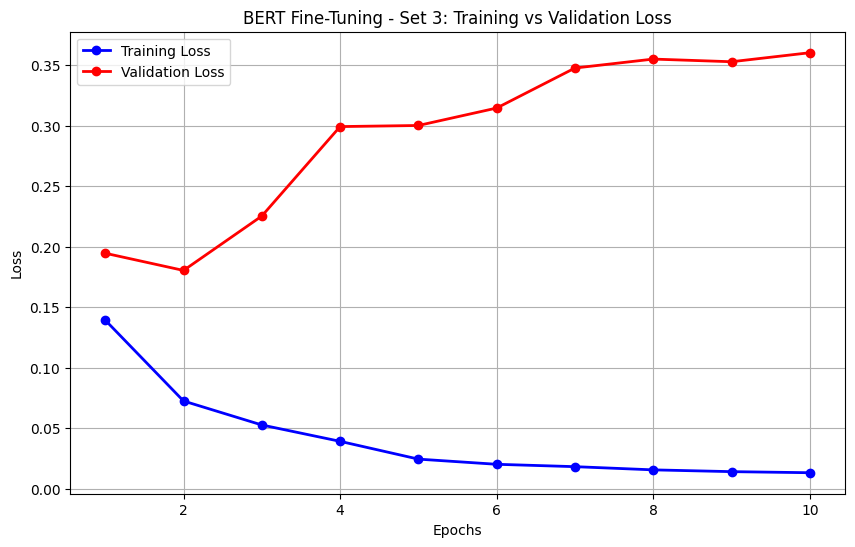

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# Plot Training and Validation Loss
# ==========================================

# Extract log history from the Trainer state
log_history3 = trainer3.state.log_history

# Convert to DataFrame for easier handling
df_log3 = pd.DataFrame(log_history3).head(20)

# Separate training and validation metrics
# Training logs contain 'loss', validation logs contain 'eval_loss'
train_log3 = df_log3[df_log3['train_loss'].notna()][['epoch', 'train_loss']]
eval_log3 = df_log3[df_log3['eval_loss'].notna()][['epoch', 'eval_loss']]

# Plotting
plt.figure(figsize=(10, 6))

# Plot Training Loss
plt.plot(train_log3['epoch'], train_log3['train_loss'], label='Training Loss', color='blue', marker='o', linewidth=2)

# Plot Validation Loss
plt.plot(eval_log3['epoch'], eval_log3['eval_loss'], label='Validation Loss', color='red', marker='o', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BERT Fine-Tuning - Set 3: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

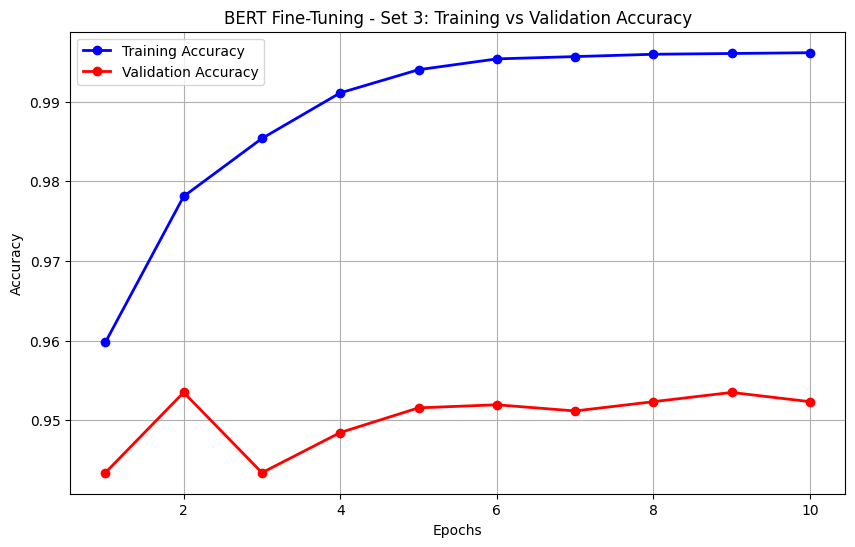

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# Plot Training and Validation Loss
# ==========================================

# Extract log history from the Trainer state
log_history3 = trainer3.state.log_history

# Convert to DataFrame for easier handling
df_log3 = pd.DataFrame(log_history3).head(20)

# Separate training and validation metrics
# Training logs contain 'loss', validation logs contain 'eval_loss'
train_acc_log3 = df_log3[df_log3['train_accuracy'].notna()][['epoch', 'train_accuracy']]
eval_acc_log3 = df_log3[df_log3['eval_accuracy'].notna()][['epoch', 'eval_accuracy']]

# Plotting
plt.figure(figsize=(10, 6))

# Plot Training Loss
plt.plot(train_acc_log3['epoch'], train_acc_log3['train_accuracy'], label='Training Accuracy', color='blue', marker='o', linewidth=2)

# Plot Validation Loss
plt.plot(eval_acc_log3['epoch'], eval_acc_log3['eval_accuracy'], label='Validation Accuracy', color='red', marker='o', linewidth=2)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BERT Fine-Tuning - Set 3: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
import pandas as pd
import shutil

# Best Nodel choice - Lowwest Validation Loss

history3 = trainer3.state.log_history
df_log = pd.DataFrame(history3)

# Filter for rows that actually have validation data
eval_log = df_log.dropna(subset=['eval_loss']).reset_index(drop=True)

# Find the row with the Lowest Validation Loss
best_row = eval_log.loc[eval_log['eval_loss'].idxmin()]
best_step = int(best_row['step'])
best_epoch = best_row['epoch']
best_loss = best_row['eval_loss']

print(f"\n Found Best Model at Epoch {best_epoch} (Step {best_step})")
print(f"   Best Eval Loss: {best_loss:.4f}")

# the path to that specific checkpoint
bert_results = checkpoint_dir + '/bert_dataBalancedset3_wc_results'
bert_logs = checkpoint_dir + '/bert_dataBalancedset3_wc_logs'

best_checkpoint_path = os.path.join(bert_results, f"checkpoint-{best_step}")

print(f"   Loading model from: {best_checkpoint_path}")

# Load that specific model
best_model = BertForSequenceClassification.from_pretrained(best_checkpoint_path)
best_model.to(device)

# Update the Trainer to use this best model
trainer3.model = best_model

# Print Key Configuration Parameters
config = best_model.config
print("\n" + "="*40)
print(f"BEST MODEL CONFIGURATION")
print("="*40)
print(f"• Model Type:          {config.model_type}")
print(f"• Number of Layers:    {config.num_hidden_layers}")
print(f"• Hidden Size:         {config.hidden_size}")
print(f"• Attention Heads:     {config.num_attention_heads}")
print(f"• Vocabulary Size:     {config.vocab_size}")
print(f"• Max Position Embed:  {config.max_position_embeddings}")
print(f"• Number of Labels:    {config.num_labels}")
print(f"• Hidden Dropout Prob: {config.hidden_dropout_prob}")

# Count Total & Trainable Parameters
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

print("\n" + "="*40)
print(f"PARAMETER COUNTS")
print("="*40)
print(f"• Total Parameters:     {total_params:,}")
print(f"• Trainable Parameters: {trainable_params:,}")

# Print Full Layer Structure
print("\n" + "="*40)        
print(f"MODEL ARCHITECTURE (LAYERS)")
print("="*40)
print(best_model)


 Found Best Model at Epoch 2.0 (Step 2580)
   Best Eval Loss: 0.1803
   Loading model from: Checkpoints/bert_dataBalancedset3_wc_results/checkpoint-2580

BEST MODEL CONFIGURATION
• Model Type:          bert
• Number of Layers:    12
• Hidden Size:         768
• Attention Heads:     12
• Vocabulary Size:     28996
• Max Position Embed:  512
• Number of Labels:    3
• Hidden Dropout Prob: 0.1

PARAMETER COUNTS
• Total Parameters:     108,312,579
• Trainable Parameters: 108,312,579

MODEL ARCHITECTURE (LAYERS)
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): Bert

In [23]:
from torchinfo import summary
import torch

# Define dummy input dimensions 
batch_size = 1
seq_len = 512
dummy_input = torch.zeros((batch_size, seq_len), dtype=torch.long)

# Generate the summary
model_stats = summary(
    best_model, 
    input_data=dummy_input,
    col_names=["num_params","output_size"],
    depth=3,
    device="cuda"
)

print(model_stats)

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Layer (type:depth-idx)                                       Param #                   Output Shape
BertForSequenceClassification                                --                        [1, 3]
├─BertModel: 1-1                                             --                        [1, 768]
│    └─BertEmbeddings: 2-1                                   --                        [1, 512, 768]
│    │    └─Embedding: 3-1                                   22,268,928                [1, 512, 768]
│    │    └─Embedding: 3-2                                   1,536                     [1, 512, 768]
│    │    └─Embedding: 3-3                                   393,216                   [1, 512, 768]
│    │    └─LayerNorm: 3-4                                   1,536                     [1, 512, 768]
│    │    └─Dropout: 3-5                                     --                        [1, 512, 768]
│    └─BertEncoder: 2-2                                      --                        [1, 512, 768]
│  

In [24]:
# Classification Report

# BERT SET 3 - Evaluation Train Set
print("--- Bert Set 3 Evaluation on  Train Set...")
preds_train_output5 = trainer3.predict(train_dataset)
y_preds5 = preds_train_output5.predictions.argmax(-1)

print(classification_report(bert_train_labels, y_preds5, digits=4))

# BERT SET 3 - Evaluation Test Set
print("--- Bert Set 3 Evaluation on Full Test Set...")
preds_output6 = trainer3.predict(test_dataset)
y_preds6 = preds_output6.predictions.argmax(-1)
print(classification_report(bert_test_labels, y_preds6, digits=4))


--- Bert Set 3 Evaluation on  Train Set...


              precision    recall  f1-score   support

           0     0.9827    0.9910    0.9868      3439
           1     0.9658    0.9689    0.9673      3439
           2     0.9859    0.9744    0.9801      3439

    accuracy                         0.9781     10317
   macro avg     0.9781    0.9781    0.9781     10317
weighted avg     0.9781    0.9781    0.9781     10317

--- Bert Set 3 Evaluation on Full Test Set...


              precision    recall  f1-score   support

           0     0.9633    0.9758    0.9695      1075
           1     0.9240    0.9274    0.9257      1075
           2     0.9631    0.9470    0.9550      1075

    accuracy                         0.9501      3225
   macro avg     0.9501    0.9501    0.9501      3225
weighted avg     0.9501    0.9501    0.9501      3225



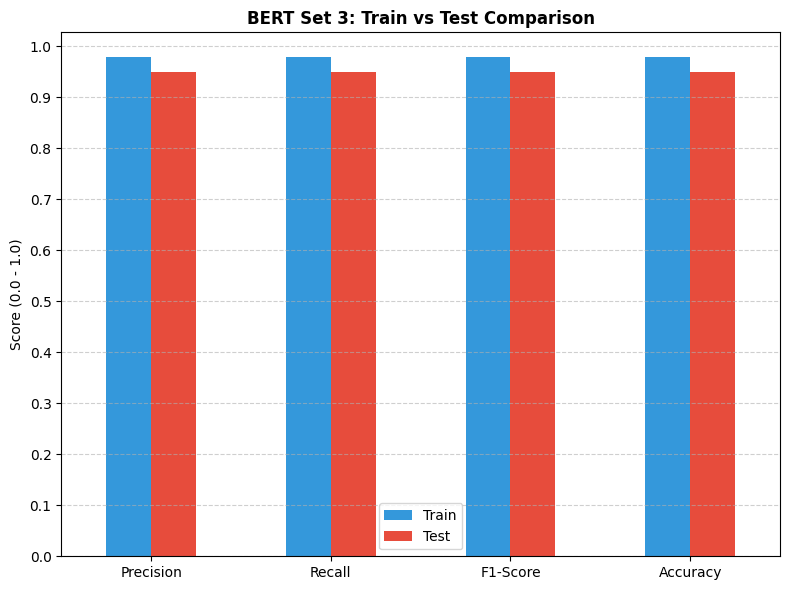

In [26]:
# Plot classification report

def get_metrics_comparison(y_true, y_pred, name):
    report = classification_report(y_true, y_pred, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    
    # Extract Macro Averages for a balanced comparison
    metrics = {
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-Score': report['macro avg']['f1-score'],
        'Accuracy': acc
    }
    return pd.Series(metrics, name=name)

# --- Prepare Data for Set 1 ---
s_train = get_metrics_comparison(bert_train_labels, y_preds5, 'Train')
s_test = get_metrics_comparison(bert_test_labels, y_preds6, 'Test')
df_bert = pd.concat([s_train, s_test], axis=1)


# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(8, 6))

df_bert.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'], rot=0)
ax1.set_title('BERT Set 3: Train vs Test Comparison', fontweight='bold')
ax1.set_ylabel('Score (0.0 - 1.0)')
ax1.set_yticks(np.arange(0,1.1,0.1))
ax1.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

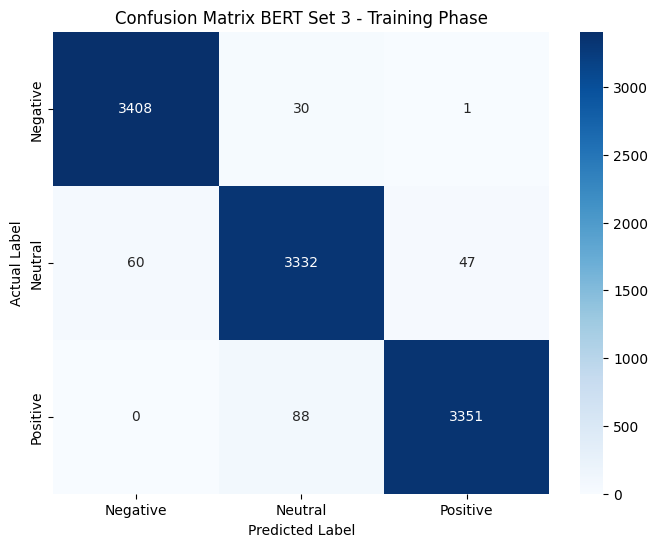

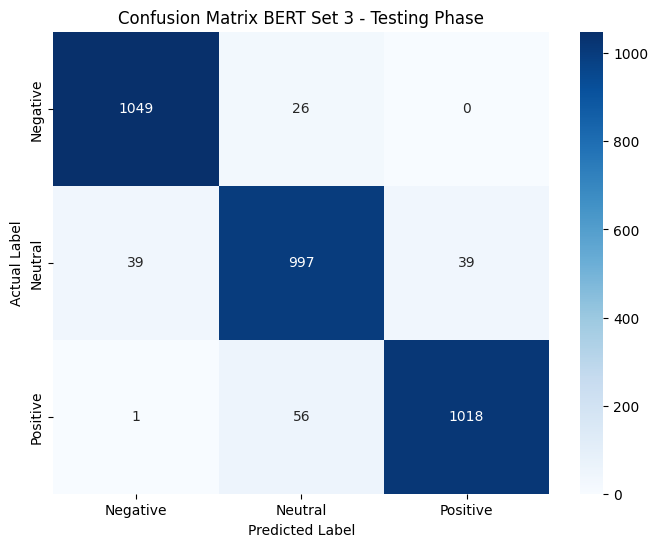

In [27]:
# Confusion Matrix Plot

labels = ['Negative', 'Neutral', 'Positive']
# Confusion matrix
cm3 = confusion_matrix(bert_train_labels, y_preds5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm3, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.title('Confusion Matrix BERT Set 3 - Training Phase')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Confusion Matrix Plot

labels = ['Negative', 'Neutral', 'Positive']
# Confusion matrix
cm4 = confusion_matrix(bert_test_labels, y_preds6)

plt.figure(figsize=(8, 6))
sns.heatmap(cm4, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.title('Confusion Matrix BERT Set 3 - Testing Phase')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [12]:
# MANUAL BEST MODEL CHOICE

# Check if GPU is available (Crucial for BERT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set 3 , epoch 2 (step 2580) is the best
bert_results = checkpoint_dir + '/bert_dataBalancedset3_wc_results'
best_bert_step = 2580
best_checkpoint_path = os.path.join(bert_results, f"checkpoint-{best_bert_step}")

print(f"   Loading model from: {best_checkpoint_path}")

# Load that specific Model
best_bert_model = BertForSequenceClassification.from_pretrained(best_checkpoint_path)
best_bert_model.to(device)

# Update the Trainer to use this best model
trainer3.model = best_bert_model

# Print Key Configuration Parameters
config = best_bert_model.config
print("\n" + "="*40)
print(f"BEST MODEL CONFIGURATION")
print("="*40)
print(f"• Model Type:          {config.model_type}")
print(f"• Number of Layers:    {config.num_hidden_layers}")
print(f"• Hidden Size:         {config.hidden_size}")
print(f"• Attention Heads:     {config.num_attention_heads}")
print(f"• Vocabulary Size:     {config.vocab_size}")
print(f"• Max Position Embed:  {config.max_position_embeddings}")
print(f"• Number of Labels:    {config.num_labels}")
print(f"• Hidden Dropout Prob: {config.hidden_dropout_prob}")

# Count Total & Trainable Parameters
total_params = sum(p.numel() for p in best_bert_model.parameters())
trainable_params = sum(p.numel() for p in best_bert_model.parameters() if p.requires_grad)

print("\n" + "="*40)
print(f"PARAMETER COUNTS")
print("="*40)
print(f"• Total Parameters:     {total_params:,}")
print(f"• Trainable Parameters: {trainable_params:,}")

# Print Full Layer Structure
# 
print("\n" + "="*40)
print(f"MODEL ARCHITECTURE (LAYERS)")
print("="*40)
print(best_bert_model)

Using device: cuda
   Loading model from: Checkpoints/bert_dataBalancedset3_wc_results/checkpoint-2580

BEST MODEL CONFIGURATION
• Model Type:          bert
• Number of Layers:    12
• Hidden Size:         768
• Attention Heads:     12
• Vocabulary Size:     28996
• Max Position Embed:  512
• Number of Labels:    3
• Hidden Dropout Prob: 0.1

PARAMETER COUNTS
• Total Parameters:     108,312,579
• Trainable Parameters: 108,312,579

MODEL ARCHITECTURE (LAYERS)
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttentio

In [16]:
from transformers import pipeline

# Create a pipeline with my current best  model
mypipeline = pipeline("text-classification", model=best_bert_model, tokenizer=tokenizer3, top_k=None)

# Test it on the specific sentence
text = "not good very thin sheet of metal use build quality be not good"
print(mypipeline(text))


Device set to use cuda:0


[[{'label': 'LABEL_0', 'score': 0.99201899766922}, {'label': 'LABEL_1', 'score': 0.0076940106227993965}, {'label': 'LABEL_2', 'score': 0.00028700882103294134}]]


In [16]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_session_bertBalanceddatase3.db'))

In [17]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification, pipeline
from transformers.trainer_utils import get_last_checkpoint

# Create the Pipeline
pred_pipeline = pipeline(
    "text-classification",
    model=best_bert_model,
    tokenizer=tokenizer3,
    #device=0 if torch.cuda.is_available() else -1,
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    top_k=None # Return scores for all classes
)

# Full test set for SHAP explainer 
subset_texts = X_test_text.astype(str).tolist()
#subset_texts = test_texts[:subset_size]

# Initialize Explainer
bert_explainer = shap.Explainer(pred_pipeline)

# Calculate SHAP Values
print(f"Calculating SHAP values for full test samples...")
# full samples for background
bert_shap_values = bert_explainer(subset_texts)

print("Calculation complete.")


Device set to use cuda


Calculating SHAP values for full test samples...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|           | 33/3225 [00:25<38:03,  1.40it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  96%|████████▋| 3094/3225 [46:11<02:04,  1.05it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3226it [48:01,  1.12it/s]                         


Calculation complete.


In [18]:
import string
id2label={0: "negative", 1: "neutral", 2: "positive"}
# 6. Function to aggregate SHAP values by actual word tokens
def get_global_word_importance(shap_values, target_class):
    # Find the index for the target class
    class_idx = list(id2label.values()).index(target_class)
    
    word_scores = {}
    word_counts = {}
    
    # Iterate through every sentence
    for i in range(len(bert_shap_values)):
        # Get tokens (data) and scores (values) for this sentence
        tokens = bert_shap_values[i].data
        scores = bert_shap_values[i].values[:, class_idx] # Only get scores for the target class
        
        for token, score in zip(tokens, scores):
            # Clean token (remove BERT's '##' subword prefix)
            clean_token = token.replace("##", "").lower()
            
            if (clean_token != "" and 
                clean_token not in ["[cls]", "[sep]", "[pad]", "[unk]"] and 
                clean_token not in string.punctuation):
                
                if clean_token not in word_scores:
                    word_scores[clean_token] = 0.0
                    word_counts[clean_token] = 0
                
                word_scores[clean_token] += score
                word_counts[clean_token] += 1
    # Calculate average impact per word
    avg_scores = {k: v / word_counts[k] for k, v in word_scores.items()}
    
    # Convert to DataFrame
    df = pd.DataFrame(list(avg_scores.items()), columns=['Word', 'SHAP Value'])
    return df

df_class = get_global_word_importance(bert_shap_values,"neutral")

# Sort by absolute importance to find the strongest drivers
df_class['Abs_Value'] = df_class['SHAP Value'].abs()
top_words = df_class.sort_values(by='Abs_Value', ascending=False).head(20)

print(top_words)

                Word  SHAP Value  Abs_Value
1837      appreciate   -0.611055   0.611055
2409         foolish   -0.586369   0.586369
345           superb   -0.485589   0.485589
2064   extraordinary   -0.465629   0.465629
421        brilliant   -0.463179   0.463179
1413     outstanding   -0.461734   0.461734
573            super   -0.447727   0.447727
144          awesome   -0.442422   0.442422
106        excellent   -0.437855   0.437855
0            perfect   -0.429886   0.429886
403        worthless   -0.416590   0.416590
335         terrible   -0.413660   0.413660
252         horrible   -0.407350   0.407350
2414          gifted   -0.391334   0.391334
182            great   -0.387151   0.387151
131             poor   -0.384359   0.384359
924          amazing   -0.379353   0.379353
2293          lovely   -0.375861   0.375861
824      inexpensive    0.367234   0.367234
153        wonderful   -0.367151   0.367151


/tmp/ipykernel_35052/3372168962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, y='Word', x='SHAP Value', palette='coolwarm')


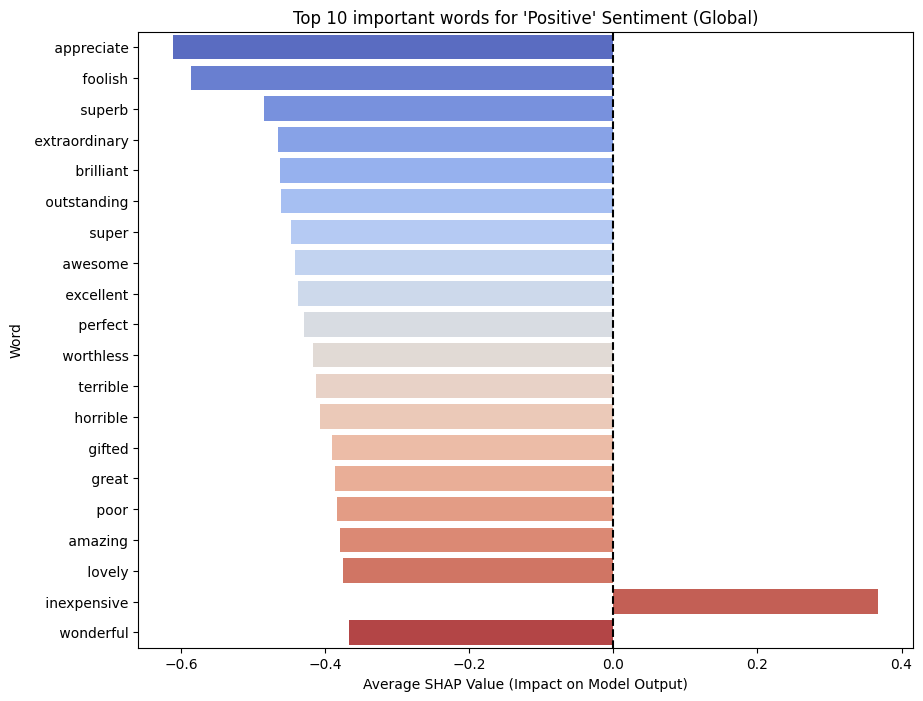

In [19]:
# Plot the Top 10 Global Features
plt.figure(figsize=(10, 8))
sns.barplot(data=top_words, y='Word', x='SHAP Value', palette='coolwarm')
plt.title("Top 10 important words for 'Positive' Sentiment (Global)")
plt.xlabel("Average SHAP Value (Impact on Model Output)")
plt.axvline(0, color='black', linestyle='--')
plt.show()

Class  negative has top 10 words: 
               Word  SHAP Value  Abs_Value
2409       foolish    0.606974   0.606974
335       terrible    0.452132   0.452132
403      worthless    0.447657   0.447657
252       horrible    0.432666   0.432666
131           poor    0.409891   0.409891
1416         worst    0.390697   0.390697
101        useless    0.390130   0.390130
824    inexpensive   -0.356756   0.356756
2059        excess    0.342082   0.342082
2990    extinction    0.318973   0.318973


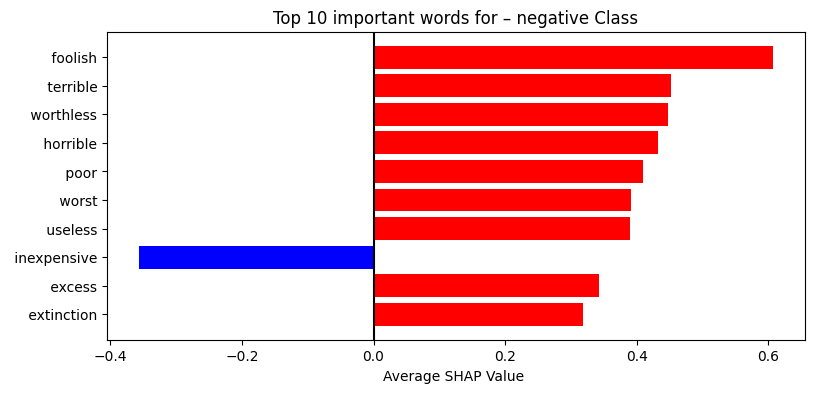

Class  neutral has top 10 words: 
                 Word  SHAP Value  Abs_Value
1837      appreciate   -0.611055   0.611055
2409         foolish   -0.586369   0.586369
345           superb   -0.485589   0.485589
2064   extraordinary   -0.465629   0.465629
421        brilliant   -0.463179   0.463179
1413     outstanding   -0.461734   0.461734
573            super   -0.447727   0.447727
144          awesome   -0.442422   0.442422
106        excellent   -0.437855   0.437855
0            perfect   -0.429886   0.429886


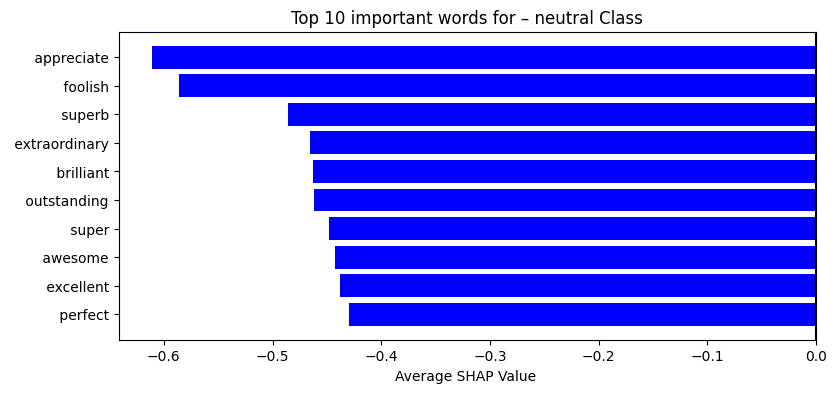

Class  positive has top 10 words: 
                 Word  SHAP Value  Abs_Value
1837      appreciate    0.651354   0.651354
345           superb    0.519212   0.519212
421        brilliant    0.499550   0.499550
2064   extraordinary    0.487407   0.487407
573            super    0.479263   0.479263
1413     outstanding    0.473724   0.473724
144          awesome    0.466616   0.466616
106        excellent    0.464147   0.464147
0            perfect    0.442833   0.442833
153        wonderful    0.411040   0.411040


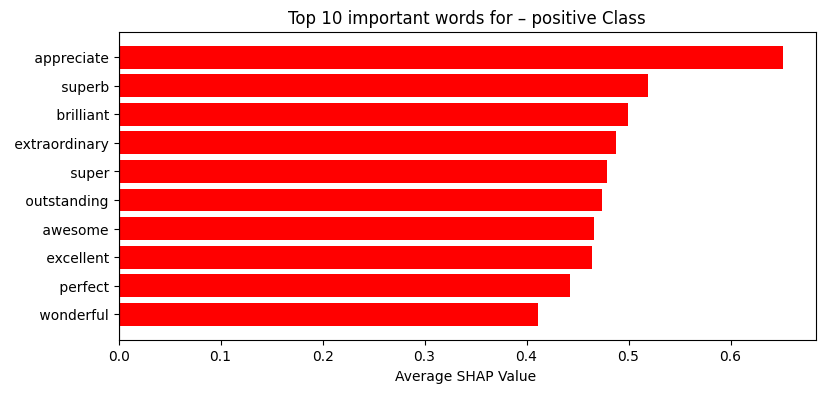

In [20]:
class_names = ['negative', 'neutral', 'positive']
for i in class_names:
    df_class = get_global_word_importance(bert_shap_values, target_class=i)

# Sort by absolute importance to find the strongest drivers
    df_class['Abs_Value'] = df_class['SHAP Value'].abs()
    top_words = df_class.sort_values(by='Abs_Value', ascending=False).head(10)

    print("Class ", i, "has top 10 words: \n", top_words)

    
    plt.figure(figsize=(9, 4))
    colors = ["red" if v > 0 else "blue" for v in top_words['SHAP Value']]

    plt.barh(top_words['Word'], top_words['SHAP Value'], color=colors)
    plt.axvline(0, color="black")  # zero line = direction change
    plt.xlabel("Average SHAP Value ")
    plt.title(f"Top 10 important words for – {i} Class" )
    plt.gca().invert_yaxis()
    plt.show()

Raw review:
really nice very nice product fast speed slim product run smoothly thank flipkart for within 24 hrs delivery

Predicted class: positive

Actual class: positive

Top contributing tokens:
         word  shap_value  abs_shap
12      thank    0.367561  0.367561
4        nice    0.364901  0.364901
1      really   -0.226058  0.226058
2        nice    0.117712  0.117712
3        very    0.102407  0.102407
9     product    0.077298  0.077298
7       speed    0.037500  0.037500
11   smoothly    0.033761  0.033761
10        run   -0.028796  0.028796
6        fast    0.028063  0.028063

Top contributing words:
        word  shap_value  abs_shap
0      thank    0.367561  0.367561
1       nice    0.364901  0.364901
2     really   -0.226058  0.226058
3       nice    0.117712  0.117712
4       very    0.102407  0.102407
5    product    0.077298  0.077298
6      speed    0.037500  0.037500
7   smoothly    0.033761  0.033761
8        run   -0.028796  0.028796
9       fast    0.028063  0.028

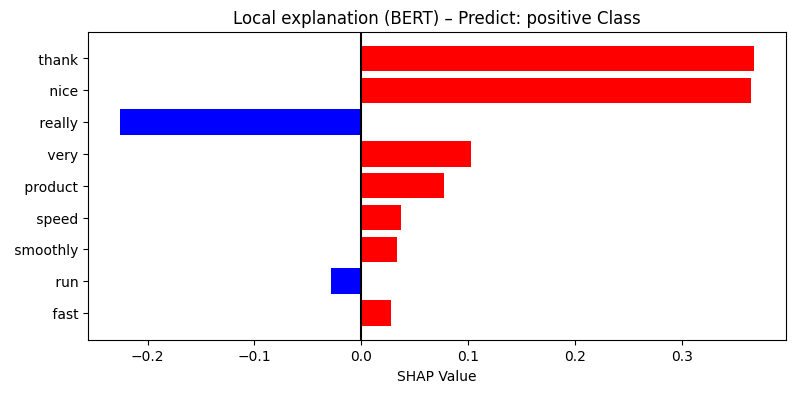

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Instance to explain 170, 197, 219
i = 219
text_to_explain = subset_texts[i]

# SHAP values
bert_shap_values2 = bert_explainer([text_to_explain])

# Predict class (same logic you used)
scores = bert_shap_values2.values[0].sum(axis=0) + bert_shap_values2.base_values[0]
class_id = scores.argmax()
predicted_label = id2label[class_id]

print("Raw review:")
print(text_to_explain)
print("\nPredicted class:", predicted_label)
print("\nActual class:", predicted_label)

# Extract SHAP values for predicted class
token_shap = bert_shap_values2[0, :, class_id].values
tokens = bert_shap_values2[0, :, class_id].data

df_local = pd.DataFrame({
    "word": tokens,
    "shap_value": token_shap
})

# Remove special tokens
df_local = df_local[~df_local["word"].isin(["[CLS]", "[SEP]", "[PAD]"])]

# Add absolute SHAP
df_local["abs_shap"] = df_local["shap_value"].abs()

# Sort like SVM
df_local = df_local.sort_values("abs_shap", ascending=False)

print("\nTop contributing tokens:")
print(df_local.head(10))

def merge_wordpieces(df):
    words = []
    shap_vals = []

    current_word = ""
    current_shap = 0.0

    for word, shap in zip(df["word"], df["shap_value"]):
        if word.startswith("##"):
            current_word += word[2:]
            current_shap += shap
        else:
            if current_word:
                words.append(current_word)
                shap_vals.append(current_shap)
            current_word = word
            current_shap = shap

    # last word
    if current_word:
        words.append(current_word)
        shap_vals.append(current_shap)

    out = pd.DataFrame({
        "word": words,
        "shap_value": shap_vals
    })
    out["abs_shap"] = out["shap_value"].abs()
    return out.sort_values("abs_shap", ascending=False)

df_words = merge_wordpieces(df_local)

print("\nTop contributing words:")
print(df_words.head(10))
top_k = 10
df_plot = df_words.head(top_k)

plt.figure(figsize=(9, 4))
colors = ["red" if v > 0 else "blue" for v in df_plot["shap_value"]]

plt.barh(df_plot["word"], df_plot["shap_value"], color=colors)
plt.axvline(0, color="black")
plt.xlabel("SHAP Value")
plt.title(f"Local explanation (BERT) – Predict: {predicted_label} Class")
plt.gca().invert_yaxis()
plt.show()


In [23]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_session_bertBalanceddatase3_0702.db'))



In [22]:
import pandas as pd
import numpy as np
import torch
import shap

# Configuration
id2label = {0: "negative", 1: "neutral", 2: "positive"}
results_all = {}
sample_sizes = [600]  # List of sample sizes to run

# Function  Merge Wordpieces 
def merge_wordpieces(tokens, shap_values):
    """
    Merges BERT wordpieces (e.g., "play", "##ing") into whole words
    and sums their SHAP values.
    """
    words = []
    shap_vals = []

    current_word = ""
    current_shap = 0.0

    for word, shap_val in zip(tokens, shap_values):
        # BERT tokens starting with "##" are continuations
        if word.startswith("##"):
            current_word += word[2:]
            current_shap += shap_val
        else:
            # If we have a previous word accumulated, store it
            if current_word:
                words.append(current_word)
                shap_vals.append(current_shap)
            # Start new word
            current_word = word
            current_shap = shap_val

    # Append the last word
    if current_word:
        words.append(current_word)
        shap_vals.append(current_shap)

    return np.array(words), np.array(shap_vals)

# Extract BERT Features for One Row
def extract_top10_shap_bert_one_row(bert_shap_values, sample_idx, class_id):
    """
    Extracts top 10 words for BERT, applying wordpiece merging.
    """
    # Slice the shap object for this specific row
    sv = bert_shap_values[sample_idx]
    
    # Extract raw tokens and values for the predicted class
    raw_tokens = sv.data
    raw_shap = sv.values[:, class_id]

    # Merge Wordpieces 
    words, shap_scores = merge_wordpieces(raw_tokens, raw_shap)

    # Filter special tokens
    valid_mask = [w not in ["[CLS]", "[SEP]", "[PAD]"] for w in words]
    words = words[valid_mask]
    shap_scores = shap_scores[valid_mask]

    if len(words) == 0:
        return []

    # Sort by Absolute SHAP
    abs_shap = np.abs(shap_scores)
    top_k = min(10, len(abs_shap))
    # Get indices of top k absolute values
    top_idx = np.argsort(abs_shap)[-top_k:][::-1]

    # Return list of tuples (word, value)
    return [
        (words[j], shap_scores[j])
        for j in top_idx
    ]

# 
#Extract SVM Features for One Row
def extract_top10_shap_svm_one_row(svm_shap_values, X_tfidf, sample_idx, class_id, svm_feature_names):
    # Get SHAP values for this instance & class
    shap_inst = svm_shap_values[sample_idx][:, class_id]

    # Get TF-IDF vector for this row
    x_inst = X_tfidf[sample_idx].toarray()[0]

    # Only consider words actually present in the text (nonzero tfidf)
    nonzero_idx = x_inst.nonzero()[0]

    if len(nonzero_idx) == 0:
        return []

    # Absolute SHAP for present words
    abs_shap = np.abs(shap_inst[nonzero_idx])

    # Top 10 indices
    top_k = min(10, len(abs_shap))
    top_idx_local = np.argsort(abs_shap)[-top_k:][::-1]
    
    # Map back to original feature indices
    original_indices = nonzero_idx[top_idx_local]

    return [
        (svm_feature_names[j], shap_inst[j])
        for j in original_indices
    ]

# Main Execution Loop

X_test_balanced = X_test_text
y_test_balanced = y_test

# SVM: TF-IDF + Predict + SHAP
X_test_tfidf_balanced = tfidf_vectorizer.transform(X_test_balanced)
y_pred_svm = best_model_svm.predict(X_test_tfidf_balanced)
    
svm_shap_values = svm_explainer.shap_values(X_test_tfidf_balanced)
svm_feature_names = tfidf_vectorizer.get_feature_names_out()

# BERT: Predict + SHAP
# Predict classes
test_texts = X_test_balanced.astype(str).tolist()
test_labels = y_test_balanced.tolist()
    
test_encodings = tokenize_function(test_texts)
test_dataset = ReviewDataset(test_encodings, test_labels)
    
preds_output = trainer3.predict(test_dataset)
y_pred_bert = preds_output.predictions.argmax(-1)

# Calculate BERT SHAP 
bert_shap_values = bert_explainer(list(X_test_balanced))

#Iterate Rows and creaete result
rows = []
    
for i in range(len(y_test_balanced)):
        
        # SVM Logic
        svm_class_id = y_pred_svm[i]
        top10_svm = extract_top10_shap_svm_one_row(
            svm_shap_values,
            X_test_tfidf_balanced,
            i,
            svm_class_id,
            svm_feature_names
        )

        # BERT Logic
        bert_class_id = y_pred_bert[i]
        top10_bert = extract_top10_shap_bert_one_row(
            bert_shap_values,
            i,
            bert_class_id
        )

        # Build Row Dict
        row = {
            "raw_index": X_test_text.index[i],
            "true_sentiment": id2label[y_test_balanced.iloc[i]],
            "encoded_sentiment": y_test_balanced.iloc[i],
            "Feedback_Clean": X_test_balanced.iloc[i], # Fixed typo X_testM -> X_test
            
            # SVM Columns
            "svm_sentiment": id2label[svm_class_id],
            "svm_shap_top_features": ", ".join([word for word, _ in top10_svm]),
            
            # BERT Columns
            "bert_sentiment": id2label[bert_class_id],
            "bert_shap_top_tokens": ", ".join([word for word, _ in top10_bert])
        }

        rows.append(row)

# 5. Save to File
result_df = pd.DataFrame(rows)
file_name = f"Balanceddata_svm_bert_evaluation_full_samples_0702.csv"
result_df.to_csv(file_name, index=False, encoding="utf-8-sig")
    
#results_all[n_samples] = result_df
    
print(f"Finished. Saved {len(result_df)} rows to: {file_name}")
print(result_df.head(5))

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|           | 33/3225 [00:25<36:17,  1.47it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|           | 36/3225 [00:30<59:23,  1.12s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  96%|████████▋| 3094/3225 [46:45<02:10,  1.00it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3226it [48:41,  1.10it/s]                         


Finished. Saved 3225 rows to: Balanceddata_svm_bert_evaluation_full_samples_0702.csv
   raw_index true_sentiment  encoded_sentiment  \
0      11110       positive                  2   
1       6752        neutral                  1   
2      10378        neutral                  1   
3        525       negative                  0   
4       8542        neutral                  1   

                                      Feedback_Clean svm_sentiment  \
0              perfect product very nice memory card      positive   
1  good 5 star for the product delivery be on tim...      negative   
2                           good too hot while grind       neutral   
3          unsatisfactory very bad productnot 30vats      negative   
4  fair not very sturdy and durable not for kid a...       neutral   

                               svm_shap_top_features bert_sentiment  \
0  perfect, perfect product, very nice, product v...       positive   
1  for, they, good, from, do not, when, after, ti..

In [23]:
result_df

,raw_index,true_sentiment,encoded_sentiment,Feedback_Clean,svm_sentiment,svm_shap_top_features,bert_sentiment,bert_shap_top_tokens
0,11110,positive,2,perfect product very nice memory card,positive,"perfect, perfect product, very nice, product v...",positive,"perfect, nice, very, memory, card, product"
1,6752,neutral,1,good 5 star for the product delivery be on tim...,negative,"for, they, good, from, do not, when, after, ti...",neutral,"good, forget, time, but, product, delive..."
2,10378,neutral,1,good too hot while grind,neutral,"good too, grind, while grind, while, hot while...",neutral,"good, grin, d, while, hot, too"
3,525,negative,0,unsatisfactory very bad productnot 30vats,negative,"unsatisfactory, bad, very bad, unsatisfactory ...",negative,"bad, un, sat, very, is, product, not, fa, ..."
4,8542,neutral,1,fair not very sturdy and durable not for kid a...,neutral,"fair, not for, not very, for kid, above, and, ...",neutral,"fair, not, sturdy, and, year, for, kid,..."
...,...,...,...,...,...,...,...,...
3220,5698,neutral,1,wonderful not bad not so good,neutral,"not bad, wonderful, wonderful not, bad, not so...",neutral,"wonderful, good, not, bad, not, so"
3221,1761,negative,0,do not meet expectation bad,negative,"bad, meet expectation, not, not meet, do not, ...",negative,"bad, not, meet, expectation, do"
3222,1975,negative,0,worthless no use its not work I request all of...,negative,"worthless, not, no, request, do not, no use, a...",negative,"worthless, not, no, do, buy, this, of, ..."
3223,1680,negative,0,bad quality quality not acceptable,negative,"bad, not acceptable, not, acceptable, quality ...",negative,"not, acceptable, bad, quality, quality"


In [26]:
import dill

# Save session
dill.dump_session(os.path.join(checkpoint_dir, 'notebook_session_bert_Balanceddata_complete_0702.db'))

In [3]:
import os
import openai
import json
#os.chdir("/content/drive/MyDrive/Upgrad/01. Data Science/LJMU/XAI Thesis/Final-ProductReviewLLMs/Datasets")
openai.api_key=open("./OPENAI_API_KEY.txt", "r").read().strip()
os.environ['OPENAI_API_KEY'] = openai.api_key

In [4]:
# LLM Configuration & Parameters
LLM_PARAMS = {
    "temperature": 0.0,
    "top_p": 1.0,
    "frequency_penalty": 0.0,
    "presence_penalty": 0.0,
    "seed": 11
}

# --- OLLAMA SERVER CONFIGURATION ---
OLLAMA_SERVER_URL = "http://10.1.1.237:11434/v1" 
OLLAMA_MODEL_NAME = "mistral"  

# Define Prompts
PROMPTS = {
    "ZS": """You are a helpful assistant that analyzes customer product reviews to determine sentiment.
Review: "{review_text}"
Provide the sentiment of this review as one of these options only: positive, negative, neutral.
Answer in this exact format with additional explanations for your choice of sentiment:
"ZS_Sentiment: <sentiment>. Reason: <reason>""",

    "COT": """You are a thoughtful assistant that analyzes product reviews step-by-step.
Review: "{review_text}"
First, identify key aspects or features mentioned in the review. The key aspects or features should be nouns such as screen, batery, etc
Second, determine the sentiment expressed toward each aspect (positive, negative, neutral).
Third, based on these, provide the overall sentiment of the review.
Finally, provide the reason for the overall sentiment’s result.
Answer in this structure using JSON format (Keep keys in English):
{{
"aspects": [
{{"aspect": "<Aspect 1>", "sentiment": "<sentiment1>"}},
{{"aspect": "<Aspect 2>", "sentiment": "<sentiment2>"}}
],
"overall_sentiment": "<sentiment>",
"reason": "<reason>"
}}"""
}

# Client Initialization

# Client 1: GPT-4 (Real OpenAI)
client_gpt = OpenAI(api_key=openai.api_key) 

# Client 2: Mistral (Ollama on Remote Server)
client_ollama = OpenAI(
    base_url=OLLAMA_SERVER_URL.rsplit('/api/', 1)[0],
    api_key="ollama"  # API key is required but ignored by Ollama
)

# Generation Functions

def generate_llm_response(client, model_name, review, prompt_type):
    """
    Function to call either GPT or Ollama since they share the same API structure.
    """
    user_content = PROMPTS[prompt_type].format(review_text=review)

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are a precise sentiment analysis engine."},
                {"role": "user", "content": user_content}
            ],
            temperature=LLM_PARAMS['temperature'],
            top_p=LLM_PARAMS['top_p'],
            seed=LLM_PARAMS['seed']
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {str(e)}"


In [5]:
# Reload data
svm_bert_output=pd.read_csv("Balanceddata_svm_bert_evaluation_full_samples_0702.csv")
#print(testdata_df.head())
llm_subset_df = svm_bert_output[['raw_index','true_sentiment','encoded_sentiment','Feedback_Clean']]
remain_svm_bert_df = svm_bert_output[['svm_sentiment','svm_shap_top_features','bert_sentiment','bert_shap_top_tokens']]
print(f"Processing {len(llm_subset_df)} reviews using GPT-4 and Remote Ollama...")
print(llm_subset_df.head())
llm_subset_df

Processing 3225 reviews using GPT-4 and Remote Ollama...
   raw_index true_sentiment  encoded_sentiment  \
0      11110       positive                  2   
1       6752        neutral                  1   
2      10378        neutral                  1   
3        525       negative                  0   
4       8542        neutral                  1   

                                      Feedback_Clean  
0              perfect product very nice memory card  
1  good 5 star for the product delivery be on tim...  
2                           good too hot while grind  
3          unsatisfactory very bad productnot 30vats  
4  fair not very sturdy and durable not for kid a...  


,raw_index,true_sentiment,encoded_sentiment,Feedback_Clean
0,11110,positive,2,perfect product very nice memory card
1,6752,neutral,1,good 5 star for the product delivery be on tim...
2,10378,neutral,1,good too hot while grind
3,525,negative,0,unsatisfactory very bad productnot 30vats
4,8542,neutral,1,fair not very sturdy and durable not for kid a...
...,...,...,...,...
3220,5698,neutral,1,wonderful not bad not so good
3221,1761,negative,0,do not meet expectation bad
3222,1975,negative,0,worthless no use its not work I request all of...
3223,1680,negative,0,bad quality quality not acceptable


In [46]:
# Execution Loop
results_data = []
output_file = "llm_results_ollama_tmp.csv"

for index, row in tqdm(llm_subset_df.iterrows(), total=len(llm_subset_df)):
    raw_index = row['raw_index']
    true_sentiment = row['true_sentiment']
    encoded_sentiment = row['encoded_sentiment']
    review_text = row['Feedback_Clean']    

    # --- GPT-4 Inference ---
    gpt_zs = generate_llm_response(client_gpt, "gpt-4", review_text, "ZS")
    gpt_cot = generate_llm_response(client_gpt, "gpt-4", review_text, "COT")

    # --- Mistral Inference (via Ollama Server) ---
    mistral_zs = generate_llm_response(client_ollama, OLLAMA_MODEL_NAME, review_text, "ZS")
    mistral_cot = generate_llm_response(client_ollama, OLLAMA_MODEL_NAME, review_text, "COT")

    # Store result
    results_data.append({
        "original_index": raw_index,
        "True_Label": true_sentiment,
        "Encoded_Label": encoded_sentiment,
        "Review": review_text,
        "GPT4_ZS_Output": gpt_zs,
        "GPT4_COT_Output": gpt_cot,
        "Mistral_ZS_Output": mistral_zs,
        "Mistral_COT_Output": mistral_cot
    })

    # Incremental Save
    if len(results_data) % 10 == 0: 
        pd.DataFrame(results_data).to_csv(output_file, index=False)

# Final Save
llm_df = pd.DataFrame(results_data)
#llm_df = pd.concat([inpdata_df, new_df], axis=1) 
llm_df.to_csv("Balanced_LLM_Experiment_Results_full_samples_0702.csv", index=False)
print("Completed! Results saved. \n", llm_df.head())
balanced_result_df = pd.concat([llm_df, remain_svm_bert_df], axis=1)
balanced_result_df.to_csv("Balanced_All_Experiment_Results_full_samples_0702.csv", index=False)
print("Completed! Results All saved. \n", balanced_result_df.head())

100%|█████████████████████████████████████| 3225/3225 [6:36:41<00:00,  7.38s/it]

Completed! Results saved. 
    original_index True_Label  Encoded_Label  \
0           11110   positive              2   
1            6752    neutral              1   
2           10378    neutral              1   
3             525   negative              0   
4            8542    neutral              1   

                                              Review  \
0              perfect product very nice memory card   
1  good 5 star for the product delivery be on tim...   
2                           good too hot while grind   
3          unsatisfactory very bad productnot 30vats   
4  fair not very sturdy and durable not for kid a...   

                                      GPT4_ZS_Output  \
0  ZS_Sentiment: Positive. Reason: The reviewer u...   
1  "ZS_Sentiment: Negative. Reason: The reviewer ...   
2  "ZS_Sentiment: Negative. Reason: The reviewer ...   
3  "ZS_Sentiment: Negative. Reason: The reviewer ...   
4  "ZS_Sentiment: Negative. Reason: The reviewer ...   

               

balanced_result_df = pd.concat([llm_df, remain_svm_bert_df], axis=1)
balanced_result_df.to_csv("Balanced_All_Experiment_Results_full_samples_2801.csv", index=False)
print("Completed! Results All saved. \n", balanced_result_df.head())

llm_df =pd.read_csv("Balanced_LLM_Experiment_Results_full_samples_2801.csv")
balanced_result_df = pd.concat([llm_df, remain_svm_bert_df], axis=1)
balanced_result_df.to_csv("Balanced_All_Experiment_Results_full_samples_0702.csv", index=False)
print("Completed! Results All saved. \n", balanced_result_df.head())

In [9]:
llm_df = pd.read_csv("Balanced_All_Experiment_Results_full_samples_0702.csv")
llm_df

,original_index,True_Label,Encoded_Label,Review,GPT4_ZS_Output,GPT4_COT_Output,Mistral_ZS_Output,Mistral_COT_Output,svm_sentiment,svm_shap_top_features,bert_sentiment,bert_shap_top_tokens
0,11110,positive,2,perfect product very nice memory card,ZS_Sentiment: Positive. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""product"", ""sentim...",ZS_Sentiment: Positive. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",positive,"perfect, perfect product, very nice, product v...",positive,"perfect, nice, very, memory, card, product"
1,6752,neutral,1,good 5 star for the product delivery be on tim...,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""product delivery""...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""Product Delivery...",negative,"for, they, good, from, do not, when, after, ti...",neutral,"good, forget, time, but, product, delive..."
2,10378,neutral,1,good too hot while grind,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""grind"", ""sentimen...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""product (grinder...",neutral,"good too, grind, while grind, while, hot while...",neutral,"good, grin, d, while, hot, too"
3,525,negative,0,unsatisfactory very bad productnot 30vats,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""product"", ""sentim...",ZS_Sentiment: Negative. Reason: The review co...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",negative,"unsatisfactory, bad, very bad, unsatisfactory ...",negative,"bad, un, sat, very, is, product, not, fa, ..."
4,8542,neutral,1,fair not very sturdy and durable not for kid a...,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""sturdiness"", ""sen...",ZS_Sentiment: Negative. Reason: The review me...,"{\n""aspects"": [\n{""aspect"": ""sturdiness and d...",neutral,"fair, not for, not very, for kid, above, and, ...",neutral,"fair, not, sturdy, and, year, for, kid,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3220,5698,neutral,1,wonderful not bad not so good,ZS_Sentiment: Neutral. Reason: The review cont...,"{\n""aspects"": [\n],\n""overall_sentiment"": ""neu...",ZS_Sentiment: Neutral. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",neutral,"not bad, wonderful, wonderful not, bad, not so...",neutral,"wonderful, good, not, bad, not, so"
3221,1761,negative,0,do not meet expectation bad,ZS_Sentiment: Negative. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""expectation"", ""se...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""expectation"", ""s...",negative,"bad, meet expectation, not, not meet, do not, ...",negative,"bad, not, meet, expectation, do"
3222,1975,negative,0,worthless no use its not work I request all of...,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""product usability...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",negative,"worthless, not, no, request, do not, no use, a...",negative,"worthless, not, no, do, buy, this, of, ..."
3223,1680,negative,0,bad quality quality not acceptable,ZS_Sentiment: Negative. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""quality"", ""sentim...",ZS_Sentiment: Negative. Reason: The review co...,"{\n""aspects"": [\n{""aspect"": ""quality"", ""senti...",negative,"bad, not acceptable, not, acceptable, quality ...",negative,"not, acceptable, bad, quality, quality"


Parsing LLM outputs...

EVALUATION REPORT: GPT-4 Zero-Shot
Accuracy:  0.8381
Macro Precision: 0.8585
Macro Recall:    0.8381
Macro F1:  0.8242
----------------------------------------
GPT-4 Zero-Shot- Evaluation on Full Test Set Report
              precision    recall  f1-score   support

    negative     0.8003    0.9916    0.8857      1075
     neutral     0.9528    0.5451    0.6935      1075
    positive     0.8224    0.9777    0.8933      1075

    accuracy                         0.8381      3225
   macro avg     0.8585    0.8381    0.8242      3225
weighted avg     0.8585    0.8381    0.8242      3225



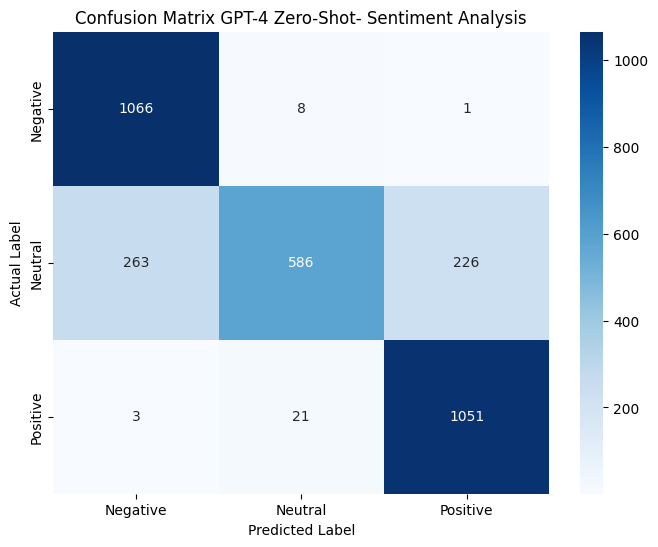


EVALUATION REPORT: GPT-4 CoT
Accuracy:  0.8427
Macro Precision: 0.8531
Macro Recall:    0.8425
Macro F1:  0.8324
----------------------------------------
GPT-4 CoT- Evaluation on Full Test Set Report
              precision    recall  f1-score   support

    negative     0.8032    0.9833    0.8841      1075
     neutral     0.9080    0.5890    0.7145      1073
    positive     0.8481    0.9553    0.8985      1075

    accuracy                         0.8427      3223
   macro avg     0.8531    0.8425    0.8324      3223
weighted avg     0.8531    0.8427    0.8325      3223



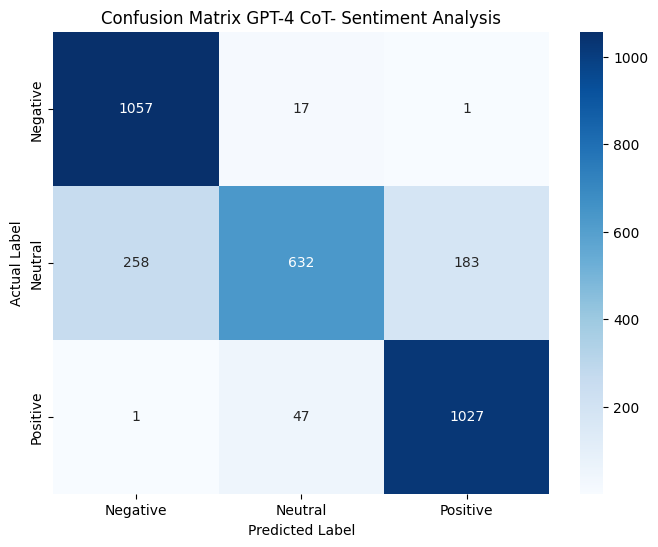


EVALUATION REPORT: Mistral Zero-Shot
Accuracy:  0.8242
Macro Precision: 0.8519
Macro Recall:    0.8242
Macro F1:  0.8061
----------------------------------------
Mistral Zero-Shot- Evaluation on Full Test Set Report
              precision    recall  f1-score   support

    negative     0.7854    0.9907    0.8762      1075
     neutral     0.9657    0.4977    0.6568      1075
    positive     0.8046    0.9842    0.8854      1075

    accuracy                         0.8242      3225
   macro avg     0.8519    0.8242    0.8061      3225
weighted avg     0.8519    0.8242    0.8061      3225



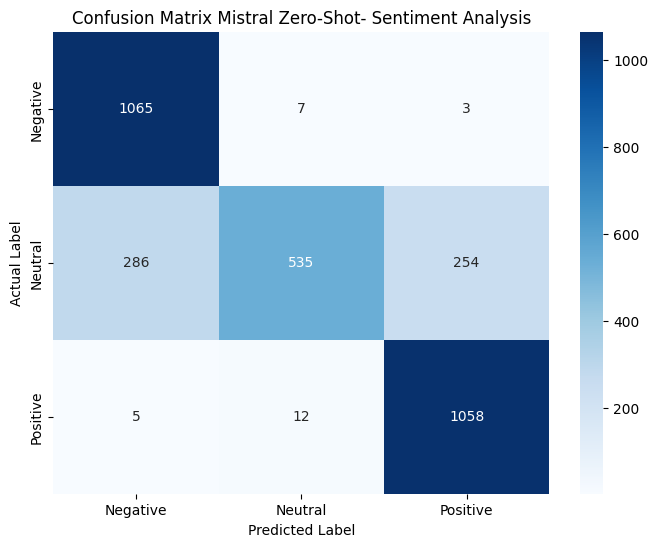


EVALUATION REPORT: Mistral CoT
Accuracy:  0.8177
Macro Precision: 0.8279
Macro Recall:    0.8177
Macro F1:  0.8033
----------------------------------------
Mistral CoT- Evaluation on Full Test Set Report
              precision    recall  f1-score   support

    negative     0.7910    0.9823    0.8763      1075
     neutral     0.8777    0.5274    0.6589      1075
    positive     0.8151    0.9433    0.8745      1075

    accuracy                         0.8177      3225
   macro avg     0.8279    0.8177    0.8033      3225
weighted avg     0.8279    0.8177    0.8033      3225



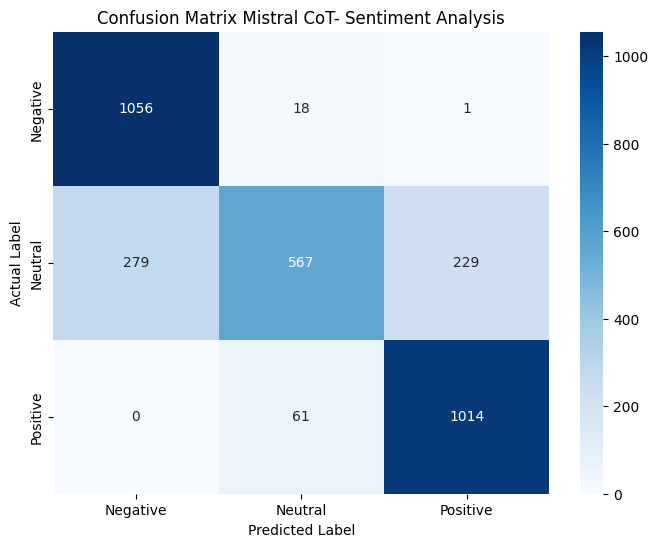

In [4]:

# Setup & Mapping
llm_df = pd.read_csv("Balanced_All_Experiment_Results_full_samples_0702.csv")
id2label = { 0: "negative", 1: "neutral", 2: "positive"}
labels = ['Negative', 'Neutral', 'Positive']
LABEL_MAP = {
    0: "negative",
    1: "neutral",
    2: "positive"
}
# Reverse map: "positive" -> 2
TEXT_TO_INT = {v: k for k, v in LABEL_MAP.items()}
 
# Parsing Functions
def clean_label(text):
    if not isinstance(text, str): return None
    text = text.lower().strip()
    if "positive" in text: return "positive"
    if "satisfied" in text: return "positive"
    if "negative" in text: return "negative"
    if "disappointed" in text: return "negative"
    if "neutral" in text:  return "neutral"
    if "mixed" in text:  return "neutral"
    if "average" in text: return "neutral"
    if "ambiguous" in text: return "neutral"
    return None

def sentiment_parse_zs_output(text):
    if not isinstance(text, str): return -1
    match = re.search(r"ZS_Sentiment:\s*([a-zA-Z]+)", text, re.IGNORECASE)
    if match:
        return TEXT_TO_INT.get(clean_label(match.group(1)), -1)
    return TEXT_TO_INT.get(clean_label(text), -1)

def sentiment_parse_cot_output(text):
    if not isinstance(text, str): return -1
    text = re.sub(r"```json", "", text)
    text = re.sub(r"```", "", text).strip()
    try:
        data = json.loads(text)
        return TEXT_TO_INT.get(clean_label(data.get("overall_sentiment", "")), -1)
    except:
        match = re.search(r'"overall_sentiment":\s*"([a-zA-Z]+)"', text, re.IGNORECASE)
        if match:
            return TEXT_TO_INT.get(clean_label(match.group(1)), -1)
        return TEXT_TO_INT.get(clean_label(text), -1)


def reason_parse_zs_output(text):
    if not isinstance(text, str): return -1
    match = re.search(r"Reason:\s*(.*)", text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip()

def reason_parse_cot_output(text):
    if not isinstance(text, str): return -1
    text = re.sub(r"```json", "", text)
    text = re.sub(r"```", "", text).strip()
    try:
        data = json.loads(text)
        return data.get("reason", "")
    except:
        match = re.search(r'"reason":\s*"(.*?)"', text, re.IGNORECASE | re.DOTALL)
        if match:
            return match.group(1).strip()
        return ""
        
def aspect_parse_cot_output(text):
    """
    Parses LLM output to extract aspects and sentiments.
    Returns string format: "aspect1":"sentiment1", "aspect2":"sentiment2"
    """
    if not isinstance(text, str): return "None"
    
    # Clean code blocks
    text_clean = re.sub(r"```json", "", text)
    text_clean = re.sub(r"```", "", text_clean).strip()
    
    found_aspects = []
    
    # Try Valid JSON parsing first
    try:
        data = json.loads(text_clean)
        if "aspects" in data and isinstance(data["aspects"], list):
            for item in data["aspects"]:
                asp = item.get("aspect", "").strip()
                sent = item.get("sentiment", "").strip()
                if asp and sent:
                    found_aspects.append(f'"{asp}":"{sent}"')
            if found_aspects:
                return ", ".join(found_aspects)
    except json.JSONDecodeError:
        pass # Fallback to Regex

    # Fallback: Regex Parsing if JSON fails
    # It handles newlines and slight spacing variations
    pattern = r'\{\s*"aspect"\s*:\s*"(.*?)"\s*,\s*"sentiment"\s*:\s*"(.*?)"\s*\}'
    matches = re.findall(pattern, text, re.IGNORECASE | re.DOTALL)
    
    for asp, sent in matches:
        found_aspects.append(f'"{asp.strip()}":"{sent.strip()}"')
        
    if found_aspects:
        return ", ".join(found_aspects)
        
    return "None"
    
# Apply Parsing & TYPE FIX 
print("Parsing LLM outputs...")

# Apply parsers
llm_df['GPT4_ZS_Sentiment'] = llm_df['GPT4_ZS_Output'].apply(sentiment_parse_zs_output)
llm_df['GPT4_ZS_Reason'] = llm_df['GPT4_ZS_Output'].apply(reason_parse_zs_output)
llm_df['GPT4_COT_Sentiment'] = llm_df['GPT4_COT_Output'].apply(sentiment_parse_cot_output)
llm_df['GPT4_COT_Reason'] = llm_df['GPT4_COT_Output'].apply(reason_parse_cot_output)

llm_df['Mistral_ZS_Sentiment'] = llm_df['Mistral_ZS_Output'].apply(sentiment_parse_zs_output)
llm_df['Mistral_ZS_Reason'] = llm_df['Mistral_ZS_Output'].apply(reason_parse_zs_output)
llm_df['Mistral_COT_Sentiment'] = llm_df['Mistral_COT_Output'].apply(sentiment_parse_cot_output)
llm_df['Mistral_COT_Reason'] = llm_df['Mistral_COT_Output'].apply(reason_parse_cot_output)

llm_df['GPT4_COT_Aspects'] = llm_df['GPT4_COT_Output'].apply(aspect_parse_cot_output)
llm_df['Mistral_COT_Aspects'] = llm_df['Mistral_COT_Output'].apply(aspect_parse_cot_output)

# Fail rows
#failed_rows_gpt = llm_df[(llm_df["GPT4_COT_Sentiment"] == -1) | (llm_df["GPT4_ZS_Sentiment"] == -1)]
#print(failed_rows_gpt[['GPT4_ZS_Sentiment','GPT4_COT_Sentiment','GPT4_COT_Output']])
#failed_rows_mistral = llm_df[(llm_df["Mistral_COT_Sentiment"] == -1) | (llm_df["Mistral_ZS_Sentiment"] == -1)]
#print(failed_rows_mistral[['Mistral_ZS_Sentiment','Mistral_COT_Sentiment','Mistral_COT_Output']])
# --- TYPE ENFORCEMENT FIX ---
first_val = llm_df['Encoded_Label'].iloc[0]


# Fill NaNs (parsing errors) with -1 so I can convert to int safely
llm_df['Encoded_Label'] = llm_df['Encoded_Label'].fillna(-1).astype(int)
llm_df['GPT4_ZS_Sentiment'] = llm_df['GPT4_ZS_Sentiment'].fillna(-1).astype(int)
llm_df['GPT4_COT_Sentiment'] = llm_df['GPT4_COT_Sentiment'].fillna(-1).astype(int)
llm_df['Mistral_ZS_Sentiment'] = llm_df['Mistral_ZS_Sentiment'].fillna(-1).astype(int)
llm_df['Mistral_COT_Sentiment'] = llm_df['Mistral_COT_Sentiment'].fillna(-1).astype(int)


# Generate Classification Reports
target_names = [LABEL_MAP[0], LABEL_MAP[1], LABEL_MAP[2]] # ['negative', 'neutral', 'positive']
models_to_eval = [
    ('GPT-4 Zero-Shot', 'GPT4_ZS_Sentiment'),
    ('GPT-4 CoT', 'GPT4_COT_Sentiment'),
    ('Mistral Zero-Shot', 'Mistral_ZS_Sentiment'),
    ('Mistral CoT', 'Mistral_COT_Sentiment')
]

for model_name, col_name in models_to_eval:
    print(f"\n{'='*40}")
    print(f"EVALUATION REPORT: {model_name}")
    print(f"{'='*40}")
    
    y_true = llm_df['Encoded_Label']
    y_pred = llm_df[col_name]
    
     # Check if predictions contain -1 (Parsing error)
    # Here, I treat -1 as "Wrong" and removed   
    valid_mask = y_pred != -1
    y_true_clean = y_true[valid_mask]
    y_pred_clean = y_pred[valid_mask]
    
    
    acc = accuracy_score(y_true_clean, y_pred_clean)
    prec = precision_score(y_true_clean, y_pred_clean, labels=[0, 1, 2], average='macro', zero_division=0)
    rec = recall_score(y_true_clean, y_pred_clean, labels=[0, 1, 2], average='macro', zero_division=0)
    f1 = f1_score(y_true_clean, y_pred_clean, labels=[0, 1, 2], average='macro', zero_division=0)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Macro Precision: {prec:.4f}")
    print(f"Macro Recall:    {rec:.4f}")
    print(f"Macro F1:  {f1:.4f}")
    print("-" * 40)
 

    print(f"{model_name}- Evaluation on Full Test Set Report")
    print(classification_report(y_true_clean, y_pred_clean, labels=[0, 1, 2], target_names=target_names, zero_division=0, digits=4))

    #Plot confusion matrix
    cm = confusion_matrix(y_true_clean, y_pred_clean)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

    plt.title(f"Confusion Matrix {model_name}- Sentiment Analysis")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()


llm_df['GPT4_ZS_Sentiment'] = llm_df['GPT4_ZS_Sentiment'].map(id2label)
llm_df['GPT4_COT_Sentiment'] = llm_df['GPT4_COT_Sentiment'].map(id2label)
llm_df['Mistral_ZS_Sentiment'] = llm_df['Mistral_ZS_Sentiment'].map(id2label)
llm_df['Mistral_COT_Sentiment'] = llm_df['Mistral_COT_Sentiment'].map(id2label)

#print(llm_df.head(10))
#llm_output_df = llm_df[['original_index','Review','True_Label',
#                        'GPT4_ZS_Sentiment','GPT4_ZS_Reason','GPT4_COT_Sentiment', 'GPT4_COT_Reason', 'GPT4_COT_Aspects',
#                        'Mistral_ZS_Sentiment','Mistral_ZS_Reason','Mistral_COT_Sentiment', 'Mistral_COT_Reason', 'Mistral_COT_Aspects']]
#print(llm_output_df)
llm_df.to_csv("Final_Balanced_All_Experiment_Results_full_0702.csv", index=False)

In [7]:
llm_df['Mistral_COT_Sentiment'].value_counts()

Mistral_COT_Sentiment
negative    1335
positive    1244
neutral      646
Name: count, dtype: int64

final_llm_df=pd.read_csv("Final_Balanced_All_Experiment_Results_full_2702.csv")
final_llm_df

In [8]:
#!pip install -q -U google-generativeai pandas tqdm

In [9]:
llm_judged_result = pd.read_csv("Final_Balanced_All_Experiment_Results_full_0702.csv")
llm_judged_result.isnull().sum()

original_index             0
True_Label                 0
Encoded_Label              0
Review                     0
GPT4_ZS_Output             0
GPT4_COT_Output            0
Mistral_ZS_Output          0
Mistral_COT_Output         0
svm_sentiment              0
svm_shap_top_features      0
bert_sentiment             0
bert_shap_top_tokens       0
GPT4_ZS_Sentiment          0
GPT4_ZS_Reason             0
GPT4_COT_Sentiment         2
GPT4_COT_Reason            2
Mistral_ZS_Sentiment       0
Mistral_ZS_Reason          0
Mistral_COT_Sentiment      0
Mistral_COT_Reason         0
GPT4_COT_Aspects         443
Mistral_COT_Aspects        0
dtype: int64

In [10]:
llm_judged_result[llm_judged_result['GPT4_COT_Reason'].isnull()][['Review','Mistral_COT_Output','GPT4_COT_Output']]

,Review,Mistral_COT_Output,GPT4_COT_Output
2536,good choice kannan superann ini use cheithid p...,"{\n""aspects"": [\n{""aspect"": ""Kannan Superann""...",The provided review is not in English and does...
3136,do the job name,"{\n""aspects"": [\n{""aspect"": ""Job"", ""sentiment...","The provided review ""do the job name"" is not s..."


In [11]:
pd.set_option('display.max_colwidth', None)
llm_judged_result[llm_judged_result['GPT4_COT_Aspects'].isnull()][['Review','GPT4_COT_Output','Mistral_COT_Output']]

,Review,GPT4_COT_Output,Mistral_COT_Output
27,pretty good normal,"{\n""aspects"": [\n],\n""overall_sentiment"": ""neutral"",\n""reason"": ""The review does not mention any specific aspects or features of the product. The sentiment expressed is neutral as the reviewer states the product is 'pretty good normal', which does not indicate a particularly positive or negative experience.""\n}","{\n""aspects"": [\n{""aspect"": ""Product"", ""sentiment"": ""Neutral""},\n{""aspect"": ""Quality"", ""sentiment"": ""Positive (implied by 'pretty good')""}\n],\n""overall_sentiment"": ""Neutral-Positive"",\n""reason"": ""The user finds the product to be of good quality, but does not express extreme sentiments about any specific aspect.""\n}"
34,fair not bad,"{\n""aspects"": [\n],\n""overall_sentiment"": ""neutral"",\n""reason"": ""The review does not mention any specific aspects or features of the product. The sentiment expressed is neutral, as the reviewer states the product is 'fair not bad', which indicates neither strong satisfaction nor dissatisfaction.""\n}","{\n""aspects"": [\n{""aspect"": ""product"", ""sentiment"": ""neutral""},\n{""aspect"": ""quality"", ""sentiment"": ""neutral""}\n],\n""overall_sentiment"": ""neutral"",\n""reason"": ""The reviewer uses the phrase 'fair not bad', which indicates a neutral sentiment towards the product's quality.""\n}"
55,wonderful all right,"{\n""aspects"": [\n],\n""overall_sentiment"": ""positive"",\n""reason"": ""The review does not mention any specific aspects or features of the product. However, the words used ('wonderful', 'all right') express a positive sentiment.""\n}","{\n""aspects"": [\n{""aspect"": ""product"", ""sentiment"": ""neutral""},\n{""aspect"": ""quality"", ""sentiment"": ""positive""}\n],\n""overall_sentiment"": ""mixed"",\n""reason"": ""The user used the word 'wonderful' to express a positive sentiment towards the product's quality, but also used 'all right' which suggests a neutral or average sentiment overall.""\n}"
67,well in the market superb nd excellent,"{\n""aspects"": [\n],\n""overall_sentiment"": ""positive"",\n""reason"": ""The review does not mention specific aspects of the product. However, the words 'superb' and 'excellent' indicate a positive sentiment towards the product overall.""\n}","{\n""aspects"": [\n{""aspect"": ""product"", ""sentiment"": ""positive""},\n{""aspect"": ""market"", ""sentiment"": ""neutral""}\n],\n""overall_sentiment"": ""positive"",\n""reason"": ""The reviewer used positive adjectives like 'superb' and 'excellent' to describe the product, indicating a positive sentiment towards it.""\n}"
82,nice nothing,"{\n""aspects"": [\n],\n""overall_sentiment"": ""neutral"",\n""reason"": ""The review is vague and does not mention any specific aspects or features of the product. The sentiment expressed is neutral.""\n}","{\n""aspects"": [\n{""aspect"": ""product"", ""sentiment"": ""neutral""},\n{""aspect"": ""quality"", ""sentiment"": ""positive""}\n],\n""overall_sentiment"": ""neutral"",\n""reason"": ""The user mentions the product as 'nice', indicating a positive sentiment towards its quality, but the lack of specific features or aspects mentioned suggests a neutral overall sentiment.""\n}"
...,...,...,...
3167,wonderful good,"{\n""aspects"": [\n],\n""overall_sentiment"": ""positive"",\n""reason"": ""The review does not mention any specific aspects or features of the product. However, the words used ('wonderful', 'good') express a positive sentiment.""\n}","{\n""aspects"": [\n{""aspect"": ""product"", ""sentiment"": ""positive""},\n{""aspect"": ""quality"", ""sentiment"": ""positive""}\n],\n""overall_sentiment"": ""positive"",\n""reason"": ""The reviewer used positive adjectives ('wonderful', 'good') to describe the product, indicating a positive sentiment towards its quality.""\n}"
3182,very good good,"{\n""aspects"": [\n],\n""overall_sentiment"": ""positive"",\n""reason"": ""The review does not mention any specific aspects or features of the product. 

In [12]:
# Check file 

INPUT_FILE = "Final_Balanced_All_Experiment_Results_full_0702.csv"
OUTPUT_FILE = "Final_LLM_Judge_Results_full_0702.csv"
print(f"Loading Data...")

# Load the original input
if not os.path.exists(INPUT_FILE):
    print(f"Error: File '{INPUT_FILE}' not found.")
    exit()

judge_df = pd.read_csv(INPUT_FILE)

# Check for existing progress 
if os.path.exists(OUTPUT_FILE):
    print(f"Found existing output file: {OUTPUT_FILE}. Resuming...")
    existing_df = pd.read_csv(OUTPUT_FILE)
    
    # Ensure columns match to align data
    judge_df = existing_df
    
    # Check how many are done
    if 'Judge_Error' in judge_df.columns:
        done_count = judge_df['Judge_Error'].isna().sum()
        print(f"Already completed {done_count} rows.")
else:
    print("Starting fresh...")
    # Initialize columns
    cols = ['Rank_SVM', 'Rank_BERT', 'Rank_GPT4_ZS', 'Rank_GPT4_COT', 'Rank_Mistral_ZS', 'Rank_Mistral_COT']
    for col in cols:
        judge_df[col] = None
    judge_df['Judge_Error'] = None

print(f"Total rows to process: {len(judge_df)}\n")

Loading Data...
Found existing output file: Final_LLM_Judge_Results_full_0702.csv. Resuming...
Already completed 2845 rows.
Total rows to process: 3225



In [13]:
import pandas as pd
import google.generativeai as genai
from google.api_core import exceptions
import json
import time
import os
import re
import sys


# Configuration
API_KEY = open("./GOOGLE_API_KEY.txt", "r").read().strip()
MODEL_NAME = "gemini-2.5-pro"   
INPUT_FILE = "Final_Balanced_All_Experiment_Results_full_0702.csv"
OUTPUT_FILE = "Final_LLM_Judge_Results_full_0702.csv"


# Setup
print("STEP 1: Configuring API...")
genai.configure(api_key=API_KEY)

model = genai.GenerativeModel(
    model_name=MODEL_NAME,
    generation_config={
        "temperature": 0.0,
        "top_p": 1.0,
        "response_mime_type": "application/json"
    }
)

# Prompt
PROMPT_TEMPLATE = """
You are a Senior Product Manager at a major e-commerce company. Your goal is to identify specific product defects from customer feedback so the engineering team can fix them.

Task:
I will provide you with a customer review and 6 different explanations generated by various AI systems. Your job is to Rank the explanations from 1 (best) to 6 (worst) based on their utility to your engineering team.

Ranking criteria:
1. Actionability (most important): Does the explanation clearly isolate the root cause?
2. Causal clarity: Does it explain why the sentiment is negative/positive/neutral?
3. Faithfulness: Penalize hallucinations. If an explanation cites a feature not mentioned in the review, rank it last (6).
4. Conciseness: If two explanations are equally accurate, prefer the one that is more direct.

Constraint:
- You MUST assign a unique rank (1, 2, 3, 4, 5, 6) to each explanation.
- NO TIES are allowed. You must make a decision.

Input Data:
Review: "{review}"
True Sentiment: "{sentiment}"

[Explanation A] (SVM-SHAP): {exp_a}
[Explanation B] (BERT-SHAP): {exp_b}
[Explanation C] (GPT-4-ZS): {exp_c}
[Explanation D] (GPT-4-CoT): {exp_d}
[Explanation E] (Mistral-ZS): {exp_e}
[Explanation F] (Mistral-CoT): {exp_f}

Output Format (JSON Only):
{{
  "rankings": {{
    "A": <integer 1-6>,
    "B": <integer 1-6>,
    "C": <integer 1-6>,
    "D": <integer 1-6>,
    "E": <integer 1-6>,
    "F": <integer 1-6>
  }}
}}
"""

# Functions
def extract_json(text):
    try:
        return json.loads(text)
    except:
        match = re.search(r'(\{.*\})', text, re.DOTALL)
        if match:
            return json.loads(match.group(1))
    return None

def try_generate_content(model, prompt, max_retries=3):
    """
    Returns:
        response object: If successful
        "QUOTA_STOP": If we hit the hard daily limit
        None: If generic failure
    """
    wait_time = 1 
    for attempt in range(max_retries):
        try:
            return model.generate_content(prompt)
        
        except exceptions.ResourceExhausted as e:
            error_msg = str(e).lower()
            # Check for hard stop (Daily Quota)
            if "quota" in error_msg or "billing" in error_msg:
                print(f"\n[CRITICAL] Daily Quota Reached: {e}")
                return "QUOTA_STOP"
            
            # Check for soft stop (Rate Limit / RPM)
            print(f"\n[Rate Limit] Too fast. Waiting {wait_time}s before retry {attempt+1}/{max_retries}...")
            time.sleep(wait_time)
            wait_time *= 2 
            
        except Exception as e:
            print(f"\n[API Error] {e}")
            return None
            
    print("\n[Failed] Max retries reached for this row.")
    return None

def process_row(index, row):
    print(f"  > Processing Row {index}...", end=" ", flush=True)
    
    prompt = PROMPT_TEMPLATE.format(
        review=str(row.get('Feedback_Clean', ''))[:1000], 
        sentiment=row.get('True_Label', ''),
        exp_a=str(row.get('svm_shap_top_features', 'N/A')),
        exp_b=str(row.get('bert_shap_top_tokens', 'N/A')),
        exp_c=str(row.get('GPT4_ZS_Reason', 'N/A')),
        exp_d=str(row.get('GPT4_COT_Reason', 'N/A')),
        exp_e=str(row.get('Mistral_ZS_Reason', 'N/A')),
        exp_f=str(row.get('Mistral_COT_Reason', 'N/A'))
    )

    response = try_generate_content(model, prompt)
    
    # Check for the Hard stop signal
    if response == "QUOTA_STOP":
        return "QUOTA_STOP", "Quota Exceeded"

    if not response:
        return None, "API Error or Timeout"

    data = extract_json(response.text)
    
    if data and "rankings" in data:
        print("Success!")
        return data["rankings"], None
    else:
        print("Failed (Invalid JSON).")
        return None, "Invalid JSON"


# Main Execution

# Load Input
if not os.path.exists(INPUT_FILE):
    print(f"Error: File '{INPUT_FILE}' not found.")
    exit()

judge_df = pd.read_csv(INPUT_FILE)

# Check for resume
if os.path.exists(OUTPUT_FILE):
    print(f"Found existing output file: {OUTPUT_FILE}. Resuming...")
    existing_df = pd.read_csv(OUTPUT_FILE)
    # Align columns
    judge_df = existing_df
    if 'Rank_SVM' in judge_df.columns:
        done_count = judge_df['Rank_SVM'].notna().sum()
        print(f"Skipping {done_count} already completed rows.")
else:
    print("Starting fresh...")
    cols = ['Rank_SVM', 'Rank_BERT', 'Rank_GPT4_ZS', 'Rank_GPT4_COT', 'Rank_Mistral_ZS', 'Rank_Mistral_COT']
    for col in cols:
        judge_df[col] = None
    judge_df['Judge_Error'] = None

print(f"Total rows: {len(judge_df)}\n")

# Loop
for index, row in judge_df.iterrows():
    
    # Skip if done
    if pd.notna(row['Rank_SVM']):
        continue

    # Process
    rankings, error = process_row(index, row)
    
    # Hard stop check
    if rankings == "QUOTA_STOP":
        print("\n" + "="*50)
        print("STOPPING SCRIPT: Daily Quota Exceeded.")
        print(f"Saving progress up to row {index}...")
        judge_df.to_csv(OUTPUT_FILE, index=False)
        print(f"Progress saved to {OUTPUT_FILE}. YPls run this script again tomorrow to resume.")
        print("="*50)
        sys.exit() #  stops the Python script

    # Save results
    if rankings:
        judge_df.at[index, 'Rank_SVM'] = rankings.get("A")
        judge_df.at[index, 'Rank_BERT'] = rankings.get("B")
        judge_df.at[index, 'Rank_GPT4_ZS'] = rankings.get("C")
        judge_df.at[index, 'Rank_GPT4_COT'] = rankings.get("D")
        judge_df.at[index, 'Rank_Mistral_ZS'] = rankings.get("E")
        judge_df.at[index, 'Rank_Mistral_COT'] = rankings.get("F")
        judge_df.at[index, 'Judge_Error'] = None 
    else:
        judge_df.at[index, 'Judge_Error'] = error

    # Periodic save
    if index % 10 == 0:
        judge_df.to_csv(OUTPUT_FILE, index=False)
        
    # Rate limit sleep
    time.sleep(1) 

# Final save
judge_df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSTEP 4: COMPLETED. All rows processed. Results saved to {OUTPUT_FILE}")

/tmp/ipykernel_341565/373483740.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


STEP 1: Configuring API...
Found existing output file: Final_LLM_Judge_Results_full_0702.csv. Resuming...
Skipping 2845 already completed rows.
Total rows: 3225

  > Processing Row 2844... Success!
  > Processing Row 2845... Success!
  > Processing Row 2846... Success!
  > Processing Row 2847... Success!
  > Processing Row 2848... Success!
  > Processing Row 2849... Success!
  > Processing Row 2850... Success!
  > Processing Row 2851... Success!
  > Processing Row 2852... Success!
  > Processing Row 2853... Success!
  > Processing Row 2854... Success!
  > Processing Row 2855... Success!
  > Processing Row 2856... Success!
  > Processing Row 2857... Success!
  > Processing Row 2858... Success!
  > Processing Row 2859... Success!
  > Processing Row 2860... Success!
  > Processing Row 2861... Success!
  > Processing Row 2862... Success!
  > Processing Row 2863... Success!
  > Processing Row 2864... Success!
  > Processing Row 2865... Success!
  > Processing Row 2866... Success!
  > Proces

In [7]:
judge_df=pd.read_csv("Final_LLM_Judge_Results_full_0702.csv")
judge_df[['Rank_SVM', 'Rank_BERT', 'Rank_GPT4_ZS', 'Rank_GPT4_COT', 'Rank_Mistral_ZS', 'Rank_Mistral_COT']].mean().sort_values()

Rank_GPT4_COT       2.566202
Rank_GPT4_ZS        2.808372
Rank_Mistral_COT    3.223256
Rank_Mistral_ZS     3.567442
Rank_BERT           4.339845
Rank_SVM            4.494884
dtype: float64

In [8]:
judge_df.isnull().sum()

original_index              0
True_Label                  0
Encoded_Label               0
Review                      0
GPT4_ZS_Output              0
GPT4_COT_Output             0
Mistral_ZS_Output           0
Mistral_COT_Output          0
svm_sentiment               0
svm_shap_top_features       0
bert_sentiment              0
bert_shap_top_tokens        0
GPT4_ZS_Sentiment           0
GPT4_ZS_Reason              0
GPT4_COT_Sentiment          2
GPT4_COT_Reason             2
Mistral_ZS_Sentiment        0
Mistral_ZS_Reason           0
Mistral_COT_Sentiment       0
Mistral_COT_Reason          0
GPT4_COT_Aspects          443
Mistral_COT_Aspects         0
Rank_SVM                    0
Rank_BERT                   0
Rank_GPT4_ZS                0
Rank_GPT4_COT               0
Rank_Mistral_ZS             0
Rank_Mistral_COT            0
Judge_Error              3225
dtype: int64

In [11]:
judge_df[['True_Label', 'Review', 'Rank_SVM','Rank_BERT','Rank_GPT4_ZS','Rank_GPT4_COT','Rank_Mistral_ZS','Rank_Mistral_COT']]

,True_Label,Review,Rank_SVM,Rank_BERT,Rank_GPT4_ZS,Rank_GPT4_COT,Rank_Mistral_ZS,Rank_Mistral_COT
0,positive,perfect product very nice memory card,6.0,5.0,2.0,4.0,1.0,3.0
1,neutral,good 5 star for the product delivery be on tim...,6.0,5.0,4.0,3.0,2.0,1.0
2,neutral,good too hot while grind,5.0,6.0,3.0,2.0,4.0,1.0
3,negative,unsatisfactory very bad productnot 30vats,2.0,4.0,3.0,6.0,5.0,1.0
4,neutral,fair not very sturdy and durable not for kid a...,1.0,2.0,3.0,5.0,6.0,4.0
...,...,...,...,...,...,...,...,...
3220,neutral,wonderful not bad not so good,6.0,5.0,2.0,1.0,3.0,4.0
3221,negative,do not meet expectation bad,6.0,5.0,1.0,3.0,2.0,4.0
3222,negative,worthless no use its not work I request all of...,2.0,1.0,4.0,6.0,5.0,3.0
3223,negative,bad quality quality not acceptable,6.0,5.0,1.0,2.0,3.0,4.0


In [17]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset
df_similarity = pd.read_csv('Final_LLM_Judge_Results_full_0702.csv')

# ML, Transformer and LLM 'reason'
text_cols = [
    'GPT4_COT_Reason', 
    'svm_shap_top_features', 
    'bert_shap_top_tokens',
    'GPT4_ZS_Reason', 
    'Mistral_ZS_Reason', 
    'Mistral_COT_Reason'
]

# Fill missing values and remove commas from feature lists to treat them as bag-of-words
df_similarity[text_cols] = df_similarity[text_cols].fillna('')

def clean_text(text):
    return str(text).replace(',', ' ')

for col in text_cols:
    df_similarity[col] = df_similarity[col].apply(clean_text)

# Vectorize the text using TF-IDF
# Fit on ALL relevant columns to ensure a shared vocabulary space
all_text = pd.concat([df_similarity[col] for col in text_cols])
tfidf = TfidfVectorizer()
tfidf.fit(all_text)

# Transform each column into vectors
vectors = {col: tfidf.transform(df_similarity[col]) for col in text_cols}

# Define function to calculate row-wise Cosine Similarity
def get_cosine_similarity(vec_a, vec_b):
    # Since TfidfVectorizer output is L2 normalized, the dot product is the cosine similarity
    # I perform element-wise multiplication and sum along the row axis
    return np.array(vec_a.multiply(vec_b).sum(axis=1)).flatten()

# Calculate Similarity for the 5 pairs
pairs = [
    ('GPT4_COT_Reason', 'svm_shap_top_features', 'Sim_GPT4_COT_SVM'),
    ('GPT4_COT_Reason', 'bert_shap_top_tokens', 'Sim_GPT4_COT_BERT'),
    ('GPT4_COT_Reason', 'GPT4_ZS_Reason',       'Sim_GPT4_COT_GPT4_ZS'),
    ('GPT4_COT_Reason', 'Mistral_ZS_Reason',    'Sim_GPT4_COT_Mistral_ZS'),
    ('GPT4_COT_Reason', 'Mistral_COT_Reason',   'Sim_GPT4_COT_Mistral_COT')
]

results = {}
for col1, col2, out_col in pairs:
    sim_scores = get_cosine_similarity(vectors[col1], vectors[col2])
    df_similarity[out_col] = sim_scores
    results[out_col] = sim_scores.mean()

# Output the Ranking
print("Ranking based on Mean Average Cosine Similarity:")
sorted_ranking = sorted(results.items(), key=lambda x: x[1], reverse=True)
for rank, (pair, score) in enumerate(sorted_ranking, 1):
    print(f"{rank}. {pair}: {score:.4f}")

# Save the results
df_similarity.to_csv('Final_Balanced_All_Experiment_Results_with_Similarity.csv', index=False)

Ranking based on Mean Average Cosine Similarity:
1. Sim_GPT4_COT_Mistral_COT: 0.4211
2. Sim_GPT4_COT_GPT4_ZS: 0.3925
3. Sim_GPT4_COT_Mistral_ZS: 0.3686
4. Sim_GPT4_COT_SVM: 0.2921
5. Sim_GPT4_COT_BERT: 0.2560


In [18]:
df_similarity[['True_Label', 'Review', 'Sim_GPT4_COT_SVM','Sim_GPT4_COT_BERT','Sim_GPT4_COT_GPT4_ZS','Sim_GPT4_COT_Mistral_ZS','Sim_GPT4_COT_Mistral_COT']]

,True_Label,Review,Sim_GPT4_COT_SVM,Sim_GPT4_COT_BERT,Sim_GPT4_COT_GPT4_ZS,Sim_GPT4_COT_Mistral_ZS,Sim_GPT4_COT_Mistral_COT
0,positive,perfect product very nice memory card,0.671827,0.676738,0.379119,0.211176,0.678904
1,neutral,good 5 star for the product delivery be on tim...,0.186639,0.215152,0.428980,0.216472,0.321239
2,neutral,good too hot while grind,0.099245,0.082236,0.050584,0.083947,0.453767
3,negative,unsatisfactory very bad productnot 30vats,0.000000,0.028971,0.070143,0.356923,0.214966
4,neutral,fair not very sturdy and durable not for kid a...,0.172637,0.175885,0.384511,0.436102,0.367564
...,...,...,...,...,...,...,...
3220,neutral,wonderful not bad not so good,0.412679,0.419638,0.389038,0.360113,0.590201
3221,negative,do not meet expectation bad,0.336848,0.307886,0.268547,0.418006,0.115375
3222,negative,worthless no use its not work I request all of...,0.129148,0.169642,0.467346,0.297523,0.243923
3223,negative,bad quality quality not acceptable,0.558903,0.570017,0.533779,0.563642,0.616104


In [19]:
df_similarity

,original_index,True_Label,Encoded_Label,Review,GPT4_ZS_Output,GPT4_COT_Output,Mistral_ZS_Output,Mistral_COT_Output,svm_sentiment,svm_shap_top_features,...,Rank_GPT4_ZS,Rank_GPT4_COT,Rank_Mistral_ZS,Rank_Mistral_COT,Judge_Error,Sim_GPT4_COT_SVM,Sim_GPT4_COT_BERT,Sim_GPT4_COT_GPT4_ZS,Sim_GPT4_COT_Mistral_ZS,Sim_GPT4_COT_Mistral_COT
0,11110,positive,2,perfect product very nice memory card,ZS_Sentiment: Positive. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""product"", ""sentim...",ZS_Sentiment: Positive. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",positive,perfect perfect product very nice product v...,...,2.0,4.0,1.0,3.0,NaN,0.671827,0.676738,0.379119,0.211176,0.678904
1,6752,neutral,1,good 5 star for the product delivery be on tim...,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""product delivery""...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""Product Delivery...",negative,for they good from do not when after ti...,...,4.0,3.0,2.0,1.0,NaN,0.186639,0.215152,0.428980,0.216472,0.321239
2,10378,neutral,1,good too hot while grind,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""grind"", ""sentimen...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""product (grinder...",neutral,good too grind while grind while hot while...,...,3.0,2.0,4.0,1.0,NaN,0.099245,0.082236,0.050584,0.083947,0.453767
3,525,negative,0,unsatisfactory very bad productnot 30vats,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""product"", ""sentim...",ZS_Sentiment: Negative. Reason: The review co...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",negative,unsatisfactory bad very bad unsatisfactory ...,...,3.0,6.0,5.0,1.0,NaN,0.000000,0.028971,0.070143,0.356923,0.214966
4,8542,neutral,1,fair not very sturdy and durable not for kid a...,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""sturdiness"", ""sen...",ZS_Sentiment: Negative. Reason: The review me...,"{\n""aspects"": [\n{""aspect"": ""sturdiness and d...",neutral,fair not for not very for kid above and ...,...,3.0,5.0,6.0,4.0,NaN,0.172637,0.175885,0.384511,0.436102,0.367564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3220,5698,neutral,1,wonderful not bad not so good,ZS_Sentiment: Neutral. Reason: The review cont...,"{\n""aspects"": [\n],\n""overall_sentiment"": ""neu...",ZS_Sentiment: Neutral. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",neutral,not bad wonderful wonderful not bad not so...,...,2.0,1.0,3.0,4.0,NaN,0.412679,0.419638,0.389038,0.360113,0.590201
3221,1761,negative,0,do not meet expectation bad,ZS_Sentiment: Negative. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""expectation"", ""se...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""expectation"", ""s...",negative,bad meet expectation not not meet do not ...,...,1.0,3.0,2.0,4.0,NaN,0.336848,0.307886,0.268547,0.418006,0.115375
3222,1975,negative,0,worthless no use its not work I request all of...,"""ZS_Sentiment: Negative. Reason: The reviewer ...","{\n""aspects"": [\n{""aspect"": ""product usability...",ZS_Sentiment: Negative. Reason: The customer ...,"{\n""aspects"": [\n{""aspect"": ""product"", ""senti...",negative,worthless not no request do not no use a...,...,4.0,6.0,5.0,3.0,NaN,0.129148,0.169642,0.467346,0.297523,0.243923
3223,1680,negative,0,bad quality quality not acceptable,ZS_Sentiment: Negative. Reason: The reviewer u...,"{\n""aspects"": [\n{""aspect"": ""quality"", ""sentim...",ZS_Sentiment: Negative. Reason: The review co...,"{\n""aspects"": [\n{""aspect"": ""quality"", ""senti...",negative,bad not acceptable not acceptable quality ...,...,1.0,2.0,3.0,4.0,NaN,0.558903,0.570017,0.533779,0.563642,0.616104


###
###  END PYTHON CODE FOR THE THESIS
###

###
###  THESE BELOW CODE JUST FOR RESUME & LOAD SAVE POINTS
### 

In [2]:
# Create a folder for your checkpoints to keep things organized
import os
import joblib
import pandas as pd
checkpoint_dir = 'Checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

print(f"Checkpoints will be saved to: {checkpoint_dir}")

# Define the file path
data_file_path = os.path.join(checkpoint_dir, 'processed_data.pkl')

Checkpoints will be saved to: Checkpoints


In [3]:
import dill

# Load session
dill.load_session(os.path.join(checkpoint_dir, 'notebook_session_svm_balanceddata_fulltest_240126.db'))

2026-03-09 20:30:27.812244: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import dill

# Load session
dill.load_session(os.path.join(checkpoint_dir, 'notebook_session_bertBalanceddata_set2_0702.db'))

2026-02-08 10:15:59.752559: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
import dill

# Load session
dill.load_session(os.path.join(checkpoint_dir, 'notebook_session_bert_complete_080116.db'))